In [739]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib
import shap
import joblib
import tensorflow as tf
from lightgbm import LGBMRegressor
from xgboost import plot_importance
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from math import sqrt
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras import layers
from imblearn.over_sampling import SMOTE
from sklearn import svm
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import font_manager, rc
path = "c:/Windows/Fonts/malgun.ttf"
if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~~')

# 봄

In [648]:
#데이터 불러오기
data_봄 = pd.read_excel("C:/Users/PC/Desktop/봄.xlsx")
data_봄

,id,관리기관,단지명,근로자수,근로손실일,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,재해율,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,17090775,한국산업단지공단 울산지역본부,울산미포국가산업단지,14284.0,306.5,True,5,2.999488e+09,157.4180,0.792495,...,0,0,0,0,0,0,0,0,0,0
1,12823536,한국산업단지공단 경남지역본부,창원국가산업단지,4337.0,283.0,True,4,3.708635e+09,187.8264,0.461148,...,0,0,0,0,2,0,0,0,0,0
2,16959388,한국산업단지공단 울산지역본부,울산미포국가산업단지,2997.0,276.0,True,1,2.857835e+09,53.0124,2.369036,...,0,0,0,0,0,0,0,0,0,0
3,13326267,한국산업단지공단 경남지역본부,창원국가산업단지,2039.0,258.0,True,4,8.497518e+09,223.4079,0.846003,...,0,0,0,0,2,0,0,0,0,0
4,3166196,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,350.0,84.0,True,1,4.531108e+08,141.4237,19.428571,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1612,3389035,한국산업단지공단 경기지역본부,반월국가산업단지,21.0,43.0,False,3,1.403320e+07,62.6035,1.587302,...,0,0,0,0,0,0,0,0,0,0
1613,11777547,한국산업단지공단 대구지역본부 달성사무소,달성2차일반산업단지,10.0,177.0,False,3,4.250820e+06,454.0223,3.333333,...,0,0,1,0,0,0,0,0,0,0
1614,2863330,한국산업단지공단 인천지역본부,남동국가산업단지,22.0,50.0,False,7,3.686506e+06,371.4939,0.649351,...,0,0,0,0,0,0,0,0,0,0
1615,2863328,한국산업단지공단 인천지역본부,남동국가산업단지,60.0,125.0,False,7,1.898501e+07,113.8615,0.238095,...,0,0,0,0,0,0,0,0,0,0


In [649]:
data_봄.중대재해유무 = data_봄.중대재해유무.astype("int")
data_봄.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1617 entries, 0 to 1616
Data columns (total 89 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1617 non-null   int64  
 1   관리기관                       1617 non-null   object 
 2   단지명                        1617 non-null   object 
 3   근로자수                       1617 non-null   float64
 4   근로손실일                      1617 non-null   float64
 5   중대재해유무                     1617 non-null   int32  
 6   그리드 내 총 기업 수               1617 non-null   int64  
 7   매출액                        1617 non-null   float64
 8   부채비율                       1617 non-null   float64
 9   재해율                        1615 non-null   float64
 10  중업종_기계기구 금속 비금속광물제품제조업     1617 non-null   int64  
 11  중업종_선박건조및수리업               1617 non-null   int64  
 12  중업종_화학및고무제품제조업             1617 non-null   int64  
 13  중업종_전기기계기구 정밀기구 전자제품제조업    1617 non-null   int64

In [650]:
data_봄.drop(columns = data_봄.iloc[:, 10:71], inplace = True)
data_봄.head()

,id,관리기관,단지명,근로자수,근로손실일,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,재해율,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,17090775,한국산업단지공단 울산지역본부,울산미포국가산업단지,14284.0,306.5,1,5,2.999488e+09,157.4180,0.792495,...,0,0,0,0,0,0,0,0,0,0
1,12823536,한국산업단지공단 경남지역본부,창원국가산업단지,4337.0,283.0,1,4,3.708635e+09,187.8264,0.461148,...,0,0,0,0,2,0,0,0,0,0
2,16959388,한국산업단지공단 울산지역본부,울산미포국가산업단지,2997.0,276.0,1,1,2.857835e+09,53.0124,2.369036,...,0,0,0,0,0,0,0,0,0,0
3,13326267,한국산업단지공단 경남지역본부,창원국가산업단지,2039.0,258.0,1,4,8.497518e+09,223.4079,0.846003,...,0,0,0,0,2,0,0,0,0,0
4,3166196,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,350.0,84.0,1,1,4.531108e+08,141.4237,19.428571,...,0,0,0,0,0,0,0,0,0,0


In [651]:
data_봄.dropna(inplace = True)

# Output 재해율

In [652]:
X_봄 = data_봄.drop(columns = ["id", "관리기관", "단지명", "근로손실일", "재해율"])
y_봄 = data_봄["재해율"]

In [653]:
scaler = MinMaxScaler()

X_봄 = pd.DataFrame(scaler.fit_transform(X_봄), columns = X_봄.columns)
X_봄.head()

,근로자수,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,중업종분류_기계기구 금속 비금속광물제품제조업,중업종분류_전기기계기구 정밀기구 전자제품제조업,중업종분류_전문 보건 교욱 여가관련서비스,중업종분류_출판 인쇄 제본또는인쇄물가공업,중업종분류_부동산업및임대업,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,1.000000,1.0,0.005222,0.146193,0.168453,0.006623,0.003704,0.017094,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
1,0.303578,1.0,0.003916,0.180756,0.168682,0.003311,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0
2,0.209760,1.0,0.000000,0.139289,0.167667,0.003311,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
3,0.142687,1.0,0.003916,0.414165,0.168950,0.003311,0.000000,0.008547,0.0,0.0,...,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0
4,0.024435,1.0,0.000000,0.022083,0.168333,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0


In [654]:
X_train_봄, X_test_봄, y_train_봄, y_test_봄 = train_test_split(X_봄, y_봄, test_size = 0.25, random_state = 42)

# XGBoost

In [655]:
xgb_봄 = XGBRegressor(early_sropping_rounds = 50, random_state = 42)

param_xgb_봄 = {
    'max_leaves' : [50, 100, 200, 255],
    'n_estimators' : [50,100,150,200,250],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'max_depth' : [3,5,7,10,15],
    'gamma' : [0.1,0,1],
    'colsample_bytree' : [0.7,0.8,0.9]
}

xgb_grid_봄 = GridSearchCV(xgb_봄, param_grid = param_xgb_봄, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
xgb_grid_봄.fit(X_train_봄, y_train_봄)

print("best_score :", -xgb_grid_봄.best_score_)
print("best_params :", xgb_grid_봄.best_params_)

Fitting 5 folds for each of 3600 candidates, totalling 18000 fits
[11:50:51] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "early_sropping_rounds" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


best_score : 2.653772086362668
best_params : {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 3, 'max_leaves': 50, 'n_estimators': 250}


In [656]:
model_xgb_봄 = xgb_grid_봄.best_estimator_
model_xgb_pred_봄 = model_xgb_봄.predict(X_test_봄)

xgb_rmse_봄 = mean_squared_error(model_xgb_pred_봄, y_test_봄, squared = False)

print("rmse :", xgb_rmse_봄)
print("r2_score :", r2_score(y_test_봄, model_xgb_pred_봄))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_봄, model_xgb_pred_봄)) * (len(y_봄)-1)/(len(y_봄)-X_봄.shape[1]-1))

rmse : 1.9164500199130474
r2_score : 0.8615560566771747
adjusted r2_score : 0.8595546671759648


In [657]:
joblib.dump(model_xgb_봄, 'model_xgb_봄.pkl')
#model_xgb_봄 = joblib.load('model_xgb_봄.pkl')

['model_xgb_봄.pkl']

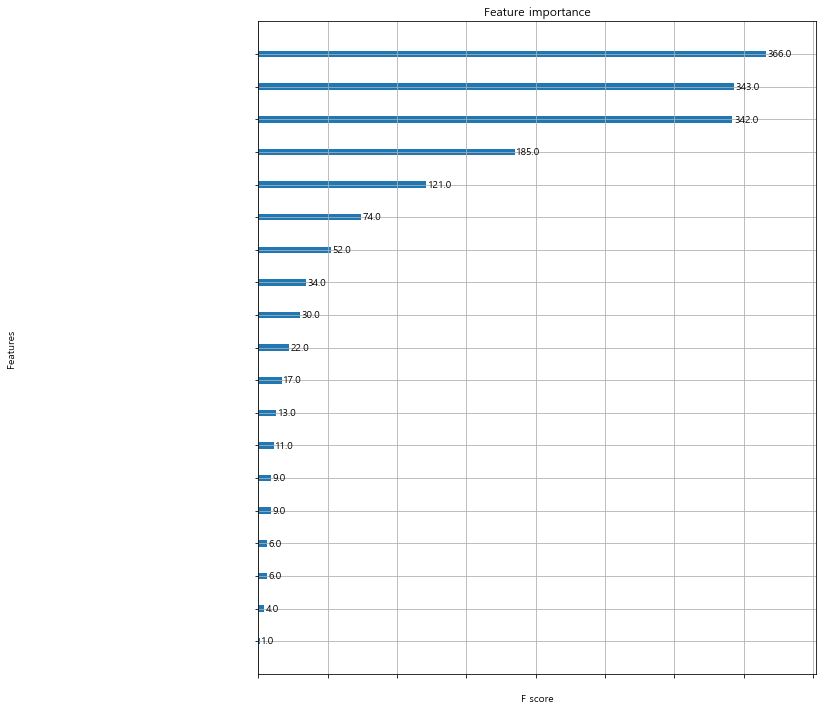

In [658]:
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(model_xgb_봄, ax=ax)
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

In [659]:
shap.initjs()
explainer = shap.Explainer(model_xgb_봄, X_봄, feature_names = X_봄.columns)
shap.values = explainer(X_봄)

Glyph 8722 missing from current font.


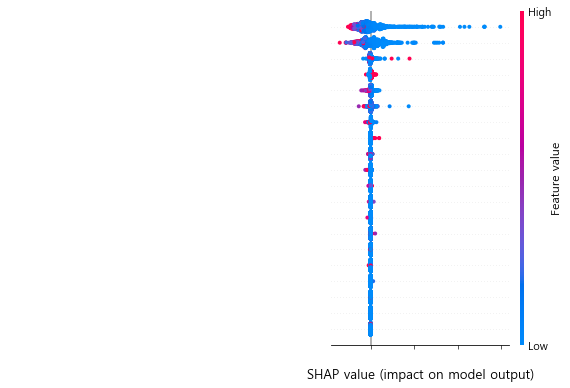

In [660]:
shap.summary_plot(shap_values, X_train_봄, plot_size = 0.2, show = False)
plt.tight_layout()
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

# GBM

In [752]:
gbm_봄 = GradientBoostingRegressor()

param_gbm_봄 = {
    'n_estimators' : [100,200,300,400],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'min_samples_leaf': [4, 8, 12, 18],
    'min_samples_split': [16, 20, 24],
    'max_depth' : [-1,3,7,10],
    'random_state' : [42]
}

gbm_grid_봄 = GridSearchCV(gbm_봄, param_grid = param_gbm_봄, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
gbm_grid_봄.fit(X_train_봄, y_train_봄)

print("best_score :", -gbm_grid_봄.best_score_)
print("best_params :", gbm_grid_봄.best_params_)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits



960 fits failed out of a total of 3840.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
960 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 596, in fit
    monitor,
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 672, in _fit_stages
    X_csr,
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 246, in _fit_stage
    tree.fit(X, residual, sample_weight=sample_weight, check_input=False)
  File "C:\Anaconda3\lib\site-packages\sklearn\tree\_classes.py"

best_score : 2.426066193897806
best_params : {'learning_rate': 0.15, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 20, 'n_estimators': 100, 'random_state': 42}


In [753]:
model_gbm_봄 = gbm_grid_봄.best_estimator_
model_gbm_pred_봄 = model_gbm_봄.predict(X_test_봄)

gbm_rmse_봄 = mean_squared_error(model_gbm_pred_봄, y_test_봄, squared = False)

print("rmse :", gbm_rmse_봄)
print("r2_score :", r2_score(y_test_봄, model_gbm_pred_봄))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_봄, model_gbm_pred_봄)) * (len(y_봄)-1)/(len(y_봄)-X_봄.shape[1]-1))

rmse : 1.7479129189979712
r2_score : 0.8848355201605402
adjusted r2_score : 0.8831706659579585


In [754]:
joblib.dump(model_gbm_봄, 'model_gbm_봄.pkl')
#model_gbm_봄 = joblib.load('model_gbm_봄.pkl')

['model_gbm_봄.pkl']

# LightGBM

In [661]:
lgb_봄 = LGBMRegressor(early_sropping_rounds = 50, random_state = 42)

param_lgb_봄 = {
    'num_leaves': [10, 20, 40, 60],
    'n_estimators' : [100,200,300,400,500],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'max_depth' : [-1,7,10,12.15],
    'gamma' : [0.1,0,1],
    'colsample_bytree' : [0.7,0.8,0.9]
}

lgb_grid_봄 = GridSearchCV(lgb_봄, param_grid = param_lgb_봄, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
lgb_grid_봄.fit(X_train_봄, y_train_봄)

print("best_score :", -lgb_grid_봄.best_score_)
print("best_params :", lgb_grid_봄.best_params_)

Fitting 5 folds for each of 4320 candidates, totalling 21600 fits
[LightGBM] [Warning] Unknown parameter: early_sropping_rounds
[LightGBM] [Warning] Unknown parameter: gamma
best_score : 2.717252420888223
best_params : {'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 12, 'n_estimators': 500, 'num_leaves': 20}


In [662]:
model_lgb_봄 = lgb_grid_봄.best_estimator_
model_lgb_pred_봄 = model_lgb_봄.predict(X_test_봄)

lgb_rmse_봄 = mean_squared_error(model_lgb_pred_봄, y_test_봄, squared = False)

print("rmse :", lgb_rmse_봄)
print("r2_score :", r2_score(y_test_봄, model_lgb_pred_봄))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_봄, model_lgb_pred_봄)) * (len(y_봄)-1)/(len(y_봄)-X_봄.shape[1]-1))

rmse : 2.019065988703942
r2_score : 0.8463332196208435
adjusted r2_score : 0.8441117639648281


In [663]:
joblib.dump(model_lgb_봄, 'model_lgb_봄.pkl')
#model_lgb_봄 = joblib.load('model_lgb_봄.pkl')

['model_lgb_봄.pkl']

# MLP

In [711]:
epochs = 2000
batch_size = 32

model_mlp_봄 = Sequential()

model_mlp_봄.add(Dense(64, activation = "relu", input_dim = 23))
model_mlp_봄.add(Dropout(0.2))
model_mlp_봄.add(Dense(32, activation = "relu"))
model_mlp_봄.add(Dropout(0.2))
model_mlp_봄.add(Dense(16, activation = "relu"))
model_mlp_봄.add(Dropout(0.2))
model_mlp_봄.add(Dense(1))

model_mlp_봄.summary()

Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_54 (Dense)             (None, 64)                1536      
_________________________________________________________________
dropout_41 (Dropout)         (None, 64)                0         
_________________________________________________________________
dense_55 (Dense)             (None, 32)                2080      
_________________________________________________________________
dropout_42 (Dropout)         (None, 32)                0         
_________________________________________________________________
dense_56 (Dense)             (None, 16)                528       
_________________________________________________________________
dropout_43 (Dropout)         (None, 16)                0         
_________________________________________________________________
dense_57 (Dense)             (None, 1)               

In [712]:
model_mlp_봄.compile(optimizer = "adam", loss = "mse", metrics = ["mae"])

#checkpoint_cb = ModelCheckPoint('filename.h5', save_best_only=True)
early_stopping = EarlyStopping(monitor = "val_mae", min_delta = 0.01, mode = "auto", patience = 3, restore_best_weights = True)

history_mlp_봄 = model_mlp_봄.fit(X_train_봄, y_train_봄, epochs = epochs, batch_size = batch_size, validation_split = 0.2, verbose = 1)

Train on 968 samples, validate on 243 samples
Epoch 1/2000
968/968 [==============================] - ETA: 11s - loss: 3.3692 - mae: 1.39 - 1s 560us/sample - loss: 35.2284 - mae: 2.4958 - val_loss: 23.6813 - val_mae: 1.9944
Epoch 2/2000
968/968 [==============================] - ETA: 0s - loss: 1.8174 - mae: 1.000 - 0s 60us/sample - loss: 31.5987 - mae: 2.3642 - val_loss: 21.0443 - val_mae: 2.2855
Epoch 3/2000
968/968 [==============================] - ETA: 0s - loss: 5.7646 - mae: 1.816 - 0s 52us/sample - loss: 30.0001 - mae: 2.6516 - val_loss: 20.5475 - val_mae: 2.3814
Epoch 4/2000
968/968 [==============================] - ETA: 0s - loss: 13.0111 - mae: 2.51 - 0s 52us/sample - loss: 29.4872 - mae: 2.6045 - val_loss: 20.2576 - val_mae: 2.3053
Epoch 5/2000
968/968 [==============================] - ETA: 0s - loss: 7.5795 - mae: 2.060 - 0s 50us/sample - loss: 29.1755 - mae: 2.5747 - val_loss: 20.1853 - val_mae: 2.3647
Epoch 6/2000
968/968 [==============================] - ETA: 0s - lo

968/968 [==============================] - ETA: 0s - loss: 10.6197 - mae: 2.40 - 0s 45us/sample - loss: 21.2401 - mae: 2.0787 - val_loss: 15.9799 - val_mae: 1.7771
Epoch 93/2000
968/968 [==============================] - ETA: 0s - loss: 5.9486 - mae: 1.162 - 0s 43us/sample - loss: 21.3437 - mae: 1.9653 - val_loss: 16.3789 - val_mae: 2.1741
Epoch 94/2000
968/968 [==============================] - ETA: 0s - loss: 20.5174 - mae: 2.38 - 0s 42us/sample - loss: 22.2436 - mae: 2.1309 - val_loss: 16.7607 - val_mae: 2.0196
Epoch 95/2000
968/968 [==============================] - ETA: 0s - loss: 56.8953 - mae: 2.73 - 0s 46us/sample - loss: 21.6630 - mae: 2.1005 - val_loss: 16.0106 - val_mae: 1.8073
Epoch 96/2000
968/968 [==============================] - ETA: 0s - loss: 4.4801 - mae: 1.232 - 0s 43us/sample - loss: 20.1981 - mae: 1.9762 - val_loss: 16.1155 - val_mae: 1.9914
Epoch 97/2000
968/968 [==============================] - ETA: 0s - loss: 9.8567 - mae: 1.816 - 0s 43us/sample - loss: 21.038

Epoch 138/2000
968/968 [==============================] - ETA: 0s - loss: 8.2138 - mae: 1.789 - 0s 47us/sample - loss: 17.4264 - mae: 1.8209 - val_loss: 20.5110 - val_mae: 2.4184
Epoch 139/2000
968/968 [==============================] - ETA: 0s - loss: 8.9550 - mae: 1.874 - 0s 44us/sample - loss: 19.2718 - mae: 1.8577 - val_loss: 16.9420 - val_mae: 1.7973
Epoch 140/2000
968/968 [==============================] - ETA: 0s - loss: 2.5096 - mae: 1.005 - 0s 43us/sample - loss: 17.8274 - mae: 1.8804 - val_loss: 16.8466 - val_mae: 1.7761
Epoch 141/2000
968/968 [==============================] - ETA: 0s - loss: 23.8867 - mae: 2.26 - 0s 45us/sample - loss: 19.1958 - mae: 1.8352 - val_loss: 16.9962 - val_mae: 2.0701
Epoch 142/2000
968/968 [==============================] - ETA: 0s - loss: 7.0688 - mae: 1.139 - 0s 48us/sample - loss: 17.9550 - mae: 1.8692 - val_loss: 15.9914 - val_mae: 1.6741
Epoch 143/2000
968/968 [==============================] - ETA: 0s - loss: 8.3986 - mae: 1.446 - 0s 45us/s

Epoch 184/2000
968/968 [==============================] - ETA: 0s - loss: 3.9013 - mae: 1.351 - 0s 47us/sample - loss: 17.0872 - mae: 1.7653 - val_loss: 13.9784 - val_mae: 1.5275
Epoch 185/2000
968/968 [==============================] - ETA: 0s - loss: 1.7577 - mae: 0.939 - 0s 48us/sample - loss: 17.4328 - mae: 1.7988 - val_loss: 14.0043 - val_mae: 1.5005
Epoch 186/2000
968/968 [==============================] - ETA: 0s - loss: 2.9170 - mae: 0.985 - 0s 46us/sample - loss: 18.6825 - mae: 1.7879 - val_loss: 13.6174 - val_mae: 1.6230
Epoch 187/2000
968/968 [==============================] - ETA: 0s - loss: 8.9323 - mae: 1.318 - 0s 45us/sample - loss: 16.6752 - mae: 1.7310 - val_loss: 12.9406 - val_mae: 1.5818
Epoch 188/2000
968/968 [==============================] - ETA: 0s - loss: 0.7607 - mae: 0.743 - 0s 47us/sample - loss: 16.7012 - mae: 1.7763 - val_loss: 14.0245 - val_mae: 1.7844
Epoch 189/2000
968/968 [==============================] - ETA: 0s - loss: 9.2974 - mae: 1.505 - 0s 50us/s

Epoch 230/2000
968/968 [==============================] - ETA: 0s - loss: 8.6004 - mae: 1.526 - 0s 44us/sample - loss: 15.1784 - mae: 1.6269 - val_loss: 18.0629 - val_mae: 2.1996
Epoch 231/2000
968/968 [==============================] - ETA: 0s - loss: 5.6495 - mae: 1.558 - 0s 46us/sample - loss: 15.3614 - mae: 1.6649 - val_loss: 13.7333 - val_mae: 1.4934
Epoch 232/2000
968/968 [==============================] - ETA: 0s - loss: 39.5247 - mae: 1.93 - 0s 44us/sample - loss: 17.2147 - mae: 1.7165 - val_loss: 16.3814 - val_mae: 2.0713
Epoch 233/2000
968/968 [==============================] - ETA: 0s - loss: 7.7117 - mae: 1.496 - 0s 48us/sample - loss: 15.4148 - mae: 1.7069 - val_loss: 14.0558 - val_mae: 1.5511
Epoch 234/2000
968/968 [==============================] - ETA: 0s - loss: 2.2431 - mae: 0.896 - 0s 49us/sample - loss: 16.3177 - mae: 1.6979 - val_loss: 13.5839 - val_mae: 1.5065
Epoch 235/2000
968/968 [==============================] - ETA: 0s - loss: 63.7321 - mae: 3.29 - 0s 47us/s

Epoch 276/2000
968/968 [==============================] - ETA: 0s - loss: 14.1437 - mae: 1.41 - 0s 47us/sample - loss: 12.5477 - mae: 1.5870 - val_loss: 11.6966 - val_mae: 1.5891
Epoch 277/2000
968/968 [==============================] - ETA: 0s - loss: 2.3450 - mae: 1.113 - 0s 44us/sample - loss: 11.7656 - mae: 1.5214 - val_loss: 11.7881 - val_mae: 1.5289
Epoch 278/2000
968/968 [==============================] - ETA: 0s - loss: 5.4181 - mae: 1.539 - 0s 44us/sample - loss: 12.8699 - mae: 1.6325 - val_loss: 10.7837 - val_mae: 1.5825
Epoch 279/2000
968/968 [==============================] - ETA: 0s - loss: 17.4148 - mae: 2.23 - 0s 44us/sample - loss: 14.7189 - mae: 1.6565 - val_loss: 10.8856 - val_mae: 1.5638
Epoch 280/2000
968/968 [==============================] - ETA: 0s - loss: 5.1265 - mae: 1.448 - 0s 48us/sample - loss: 15.7446 - mae: 1.6713 - val_loss: 10.3448 - val_mae: 1.4021
Epoch 281/2000
968/968 [==============================] - ETA: 0s - loss: 85.9770 - mae: 3.45 - 0s 43us/s

Epoch 322/2000
968/968 [==============================] - ETA: 0s - loss: 6.5668 - mae: 1.507 - 0s 46us/sample - loss: 14.2069 - mae: 1.7346 - val_loss: 9.8786 - val_mae: 1.5592
Epoch 323/2000
968/968 [==============================] - ETA: 0s - loss: 3.0005 - mae: 1.235 - 0s 45us/sample - loss: 12.2167 - mae: 1.6066 - val_loss: 9.7268 - val_mae: 1.5693
Epoch 324/2000
968/968 [==============================] - ETA: 0s - loss: 1.8635 - mae: 1.030 - 0s 46us/sample - loss: 14.0287 - mae: 1.6312 - val_loss: 11.4393 - val_mae: 1.4975
Epoch 325/2000
968/968 [==============================] - ETA: 0s - loss: 3.8268 - mae: 0.985 - 0s 48us/sample - loss: 12.3933 - mae: 1.5312 - val_loss: 9.9167 - val_mae: 1.5003
Epoch 326/2000
968/968 [==============================] - ETA: 0s - loss: 7.0389 - mae: 1.553 - 0s 49us/sample - loss: 12.2185 - mae: 1.5027 - val_loss: 9.3292 - val_mae: 1.3438
Epoch 327/2000
968/968 [==============================] - ETA: 0s - loss: 11.7569 - mae: 1.93 - 0s 52us/sampl

Epoch 368/2000
968/968 [==============================] - ETA: 0s - loss: 1.7538 - mae: 1.013 - 0s 46us/sample - loss: 11.2543 - mae: 1.5456 - val_loss: 8.7462 - val_mae: 1.3939
Epoch 369/2000
968/968 [==============================] - ETA: 0s - loss: 5.9695 - mae: 1.626 - 0s 50us/sample - loss: 10.4718 - mae: 1.4837 - val_loss: 8.9485 - val_mae: 1.3396
Epoch 370/2000
968/968 [==============================] - ETA: 0s - loss: 5.8131 - mae: 1.309 - 0s 45us/sample - loss: 10.4376 - mae: 1.5056 - val_loss: 9.6503 - val_mae: 1.6240
Epoch 371/2000
968/968 [==============================] - ETA: 0s - loss: 7.0026 - mae: 1.430 - 0s 47us/sample - loss: 11.1204 - mae: 1.5397 - val_loss: 9.6798 - val_mae: 1.2890
Epoch 372/2000
968/968 [==============================] - ETA: 0s - loss: 8.5854 - mae: 1.634 - 0s 48us/sample - loss: 12.6080 - mae: 1.5132 - val_loss: 10.8439 - val_mae: 1.2993
Epoch 373/2000
968/968 [==============================] - ETA: 0s - loss: 8.1098 - mae: 1.552 - 0s 48us/sampl

Epoch 414/2000
968/968 [==============================] - ETA: 0s - loss: 10.8595 - mae: 1.62 - 0s 51us/sample - loss: 8.6998 - mae: 1.3588 - val_loss: 10.0668 - val_mae: 1.4647
Epoch 415/2000
968/968 [==============================] - ETA: 0s - loss: 25.7853 - mae: 2.66 - 0s 46us/sample - loss: 14.6506 - mae: 1.6584 - val_loss: 10.3793 - val_mae: 1.3802
Epoch 416/2000
968/968 [==============================] - ETA: 0s - loss: 2.8081 - mae: 1.181 - 0s 47us/sample - loss: 11.2602 - mae: 1.5116 - val_loss: 9.3349 - val_mae: 1.4248
Epoch 417/2000
968/968 [==============================] - ETA: 0s - loss: 4.8627 - mae: 1.470 - 0s 49us/sample - loss: 10.6223 - mae: 1.5140 - val_loss: 11.2917 - val_mae: 1.5718
Epoch 418/2000
968/968 [==============================] - ETA: 0s - loss: 15.9854 - mae: 1.73 - 0s 49us/sample - loss: 11.1577 - mae: 1.4931 - val_loss: 9.9765 - val_mae: 1.4761
Epoch 419/2000
968/968 [==============================] - ETA: 0s - loss: 1.5209 - mae: 0.913 - 0s 50us/samp

968/968 [==============================] - ETA: 0s - loss: 1.0537 - mae: 0.762 - ETA: 0s - loss: 8.4764 - mae: 1.318 - 0s 73us/sample - loss: 8.6411 - mae: 1.3257 - val_loss: 8.0506 - val_mae: 1.3123
Epoch 507/2000
968/968 [==============================] - ETA: 0s - loss: 3.6148 - mae: 1.070 - 0s 46us/sample - loss: 9.4779 - mae: 1.3821 - val_loss: 8.7234 - val_mae: 1.4910
Epoch 508/2000
968/968 [==============================] - ETA: 0s - loss: 6.7695 - mae: 1.166 - 0s 43us/sample - loss: 11.1378 - mae: 1.4250 - val_loss: 8.1744 - val_mae: 1.1862
Epoch 509/2000
968/968 [==============================] - ETA: 0s - loss: 4.5690 - mae: 1.275 - 0s 45us/sample - loss: 12.1250 - mae: 1.4189 - val_loss: 8.0809 - val_mae: 1.3826
Epoch 510/2000
968/968 [==============================] - ETA: 0s - loss: 21.2973 - mae: 2.03 - 0s 44us/sample - loss: 8.0555 - mae: 1.3466 - val_loss: 8.5521 - val_mae: 1.4104
Epoch 511/2000
968/968 [==============================] - ETA: 0s - loss: 1.8267 - mae: 0.

968/968 [==============================] - ETA: 0s - loss: 1.8930 - mae: 0.865 - 0s 43us/sample - loss: 7.8640 - mae: 1.3349 - val_loss: 8.3697 - val_mae: 1.2627
Epoch 599/2000
968/968 [==============================] - ETA: 0s - loss: 6.5878 - mae: 1.421 - 0s 44us/sample - loss: 19.4011 - mae: 1.7221 - val_loss: 9.8253 - val_mae: 1.6770
Epoch 600/2000
968/968 [==============================] - ETA: 0s - loss: 82.2958 - mae: 2.90 - 0s 42us/sample - loss: 18.6429 - mae: 1.9135 - val_loss: 8.4661 - val_mae: 1.3967
Epoch 601/2000
968/968 [==============================] - ETA: 0s - loss: 1.3530 - mae: 0.896 - 0s 43us/sample - loss: 12.6486 - mae: 1.5977 - val_loss: 7.9541 - val_mae: 1.3255
Epoch 602/2000
968/968 [==============================] - ETA: 0s - loss: 3.2912 - mae: 1.309 - 0s 44us/sample - loss: 12.8223 - mae: 1.5728 - val_loss: 7.2425 - val_mae: 1.2350
Epoch 603/2000
968/968 [==============================] - ETA: 0s - loss: 6.3425 - mae: 1.356 - 0s 43us/sample - loss: 12.1528

968/968 [==============================] - ETA: 0s - loss: 4.0176 - mae: 1.303 - 0s 45us/sample - loss: 8.6746 - mae: 1.2707 - val_loss: 9.1140 - val_mae: 1.3510
Epoch 691/2000
968/968 [==============================] - ETA: 0s - loss: 9.2325 - mae: 1.694 - 0s 42us/sample - loss: 7.3630 - mae: 1.2509 - val_loss: 10.8779 - val_mae: 1.5652
Epoch 692/2000
968/968 [==============================] - ETA: 0s - loss: 1.1734 - mae: 0.855 - 0s 42us/sample - loss: 10.3402 - mae: 1.4397 - val_loss: 7.8485 - val_mae: 1.3119
Epoch 693/2000
968/968 [==============================] - ETA: 0s - loss: 2.4156 - mae: 1.030 - 0s 44us/sample - loss: 7.9596 - mae: 1.2907 - val_loss: 10.5833 - val_mae: 1.6357
Epoch 694/2000
968/968 [==============================] - ETA: 0s - loss: 38.1895 - mae: 2.48 - 0s 43us/sample - loss: 8.8715 - mae: 1.3546 - val_loss: 8.7648 - val_mae: 1.1880
Epoch 695/2000
968/968 [==============================] - ETA: 0s - loss: 3.8643 - mae: 1.269 - 0s 42us/sample - loss: 8.6368 -

968/968 [==============================] - ETA: 0s - loss: 3.4176 - mae: 1.258 - 0s 46us/sample - loss: 7.8342 - mae: 1.3183 - val_loss: 7.3680 - val_mae: 1.3236
Epoch 783/2000
968/968 [==============================] - ETA: 0s - loss: 1.2665 - mae: 0.793 - 0s 52us/sample - loss: 11.3096 - mae: 1.3661 - val_loss: 8.1529 - val_mae: 1.4462
Epoch 784/2000
968/968 [==============================] - ETA: 0s - loss: 6.2558 - mae: 1.537 - 0s 56us/sample - loss: 9.9690 - mae: 1.3489 - val_loss: 8.3286 - val_mae: 1.3380
Epoch 785/2000
968/968 [==============================] - ETA: 0s - loss: 73.3953 - mae: 2.67 - 0s 48us/sample - loss: 7.6787 - mae: 1.2387 - val_loss: 7.6257 - val_mae: 1.2486
Epoch 786/2000
968/968 [==============================] - ETA: 0s - loss: 87.3535 - mae: 3.00 - 0s 44us/sample - loss: 9.2778 - mae: 1.2982 - val_loss: 9.2108 - val_mae: 1.4243
Epoch 787/2000
968/968 [==============================] - ETA: 0s - loss: 1.7294 - mae: 0.877 - 0s 45us/sample - loss: 7.6566 - m

968/968 [==============================] - ETA: 0s - loss: 4.2658 - mae: 1.335 - 0s 48us/sample - loss: 9.0018 - mae: 1.3890 - val_loss: 11.3098 - val_mae: 1.4900
Epoch 875/2000
968/968 [==============================] - ETA: 0s - loss: 4.9371 - mae: 1.328 - 0s 45us/sample - loss: 8.5718 - mae: 1.3690 - val_loss: 7.0244 - val_mae: 1.3638
Epoch 876/2000
968/968 [==============================] - ETA: 0s - loss: 2.2550 - mae: 0.931 - 0s 45us/sample - loss: 11.5675 - mae: 1.4115 - val_loss: 6.5234 - val_mae: 1.2214
Epoch 877/2000
968/968 [==============================] - ETA: 0s - loss: 4.5622 - mae: 1.297 - 0s 43us/sample - loss: 8.6254 - mae: 1.3663 - val_loss: 7.3524 - val_mae: 1.3696
Epoch 878/2000
968/968 [==============================] - ETA: 0s - loss: 4.3759 - mae: 1.243 - 0s 42us/sample - loss: 8.7964 - mae: 1.3010 - val_loss: 8.9557 - val_mae: 1.3706
Epoch 879/2000
968/968 [==============================] - ETA: 0s - loss: 1.6175 - mae: 0.908 - 0s 44us/sample - loss: 7.5469 - 

968/968 [==============================] - ETA: 0s - loss: 11.9219 - mae: 1.58 - 0s 44us/sample - loss: 9.2405 - mae: 1.3196 - val_loss: 10.2299 - val_mae: 1.4756
Epoch 967/2000
968/968 [==============================] - ETA: 0s - loss: 15.6469 - mae: 1.71 - 0s 44us/sample - loss: 8.1374 - mae: 1.2572 - val_loss: 7.3397 - val_mae: 1.2602
Epoch 968/2000
968/968 [==============================] - ETA: 0s - loss: 21.8013 - mae: 2.11 - 0s 42us/sample - loss: 6.1205 - mae: 1.2684 - val_loss: 8.1153 - val_mae: 1.2704
Epoch 969/2000
968/968 [==============================] - ETA: 0s - loss: 63.8843 - mae: 2.12 - 0s 43us/sample - loss: 9.1436 - mae: 1.2956 - val_loss: 10.6939 - val_mae: 1.3633
Epoch 970/2000
968/968 [==============================] - ETA: 0s - loss: 4.6211 - mae: 1.155 - 0s 43us/sample - loss: 7.9367 - mae: 1.2686 - val_loss: 7.6272 - val_mae: 1.2271
Epoch 971/2000
968/968 [==============================] - ETA: 0s - loss: 11.7733 - mae: 1.29 - 0s 44us/sample - loss: 9.5220 - 

Epoch 1058/2000
968/968 [==============================] - ETA: 0s - loss: 1.3326 - mae: 0.872 - 0s 44us/sample - loss: 8.4157 - mae: 1.3106 - val_loss: 10.8818 - val_mae: 1.1749
Epoch 1059/2000
968/968 [==============================] - ETA: 0s - loss: 23.3260 - mae: 1.40 - 0s 44us/sample - loss: 7.2024 - mae: 1.1991 - val_loss: 8.6000 - val_mae: 1.3555
Epoch 1060/2000
968/968 [==============================] - ETA: 0s - loss: 9.1513 - mae: 1.416 - 0s 44us/sample - loss: 6.1635 - mae: 1.1568 - val_loss: 9.1434 - val_mae: 1.3252
Epoch 1061/2000
968/968 [==============================] - ETA: 0s - loss: 2.3538 - mae: 0.957 - 0s 42us/sample - loss: 7.4682 - mae: 1.2333 - val_loss: 7.6037 - val_mae: 1.2977
Epoch 1062/2000
968/968 [==============================] - ETA: 0s - loss: 1.5486 - mae: 0.858 - 0s 46us/sample - loss: 6.9027 - mae: 1.2287 - val_loss: 9.1821 - val_mae: 1.3531
Epoch 1063/2000
968/968 [==============================] - ETA: 0s - loss: 1.7100 - mae: 0.899 - 0s 44us/samp

Epoch 1104/2000
968/968 [==============================] - ETA: 0s - loss: 5.3636 - mae: 1.227 - 0s 46us/sample - loss: 9.1030 - mae: 1.3100 - val_loss: 7.3274 - val_mae: 1.1738
Epoch 1105/2000
968/968 [==============================] - ETA: 0s - loss: 3.9094 - mae: 1.113 - 0s 43us/sample - loss: 7.7050 - mae: 1.2858 - val_loss: 8.5844 - val_mae: 1.5484
Epoch 1106/2000
968/968 [==============================] - ETA: 0s - loss: 11.5044 - mae: 1.58 - 0s 45us/sample - loss: 9.0310 - mae: 1.3008 - val_loss: 8.1463 - val_mae: 1.1616
Epoch 1107/2000
968/968 [==============================] - ETA: 0s - loss: 4.7220 - mae: 1.156 - 0s 47us/sample - loss: 7.9534 - mae: 1.2765 - val_loss: 7.5953 - val_mae: 1.4603
Epoch 1108/2000
968/968 [==============================] - ETA: 0s - loss: 3.5011 - mae: 1.245 - 0s 46us/sample - loss: 10.3436 - mae: 1.3797 - val_loss: 8.1684 - val_mae: 1.3597
Epoch 1109/2000
968/968 [==============================] - ETA: 0s - loss: 27.0517 - mae: 2.11 - 0s 44us/samp

Epoch 1196/2000
968/968 [==============================] - ETA: 0s - loss: 2.6297 - mae: 1.002 - 0s 54us/sample - loss: 7.2337 - mae: 1.2323 - val_loss: 7.4799 - val_mae: 1.2466
Epoch 1197/2000
968/968 [==============================] - ETA: 0s - loss: 13.2259 - mae: 1.73 - 0s 52us/sample - loss: 6.6095 - mae: 1.1808 - val_loss: 7.0923 - val_mae: 1.2523
Epoch 1198/2000
968/968 [==============================] - ETA: 0s - loss: 3.5543 - mae: 1.297 - 0s 53us/sample - loss: 7.5507 - mae: 1.2130 - val_loss: 7.3502 - val_mae: 1.4095
Epoch 1199/2000
968/968 [==============================] - ETA: 0s - loss: 3.2094 - mae: 0.865 - 0s 55us/sample - loss: 10.7113 - mae: 1.3900 - val_loss: 8.4510 - val_mae: 1.4845
Epoch 1200/2000
968/968 [==============================] - ETA: 0s - loss: 1.8875 - mae: 1.023 - 0s 51us/sample - loss: 6.8432 - mae: 1.1881 - val_loss: 7.8411 - val_mae: 1.4725
Epoch 1201/2000
968/968 [==============================] - ETA: 0s - loss: 10.3889 - mae: 1.67 - 0s 62us/samp

Epoch 1242/2000
968/968 [==============================] - ETA: 0s - loss: 5.5849 - mae: 1.369 - 0s 43us/sample - loss: 22.1695 - mae: 1.7726 - val_loss: 13.1213 - val_mae: 1.4310
Epoch 1243/2000
968/968 [==============================] - ETA: 0s - loss: 28.0490 - mae: 2.16 - 0s 44us/sample - loss: 15.1153 - mae: 1.7549 - val_loss: 8.5000 - val_mae: 1.2305
Epoch 1244/2000
968/968 [==============================] - ETA: 0s - loss: 2.0377 - mae: 0.832 - 0s 43us/sample - loss: 13.4062 - mae: 1.5491 - val_loss: 6.4357 - val_mae: 1.3619
Epoch 1245/2000
968/968 [==============================] - ETA: 0s - loss: 3.8677 - mae: 1.211 - 0s 45us/sample - loss: 11.9251 - mae: 1.4856 - val_loss: 7.3788 - val_mae: 1.2593
Epoch 1246/2000
968/968 [==============================] - ETA: 0s - loss: 4.6442 - mae: 1.404 - 0s 42us/sample - loss: 9.0719 - mae: 1.3636 - val_loss: 7.9532 - val_mae: 1.4449
Epoch 1247/2000
968/968 [==============================] - ETA: 0s - loss: 3.5104 - mae: 1.256 - 0s 45us/

Epoch 1288/2000
968/968 [==============================] - ETA: 0s - loss: 11.3296 - mae: 1.41 - 0s 46us/sample - loss: 8.1400 - mae: 1.2832 - val_loss: 9.0892 - val_mae: 1.1775
Epoch 1289/2000
968/968 [==============================] - ETA: 0s - loss: 6.8615 - mae: 1.185 - 0s 44us/sample - loss: 7.1590 - mae: 1.2643 - val_loss: 7.4436 - val_mae: 1.2805
Epoch 1290/2000
968/968 [==============================] - ETA: 0s - loss: 1.4884 - mae: 0.848 - 0s 44us/sample - loss: 8.6835 - mae: 1.2792 - val_loss: 7.8550 - val_mae: 1.4049
Epoch 1291/2000
968/968 [==============================] - ETA: 0s - loss: 4.4108 - mae: 1.286 - 0s 46us/sample - loss: 10.8821 - mae: 1.4455 - val_loss: 6.8565 - val_mae: 1.3346
Epoch 1292/2000
968/968 [==============================] - ETA: 0s - loss: 4.0039 - mae: 0.930 - 0s 45us/sample - loss: 8.1109 - mae: 1.3174 - val_loss: 7.6994 - val_mae: 1.3122
Epoch 1293/2000
968/968 [==============================] - ETA: 0s - loss: 7.3662 - mae: 1.752 - 0s 42us/samp

Epoch 1334/2000
968/968 [==============================] - ETA: 0s - loss: 6.7071 - mae: 1.687 - 0s 46us/sample - loss: 8.0868 - mae: 1.2596 - val_loss: 8.1457 - val_mae: 1.1574
Epoch 1335/2000
968/968 [==============================] - ETA: 0s - loss: 1.6631 - mae: 0.952 - 0s 46us/sample - loss: 5.9142 - mae: 1.1495 - val_loss: 6.7789 - val_mae: 1.3160
Epoch 1336/2000
968/968 [==============================] - ETA: 0s - loss: 3.1356 - mae: 1.025 - 0s 45us/sample - loss: 9.8848 - mae: 1.3180 - val_loss: 7.2093 - val_mae: 1.2689
Epoch 1337/2000
968/968 [==============================] - ETA: 0s - loss: 14.4299 - mae: 1.47 - 0s 44us/sample - loss: 6.8949 - mae: 1.1875 - val_loss: 6.6205 - val_mae: 1.1378
Epoch 1338/2000
968/968 [==============================] - ETA: 0s - loss: 4.6819 - mae: 1.052 - 0s 45us/sample - loss: 7.3468 - mae: 1.1961 - val_loss: 7.1829 - val_mae: 1.1686
Epoch 1339/2000
968/968 [==============================] - ETA: 0s - loss: 29.8628 - mae: 2.00 - 0s 48us/sampl

Epoch 1426/2000
968/968 [==============================] - ETA: 0s - loss: 2.0470 - mae: 0.883 - 0s 44us/sample - loss: 8.2141 - mae: 1.2257 - val_loss: 7.7520 - val_mae: 1.2643
Epoch 1427/2000
968/968 [==============================] - ETA: 0s - loss: 3.6650 - mae: 1.175 - 0s 44us/sample - loss: 8.3924 - mae: 1.2915 - val_loss: 7.3316 - val_mae: 1.1458
Epoch 1428/2000
968/968 [==============================] - ETA: 0s - loss: 4.4114 - mae: 1.330 - 0s 44us/sample - loss: 8.8418 - mae: 1.2763 - val_loss: 11.3689 - val_mae: 1.3562
Epoch 1429/2000
968/968 [==============================] - ETA: 0s - loss: 19.2479 - mae: 2.23 - 0s 49us/sample - loss: 9.5757 - mae: 1.3033 - val_loss: 7.7861 - val_mae: 1.1448
Epoch 1430/2000
968/968 [==============================] - ETA: 0s - loss: 2.0498 - mae: 0.890 - 0s 46us/sample - loss: 8.9861 - mae: 1.2641 - val_loss: 8.0323 - val_mae: 1.4028
Epoch 1431/2000
968/968 [==============================] - ETA: 0s - loss: 1.7764 - mae: 0.892 - 0s 66us/samp

Epoch 1518/2000
968/968 [==============================] - ETA: 0s - loss: 28.8386 - mae: 2.19 - 0s 44us/sample - loss: 9.1417 - mae: 1.3432 - val_loss: 8.8205 - val_mae: 1.1766
Epoch 1519/2000
968/968 [==============================] - ETA: 0s - loss: 9.6843 - mae: 1.631 - 0s 48us/sample - loss: 7.5412 - mae: 1.2452 - val_loss: 7.5051 - val_mae: 1.1483
Epoch 1520/2000
968/968 [==============================] - ETA: 0s - loss: 3.7418 - mae: 1.147 - 0s 45us/sample - loss: 8.1350 - mae: 1.2343 - val_loss: 6.5080 - val_mae: 1.2485
Epoch 1521/2000
968/968 [==============================] - ETA: 0s - loss: 0.6657 - mae: 0.632 - 0s 43us/sample - loss: 8.7141 - mae: 1.2805 - val_loss: 7.6002 - val_mae: 1.4303
Epoch 1522/2000
968/968 [==============================] - ETA: 0s - loss: 50.6628 - mae: 2.37 - 0s 44us/sample - loss: 7.0010 - mae: 1.2204 - val_loss: 8.7787 - val_mae: 1.1931
Epoch 1523/2000
968/968 [==============================] - ETA: 0s - loss: 1.9276 - mae: 0.951 - 0s 45us/sampl

Epoch 1564/2000
968/968 [==============================] - ETA: 0s - loss: 3.1748 - mae: 1.282 - 0s 43us/sample - loss: 7.1122 - mae: 1.2155 - val_loss: 8.2878 - val_mae: 1.1788
Epoch 1565/2000
968/968 [==============================] - ETA: 0s - loss: 11.2016 - mae: 1.29 - 0s 44us/sample - loss: 8.3485 - mae: 1.2639 - val_loss: 8.5827 - val_mae: 1.2323
Epoch 1566/2000
968/968 [==============================] - ETA: 0s - loss: 1.1396 - mae: 0.838 - 0s 46us/sample - loss: 9.4450 - mae: 1.3288 - val_loss: 7.6486 - val_mae: 1.3965
Epoch 1567/2000
968/968 [==============================] - ETA: 0s - loss: 1.0280 - mae: 0.702 - 0s 44us/sample - loss: 9.5825 - mae: 1.2935 - val_loss: 7.2917 - val_mae: 1.4094
Epoch 1568/2000
968/968 [==============================] - ETA: 0s - loss: 3.8857 - mae: 1.439 - 0s 42us/sample - loss: 7.6968 - mae: 1.3188 - val_loss: 8.0879 - val_mae: 1.2732
Epoch 1569/2000
968/968 [==============================] - ETA: 0s - loss: 4.1910 - mae: 1.146 - 0s 46us/sampl

Epoch 1656/2000
968/968 [==============================] - ETA: 0s - loss: 1.5766 - mae: 0.910 - 0s 44us/sample - loss: 8.5992 - mae: 1.2249 - val_loss: 7.2135 - val_mae: 1.4013
Epoch 1657/2000
968/968 [==============================] - ETA: 0s - loss: 0.6441 - mae: 0.618 - 0s 44us/sample - loss: 8.1951 - mae: 1.2511 - val_loss: 6.8094 - val_mae: 1.3131
Epoch 1658/2000
968/968 [==============================] - ETA: 0s - loss: 16.6795 - mae: 1.54 - 0s 45us/sample - loss: 7.9595 - mae: 1.2480 - val_loss: 6.7693 - val_mae: 1.2286
Epoch 1659/2000
968/968 [==============================] - ETA: 0s - loss: 1.0283 - mae: 0.710 - 0s 43us/sample - loss: 7.2276 - mae: 1.2208 - val_loss: 7.0964 - val_mae: 1.2795
Epoch 1660/2000
968/968 [==============================] - ETA: 0s - loss: 3.6155 - mae: 0.992 - 0s 43us/sample - loss: 10.5535 - mae: 1.2551 - val_loss: 7.5775 - val_mae: 1.3586
Epoch 1661/2000
968/968 [==============================] - ETA: 0s - loss: 4.6223 - mae: 1.284 - 0s 47us/samp

Epoch 1748/2000
968/968 [==============================] - ETA: 0s - loss: 3.2027 - mae: 1.010 - 0s 44us/sample - loss: 6.9762 - mae: 1.1804 - val_loss: 8.0981 - val_mae: 1.2184
Epoch 1749/2000
968/968 [==============================] - ETA: 0s - loss: 3.3695 - mae: 1.137 - 0s 43us/sample - loss: 6.7854 - mae: 1.1649 - val_loss: 7.9252 - val_mae: 1.2153
Epoch 1750/2000
968/968 [==============================] - ETA: 0s - loss: 3.3892 - mae: 1.216 - 0s 45us/sample - loss: 6.2145 - mae: 1.1667 - val_loss: 7.7700 - val_mae: 1.3752
Epoch 1751/2000
968/968 [==============================] - ETA: 0s - loss: 3.3381 - mae: 0.988 - 0s 45us/sample - loss: 6.5738 - mae: 1.1616 - val_loss: 7.4055 - val_mae: 1.3303
Epoch 1752/2000
968/968 [==============================] - ETA: 0s - loss: 16.6658 - mae: 1.67 - 0s 43us/sample - loss: 6.7265 - mae: 1.2105 - val_loss: 8.5103 - val_mae: 1.3125
Epoch 1753/2000
968/968 [==============================] - ETA: 0s - loss: 11.9670 - mae: 1.46 - 0s 44us/sampl

Epoch 1840/2000
968/968 [==============================] - ETA: 0s - loss: 12.1599 - mae: 1.50 - 0s 44us/sample - loss: 6.5368 - mae: 1.1904 - val_loss: 7.2744 - val_mae: 1.1669
Epoch 1841/2000
968/968 [==============================] - ETA: 0s - loss: 2.1661 - mae: 0.745 - 0s 47us/sample - loss: 6.3506 - mae: 1.1721 - val_loss: 8.0591 - val_mae: 1.2254
Epoch 1842/2000
968/968 [==============================] - ETA: 0s - loss: 5.4082 - mae: 1.182 - 0s 44us/sample - loss: 7.4863 - mae: 1.2468 - val_loss: 9.0450 - val_mae: 1.2073
Epoch 1843/2000
968/968 [==============================] - ETA: 0s - loss: 2.1668 - mae: 0.874 - 0s 42us/sample - loss: 9.3070 - mae: 1.3406 - val_loss: 9.7311 - val_mae: 1.2313
Epoch 1844/2000
968/968 [==============================] - ETA: 0s - loss: 10.2934 - mae: 1.72 - 0s 46us/sample - loss: 10.5611 - mae: 1.5355 - val_loss: 8.8811 - val_mae: 1.1627
Epoch 1845/2000
968/968 [==============================] - ETA: 0s - loss: 1.6250 - mae: 0.875 - 0s 43us/samp

Epoch 1932/2000
968/968 [==============================] - ETA: 0s - loss: 7.8232 - mae: 1.839 - 0s 44us/sample - loss: 9.7954 - mae: 1.3182 - val_loss: 8.1017 - val_mae: 1.4084
Epoch 1933/2000
968/968 [==============================] - ETA: 0s - loss: 1.5167 - mae: 0.875 - 0s 47us/sample - loss: 8.7644 - mae: 1.2508 - val_loss: 8.3027 - val_mae: 1.2763
Epoch 1934/2000
968/968 [==============================] - ETA: 0s - loss: 2.4593 - mae: 0.789 - 0s 45us/sample - loss: 7.2031 - mae: 1.2216 - val_loss: 7.9821 - val_mae: 1.2476
Epoch 1935/2000
968/968 [==============================] - ETA: 0s - loss: 1.5073 - mae: 0.886 - 0s 43us/sample - loss: 6.1181 - mae: 1.1611 - val_loss: 7.8875 - val_mae: 1.3578
Epoch 1936/2000
968/968 [==============================] - ETA: 0s - loss: 6.2470 - mae: 1.252 - 0s 42us/sample - loss: 7.1729 - mae: 1.1618 - val_loss: 7.4104 - val_mae: 1.2637
Epoch 1937/2000
968/968 [==============================] - ETA: 0s - loss: 1.6881 - mae: 0.900 - 0s 44us/sampl

Epoch 1978/2000
968/968 [==============================] - ETA: 0s - loss: 1.4735 - mae: 0.792 - 0s 45us/sample - loss: 6.0020 - mae: 1.1480 - val_loss: 8.2030 - val_mae: 1.3246
Epoch 1979/2000
968/968 [==============================] - ETA: 0s - loss: 0.6928 - mae: 0.688 - 0s 43us/sample - loss: 5.6973 - mae: 1.1386 - val_loss: 8.4998 - val_mae: 1.2396
Epoch 1980/2000
968/968 [==============================] - ETA: 0s - loss: 21.3681 - mae: 2.20 - 0s 42us/sample - loss: 6.7252 - mae: 1.1653 - val_loss: 6.5765 - val_mae: 1.2241
Epoch 1981/2000
968/968 [==============================] - ETA: 0s - loss: 4.1598 - mae: 1.383 - 0s 44us/sample - loss: 7.7025 - mae: 1.1803 - val_loss: 7.6151 - val_mae: 1.3204
Epoch 1982/2000
968/968 [==============================] - ETA: 0s - loss: 1.5252 - mae: 0.896 - 0s 43us/sample - loss: 5.9580 - mae: 1.1668 - val_loss: 6.5201 - val_mae: 1.1617
Epoch 1983/2000
968/968 [==============================] - ETA: 0s - loss: 2.1754 - mae: 0.865 - 0s 45us/sampl

In [713]:
model_mlp_봄.evaluate(X_test_봄, y_test_봄)

404/404 [==============================] - ETA: 0s - loss: 11.9413 - mae: 1.79 - 0s 32us/sample - loss: 13.4063 - mae: 1.5997


[13.406313537371041, 1.5997101]

In [714]:
model_mlp_pred_봄 = model_mlp_봄.predict(X_test_봄)

mlp_rmse_봄 = mean_squared_error(model_mlp_pred_봄, y_test_봄, squared = False)

print("rmse :", mlp_rmse_봄)
print("r2_score :", r2_score(y_test_봄, model_mlp_pred_봄))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_봄, model_mlp_pred_봄)) * (len(y_봄)-1)/(len(y_봄)-X_봄.shape[1]-1))

rmse : 3.6614633449596456
r2_score : 0.4946545645204292
adjusted r2_score : 0.4873491308208503


In [720]:
model_mlp_봄.save("model_mlp_봄.h5")

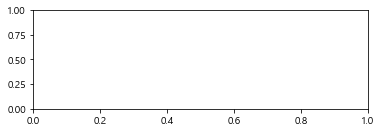

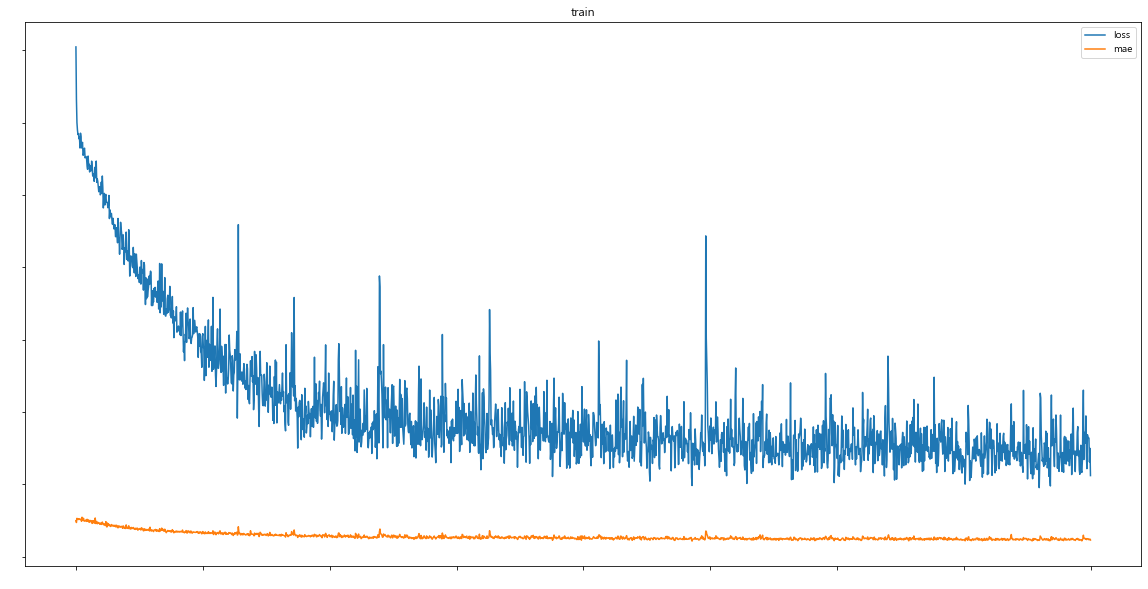

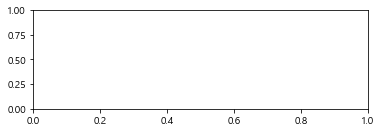

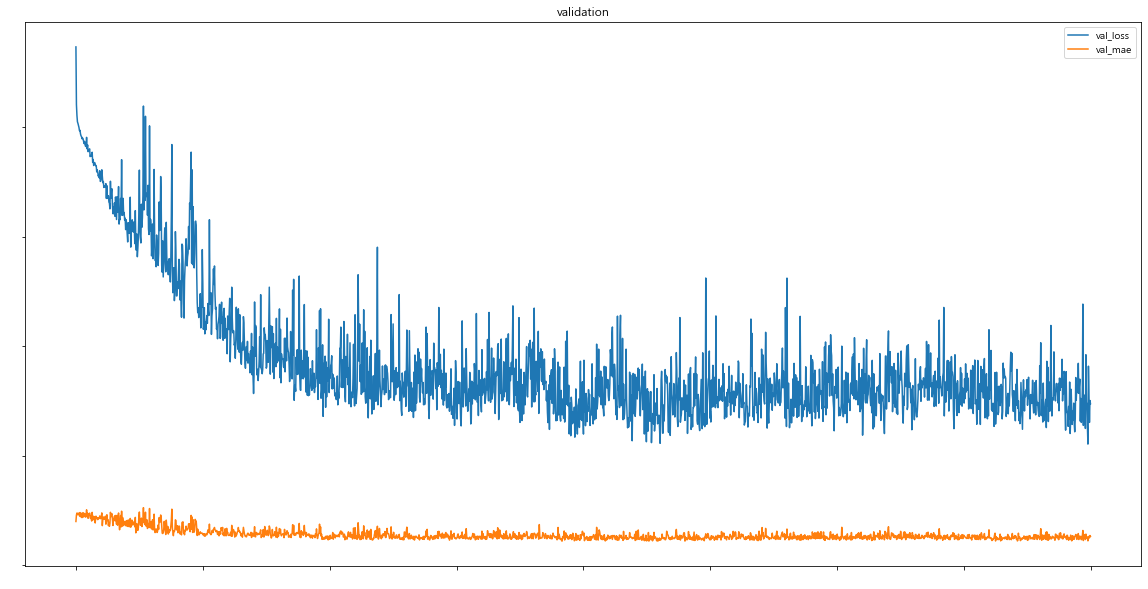

In [726]:
plt.subplot(2, 1, 1)
plt.figure(figsize=(20, 10))
plt.title("train")
plt.plot(history_mlp_봄.history['loss'], label='loss')
plt.plot(history_mlp_봄.history['mae'], label='mae')
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')
plt.legend()
plt.show()

plt.subplot(2, 1, 1)
plt.figure(figsize=(20, 10))
plt.title("validation")
plt.plot(history_mlp_봄.history['val_loss'], label='val_loss')
plt.plot(history_mlp_봄.history['val_mae'], label='val_mae')
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')
plt.legend()
plt.show()

# RandomForest

In [669]:
rf_봄 = RandomForestRegressor(random_state = 42)

param_rf_봄 = {
    'max_samples' : [0.2, 0.4, 0.7, 0.8, 1.0],
    'max_features' : [0.2, 0.4, 0.7, 0.8, 1.0],
    'n_estimators' : [10,50,100,150,200],
    'max_depth' : [3,5,7,10,15]
}

rf_grid_봄 = GridSearchCV(rf_봄, param_grid = param_rf_봄, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
rf_grid_봄.fit(X_train_봄, y_train_봄)

print("best_score :", -rf_grid_봄.best_score_)
print("best_params :", rf_grid_봄.best_params_)

Fitting 5 folds for each of 625 candidates, totalling 3125 fits
best_score : 2.6882569993153718
best_params : {'max_depth': 7, 'max_features': 1.0, 'max_samples': 0.7, 'n_estimators': 50}


In [670]:
model_rf_봄 = rf_grid_봄.best_estimator_
model_rf_pred_봄 = model_rf_봄.predict(X_test_봄)

rf_rmse_봄 = mean_squared_error(model_rf_pred_봄, y_test_봄, squared = False)

print("rmse :", rf_rmse_봄)
print("r2_score :", r2_score(y_test_봄, model_rf_pred_봄))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_봄, model_rf_pred_봄)) * (len(y_봄)-1)/(len(y_봄)-X_봄.shape[1]-1))

rmse : 1.8295433487288717
r2_score : 0.8738275971855771
adjusted r2_score : 0.8720036089613585


In [671]:
joblib.dump(model_rf_봄, 'model_rf_봄.pkl')
#model_rf_봄 = joblib.load('model_rf_봄.pkl')

['model_rf_봄.pkl']

# 여름

In [672]:
data_여름 = pd.read_excel("C:/Users/PC/Desktop/여름.xlsx")
data_여름

,id,관리기관,단지명,근로자수,근로손실일,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,재해율,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,17090775,한국산업단지공단 울산지역본부,울산미포국가산업단지,14284.0,289.5,True,5,5.456668e+09,157.4180,0.786894,...,0,0,0,0,0,0,0,0,0,0
1,12823536,한국산업단지공단 경남지역본부,창원국가산업단지,4771.0,280.0,True,4,3.708635e+09,172.7770,0.351079,...,0,0,0,0,2,0,0,0,0,0
2,16959388,한국산업단지공단 울산지역본부,울산미포국가산업단지,2997.0,294.0,True,1,2.780781e+09,53.0124,1.868535,...,0,0,0,0,0,0,0,0,0,0
3,13326267,한국산업단지공단 경남지역본부,창원국가산업단지,2039.0,230.5,True,4,8.497518e+09,223.4079,0.662089,...,0,0,0,0,2,0,0,0,0,0
4,3166196,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,367.0,166.0,True,1,4.213202e+08,149.3217,12.261580,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,3137645,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,5.0,49.0,False,7,5.428970e+05,192.0247,2.857143,...,1,0,0,0,0,0,0,0,0,0
1661,3137644,한국산업단지공단 경기지역본부,반월국가산업단지,4.0,124.0,False,5,5.579085e+05,196.6834,5.000000,...,0,0,0,0,0,0,0,0,0,0
1662,3137646,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,9.0,335.0,True,1,5.585063e+06,117.6545,11.111111,...,0,0,0,0,0,0,0,0,0,0
1663,3137642,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,21.0,47.0,False,13,5.564900e+06,204.5394,0.366300,...,0,0,0,0,0,0,0,0,0,0


In [673]:
data_여름.중대재해유무 = data_여름.중대재해유무.astype("int")
data_여름.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1665 entries, 0 to 1664
Data columns (total 89 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1665 non-null   int64  
 1   관리기관                       1665 non-null   object 
 2   단지명                        1665 non-null   object 
 3   근로자수                       1665 non-null   float64
 4   근로손실일                      1665 non-null   float64
 5   중대재해유무                     1665 non-null   int32  
 6   그리드 내 총 기업 수               1665 non-null   int64  
 7   매출액                        1665 non-null   float64
 8   부채비율                       1665 non-null   float64
 9   재해율                        1658 non-null   float64
 10  중업종_기계기구·금속·비금속광물제품제조업     1665 non-null   int64  
 11  중업종_선박건조및수리업               1665 non-null   int64  
 12  중업종_화학및고무제품제조업             1665 non-null   int64  
 13  중업종_전기기계기구·정밀기구·전자제품제조업    1665 non-null   int64

In [674]:
data_여름.drop(columns = data_여름.iloc[:, 10:71], inplace = True)
data_여름.head()

,id,관리기관,단지명,근로자수,근로손실일,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,재해율,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,17090775,한국산업단지공단 울산지역본부,울산미포국가산업단지,14284.0,289.5,1,5,5.456668e+09,157.4180,0.786894,...,0,0,0,0,0,0,0,0,0,0
1,12823536,한국산업단지공단 경남지역본부,창원국가산업단지,4771.0,280.0,1,4,3.708635e+09,172.7770,0.351079,...,0,0,0,0,2,0,0,0,0,0
2,16959388,한국산업단지공단 울산지역본부,울산미포국가산업단지,2997.0,294.0,1,1,2.780781e+09,53.0124,1.868535,...,0,0,0,0,0,0,0,0,0,0
3,13326267,한국산업단지공단 경남지역본부,창원국가산업단지,2039.0,230.5,1,4,8.497518e+09,223.4079,0.662089,...,0,0,0,0,2,0,0,0,0,0
4,3166196,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,367.0,166.0,1,1,4.213202e+08,149.3217,12.261580,...,0,0,0,0,0,0,0,0,0,0


In [675]:
data_여름.dropna(inplace = True)

# output 재해율

In [676]:
X_여름 = data_여름.drop(columns = ["id", "관리기관", "단지명", "근로손실일", "재해율"])
y_여름 = data_여름["재해율"]

In [677]:
scaler = MinMaxScaler()

X_여름 = pd.DataFrame(scaler.fit_transform(X_여름), columns = X_여름.columns)
X_여름.head()

,근로자수,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,중업종분류_기계기구 금속 비금속광물제품제조업,중업종분류_전기기계기구 정밀기구 전자제품제조업,중업종분류_전문 보건 교욱 여가관련서비스,중업종분류_출판 인쇄 제본또는인쇄물가공업,중업종분류_부동산업및임대업,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,1.000000,1.0,0.005222,0.162734,0.650240,0.006623,0.003704,0.017094,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
1,0.333963,1.0,0.003916,0.110602,0.650398,0.003311,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0
2,0.209760,1.0,0.000000,0.082930,0.649168,0.003311,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
3,0.142687,1.0,0.003916,0.253423,0.650918,0.003311,0.000000,0.008547,0.0,0.0,...,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0
4,0.025625,1.0,0.000000,0.012562,0.650157,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0


In [678]:
X_train_여름, X_test_여름, y_train_여름, y_test_여름 = train_test_split(X_여름, y_여름, test_size = 0.25, random_state = 42)

# XGBoost

In [755]:
xgb_여름 = XGBRegressor(early_sropping_rounds = 50, random_state = 42)

param_xgb_여름 = {
    'max_leaves' : [50, 100, 255],
    'n_estimators' : [100,200,300],
    'learning_rate' : [0.01,0.1,0.15,0.5],
    'max_depth' : [3,5,7,10,15],
    'gamma' : [0,1,2,3],
    'colsample_bytree' : [0.7,0.8,0.9]
}

xgb_grid_여름 = GridSearchCV(xgb_여름, param_grid = param_xgb_여름, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
xgb_grid_여름.fit(X_train_여름, y_train_여름)

print("best_score :", -xgb_grid_여름.best_score_)
print("best_params :", xgb_grid_여름.best_params_)

Fitting 5 folds for each of 2160 candidates, totalling 10800 fits
[16:13:17] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "early_sropping_rounds" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


best_score : 3.615250707841208
best_params : {'colsample_bytree': 0.7, 'gamma': 2, 'learning_rate': 0.15, 'max_depth': 3, 'max_leaves': 50, 'n_estimators': 200}


In [756]:
model_xgb_여름 = xgb_grid_여름.best_estimator_
model_xgb_pred_여름 = model_xgb_여름.predict(X_test_여름)

xgb_rmse_여름 = mean_squared_error(model_xgb_pred_여름, y_test_여름, squared = False)

print("rmse :", xgb_rmse_여름)
print("r2_score :", r2_score(y_test_여름, model_xgb_pred_여름))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_여름, model_xgb_pred_여름)) * (len(y_여름)-1)/(len(y_여름)-X_여름.shape[1]-1))

rmse : 2.4185678013423995
r2_score : 0.657039296398982
adjusted r2_score : 0.652211820154904


In [757]:
joblib.dump(model_xgb_여름, 'model_xgb_여름.pkl')
#model_xgb_여름 = joblib.load('model_xgb_여름.pkl')

['model_xgb_여름.pkl']

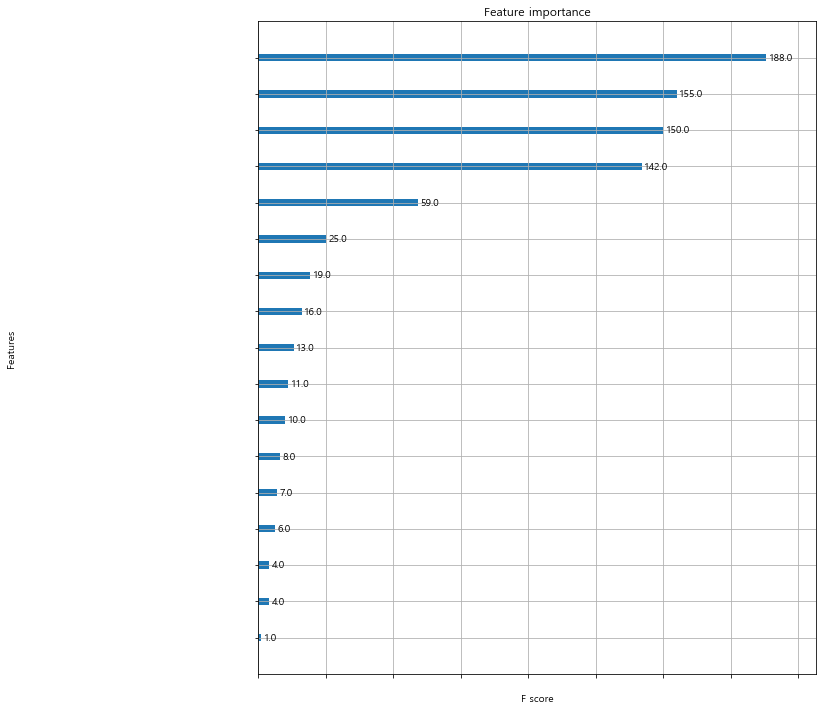

In [682]:
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(model_xgb_여름, ax=ax)
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

# GBM

In [758]:
gbm_여름 = GradientBoostingRegressor()

param_gbm_여름 = {
    'n_estimators' : [100,200,300,400],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'min_samples_leaf': [4, 8, 12, 18],
    'min_samples_split': [16, 20, 24],
    'max_depth' : [-1,3,7,10],
    'random_state' : [42]
}

gbm_grid_여름 = GridSearchCV(gbm_여름, param_grid = param_gbm_여름, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
gbm_grid_여름.fit(X_train_여름, y_train_여름)

print("best_score :", -gbm_grid_여름.best_score_)
print("best_params :", gbm_grid_여름.best_params_)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits



960 fits failed out of a total of 3840.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
960 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 596, in fit
    monitor,
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 672, in _fit_stages
    X_csr,
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 246, in _fit_stage
    tree.fit(X, residual, sample_weight=sample_weight, check_input=False)
  File "C:\Anaconda3\lib\site-packages\sklearn\tree\_classes.py"

best_score : 4.085124014358937
best_params : {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 12, 'min_samples_split': 16, 'n_estimators': 200, 'random_state': 42}


In [761]:
model_gbm_여름 = gbm_grid_여름.best_estimator_
model_gbm_pred_여름 = model_gbm_여름.predict(X_test_여름)

gbm_rmse_여름 = mean_squared_error(model_gbm_pred_여름, y_test_여름, squared = False)

print("rmse :", gbm_rmse_여름)
print("r2_score :", r2_score(y_test_여름, model_gbm_pred_여름))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_여름, model_gbm_pred_여름)) * (len(y_여름)-1)/(len(y_여름)-X_여름.shape[1]-1))

rmse : 2.6031827368256546
r2_score : 0.6026830078288852
adjusted r2_score : 0.5970904185877985


In [762]:
joblib.dump(model_gbm_여름, 'model_gbm_여름.pkl')
#model_gbm_여름 = joblib.load('model_gbm_여름.pkl')

['model_gbm_여름.pkl']

# LightGBM

In [683]:
lgb_여름 = LGBMRegressor(early_sropping_rounds = 50, random_state = 42)

param_lgb_여름 = {
    'num_leaves': [20, 40, 60, 80, 100],
    'n_estimators' : [50,100,200,300,400],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'max_depth' : [3,5,7,10,15],
    'gamma' : [0.1,0,1],
    'colsample_bytree' : [0.7,0.8,0.9]
}

lgb_grid_여름 = GridSearchCV(lgb_여름, param_grid = param_lgb_여름, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
lgb_grid_여름.fit(X_train_여름, y_train_여름)

print("best_score :", -lgb_grid_여름.best_score_)
print("best_params :", lgb_grid_여름.best_params_)

Fitting 5 folds for each of 4500 candidates, totalling 22500 fits
[LightGBM] [Warning] Unknown parameter: early_sropping_rounds
[LightGBM] [Warning] Unknown parameter: gamma
best_score : 4.443448045909697
best_params : {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 20}


In [684]:
model_lgb_여름 = lgb_grid_여름.best_estimator_
model_lgb_pred_여름 = model_lgb_여름.predict(X_test_여름)

lgb_rmse_여름 = mean_squared_error(model_lgb_pred_여름, y_test_여름, squared = False)

print("rmse :", lgb_rmse_여름)
print("r2_score :", r2_score(y_test_여름, model_lgb_pred_여름))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_여름, model_lgb_pred_여름)) * (len(y_여름)-1)/(len(y_여름)-X_여름.shape[1]-1))

rmse : 2.468408147326745
r2_score : 0.6427586101372189
adjusted r2_score : 0.637730120561427


In [685]:
joblib.dump(model_lgb_여름, 'model_lgb_여름.pkl')
#model_lgb_여름 = joblib.load('model_lgb_여름.pkl')

['model_lgb_여름.pkl']

# RandomForest

In [686]:
rf_여름 = RandomForestRegressor(random_state = 42)

param_rf_여름 = {
    'max_samples' : [0.2, 0.4, 0.7, 0.8, 1.0],
    'max_features' : [0.2, 0.4, 0.7, 0.8, 1.0],
    'n_estimators' : [10,50,100,150,200],
    'max_depth' : [3,5,7,10,15]
}

rf_grid_여름 = GridSearchCV(rf_여름, param_grid = param_rf_여름, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
rf_grid_여름.fit(X_train_여름, y_train_여름)

print("best_score :", -rf_grid_여름.best_score_)
print("best_params :", rf_grid_여름.best_params_)

Fitting 5 folds for each of 625 candidates, totalling 3125 fits
best_score : 3.919052372757996
best_params : {'max_depth': 15, 'max_features': 0.4, 'max_samples': 1.0, 'n_estimators': 100}


In [687]:
model_rf_여름 = rf_grid_여름.best_estimator_
model_rf_pred_여름 = model_rf_여름.predict(X_test_여름)

rf_rmse_여름 = mean_squared_error(model_rf_pred_여름, y_test_여름, squared = False)

print("rmse :", rf_rmse_여름)
print("r2_score :", r2_score(y_test_여름, model_rf_pred_여름))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_여름, model_rf_pred_여름)) * (len(y_여름)-1)/(len(y_여름)-X_여름.shape[1]-1))

rmse : 2.1420127444263932
r2_score : 0.7309878293262548
adjusted r2_score : 0.7272012443045314


In [688]:
joblib.dump(model_rf_여름, 'model_rf_여름.pkl')
#model_rf_여름 = joblib.load('model_rf_여름.pkl')

['model_rf_여름.pkl']

# MLP

In [721]:
epochs = 2000
batch_size = 32

model_mlp_여름 = Sequential()

model_mlp_여름.add(Dense(64, activation = "relu", input_dim = 23))
model_mlp_여름.add(Dropout(0.2))
model_mlp_여름.add(Dense(32, activation = "relu"))
model_mlp_여름.add(Dropout(0.2))
model_mlp_여름.add(Dense(16, activation = "relu"))
model_mlp_여름.add(Dropout(0.2))
model_mlp_여름.add(Dense(1))

model_mlp_여름.summary()

Model: "sequential_14"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_58 (Dense)             (None, 64)                1536      
_________________________________________________________________
dropout_44 (Dropout)         (None, 64)                0         
_________________________________________________________________
dense_59 (Dense)             (None, 32)                2080      
_________________________________________________________________
dropout_45 (Dropout)         (None, 32)                0         
_________________________________________________________________
dense_60 (Dense)             (None, 16)                528       
_________________________________________________________________
dropout_46 (Dropout)         (None, 16)                0         
_________________________________________________________________
dense_61 (Dense)             (None, 1)               

In [722]:
model_mlp_여름.compile(optimizer = "adam", loss = "mse", metrics = ["mae"])

#checkpoint_cb = ModelCheckPoint('filename.h5', save_best_only=True)
early_stopping = EarlyStopping(monitor = "val_mae", min_delta = 0.01, mode = "auto", patience = 3, restore_best_weights = True)

history_mlp_여름 = model_mlp_여름.fit(X_train_여름, y_train_여름, epochs = epochs, batch_size = batch_size, validation_split = 0.2, verbose = 1)

Train on 994 samples, validate on 249 samples
Epoch 1/2000
994/994 [==============================] - ETA: 26s - loss: 7.6445 - mae: 1.98 - 1s 1ms/sample - loss: 74.5090 - mae: 2.5816 - val_loss: 15.5413 - val_mae: 1.5323
Epoch 2/2000
994/994 [==============================] - ETA: 0s - loss: 42.9345 - mae: 3.39 - 0s 56us/sample - loss: 71.0518 - mae: 2.4944 - val_loss: 14.6123 - val_mae: 1.8740
Epoch 3/2000
994/994 [==============================] - ETA: 0s - loss: 23.6421 - mae: 2.43 - 0s 50us/sample - loss: 69.0853 - mae: 2.7582 - val_loss: 14.9456 - val_mae: 2.1064
Epoch 4/2000
994/994 [==============================] - ETA: 0s - loss: 8.9393 - mae: 2.263 - 0s 50us/sample - loss: 68.6780 - mae: 2.9267 - val_loss: 14.7026 - val_mae: 2.0270
Epoch 5/2000
994/994 [==============================] - ETA: 0s - loss: 36.2287 - mae: 3.37 - 0s 50us/sample - loss: 68.0985 - mae: 2.6918 - val_loss: 14.4923 - val_mae: 1.9576
Epoch 6/2000
994/994 [==============================] - ETA: 0s - loss

Epoch 47/2000
994/994 [==============================] - ETA: 0s - loss: 35.6847 - mae: 3.33 - 0s 49us/sample - loss: 64.5383 - mae: 2.5541 - val_loss: 14.0238 - val_mae: 2.0347
Epoch 48/2000
994/994 [==============================] - ETA: 0s - loss: 147.7170 - mae: 5.231 - 0s 47us/sample - loss: 64.5092 - mae: 2.6188 - val_loss: 13.2863 - val_mae: 1.8268
Epoch 49/2000
994/994 [==============================] - ETA: 0s - loss: 23.2768 - mae: 2.68 - 0s 45us/sample - loss: 64.9655 - mae: 2.4909 - val_loss: 13.7513 - val_mae: 1.9896
Epoch 50/2000
994/994 [==============================] - ETA: 0s - loss: 7.9741 - mae: 2.059 - 0s 45us/sample - loss: 64.0989 - mae: 2.6882 - val_loss: 12.8266 - val_mae: 1.6890
Epoch 51/2000
994/994 [==============================] - ETA: 0s - loss: 10.0105 - mae: 1.43 - 0s 42us/sample - loss: 64.9612 - mae: 2.5564 - val_loss: 13.0602 - val_mae: 1.7668
Epoch 52/2000
994/994 [==============================] - ETA: 0s - loss: 17.0781 - mae: 2.29 - 0s 43us/sampl

Epoch 93/2000
994/994 [==============================] - ETA: 0s - loss: 5.3742 - mae: 1.509 - 0s 42us/sample - loss: 59.4318 - mae: 2.3158 - val_loss: 13.6976 - val_mae: 2.0023
Epoch 94/2000
994/994 [==============================] - ETA: 0s - loss: 13.8149 - mae: 2.43 - 0s 49us/sample - loss: 56.2850 - mae: 2.3902 - val_loss: 11.7676 - val_mae: 1.6074
Epoch 95/2000
994/994 [==============================] - ETA: 0s - loss: 28.7386 - mae: 2.40 - 0s 45us/sample - loss: 61.4995 - mae: 2.3893 - val_loss: 12.4447 - val_mae: 1.8368
Epoch 96/2000
994/994 [==============================] - ETA: 0s - loss: 1120.4868 - mae: 8.25 - 0s 45us/sample - loss: 58.4273 - mae: 2.3208 - val_loss: 11.8208 - val_mae: 1.6510
Epoch 97/2000
994/994 [==============================] - ETA: 0s - loss: 6.7484 - mae: 1.718 - 0s 44us/sample - loss: 62.4353 - mae: 2.2893 - val_loss: 11.3466 - val_mae: 1.6254
Epoch 98/2000
994/994 [==============================] - ETA: 0s - loss: 321.5612 - mae: 5.654 - 0s 42us/sam

Epoch 139/2000
994/994 [==============================] - ETA: 0s - loss: 13.8033 - mae: 2.17 - 0s 44us/sample - loss: 59.3017 - mae: 2.3136 - val_loss: 11.2385 - val_mae: 1.6466
Epoch 140/2000
994/994 [==============================] - ETA: 0s - loss: 12.4362 - mae: 2.28 - 0s 43us/sample - loss: 58.8536 - mae: 2.5018 - val_loss: 13.0810 - val_mae: 1.9868
Epoch 141/2000
994/994 [==============================] - ETA: 0s - loss: 22.5463 - mae: 2.61 - 0s 46us/sample - loss: 56.1260 - mae: 2.3064 - val_loss: 10.7092 - val_mae: 1.5336
Epoch 142/2000
994/994 [==============================] - ETA: 0s - loss: 11.8089 - mae: 1.40 - 0s 42us/sample - loss: 59.4504 - mae: 2.2033 - val_loss: 10.8645 - val_mae: 1.6312
Epoch 143/2000
994/994 [==============================] - ETA: 0s - loss: 15.9164 - mae: 2.42 - 0s 42us/sample - loss: 56.1729 - mae: 2.3049 - val_loss: 11.5299 - val_mae: 1.6773
Epoch 144/2000
994/994 [==============================] - ETA: 0s - loss: 9.6530 - mae: 2.300 - 0s 43us/s

Epoch 185/2000
994/994 [==============================] - ETA: 0s - loss: 9.5989 - mae: 1.674 - 0s 50us/sample - loss: 54.2407 - mae: 2.2052 - val_loss: 10.1165 - val_mae: 1.4492
Epoch 186/2000
994/994 [==============================] - ETA: 0s - loss: 16.7274 - mae: 1.71 - 0s 48us/sample - loss: 51.3673 - mae: 2.0649 - val_loss: 11.0635 - val_mae: 1.6354
Epoch 187/2000
994/994 [==============================] - ETA: 0s - loss: 7.5062 - mae: 1.833 - 0s 48us/sample - loss: 51.1427 - mae: 2.0895 - val_loss: 11.7032 - val_mae: 1.7529
Epoch 188/2000
994/994 [==============================] - ETA: 0s - loss: 13.2937 - mae: 2.19 - 0s 48us/sample - loss: 54.2274 - mae: 2.1004 - val_loss: 9.0031 - val_mae: 1.4093
Epoch 189/2000
994/994 [==============================] - ETA: 0s - loss: 26.1940 - mae: 2.22 - 0s 47us/sample - loss: 49.3141 - mae: 2.1247 - val_loss: 10.0485 - val_mae: 1.4422
Epoch 190/2000
994/994 [==============================] - ETA: 0s - loss: 21.3419 - mae: 2.42 - 0s 50us/sa

Epoch 231/2000
994/994 [==============================] - ETA: 0s - loss: 33.3762 - mae: 1.93 - 0s 46us/sample - loss: 50.7834 - mae: 1.9428 - val_loss: 10.0384 - val_mae: 1.6338
Epoch 232/2000
994/994 [==============================] - ETA: 0s - loss: 12.9099 - mae: 2.03 - 0s 45us/sample - loss: 48.0020 - mae: 1.9951 - val_loss: 10.4591 - val_mae: 1.6790
Epoch 233/2000
994/994 [==============================] - ETA: 0s - loss: 14.3745 - mae: 2.18 - 0s 42us/sample - loss: 45.4817 - mae: 2.1788 - val_loss: 9.9068 - val_mae: 1.3907
Epoch 234/2000
994/994 [==============================] - ETA: 0s - loss: 11.0833 - mae: 1.67 - 0s 44us/sample - loss: 47.6350 - mae: 2.0437 - val_loss: 7.7669 - val_mae: 1.2047
Epoch 235/2000
994/994 [==============================] - ETA: 0s - loss: 4.3371 - mae: 1.339 - 0s 44us/sample - loss: 48.5524 - mae: 1.8869 - val_loss: 8.6401 - val_mae: 1.6358
Epoch 236/2000
994/994 [==============================] - ETA: 0s - loss: 16.6014 - mae: 2.26 - 0s 47us/samp

Epoch 277/2000
994/994 [==============================] - ETA: 0s - loss: 6.0632 - mae: 1.536 - 0s 35us/sample - loss: 43.2625 - mae: 1.8924 - val_loss: 7.8997 - val_mae: 1.4070
Epoch 278/2000
994/994 [==============================] - ETA: 0s - loss: 2.0497 - mae: 1.143 - 0s 44us/sample - loss: 47.4549 - mae: 2.1584 - val_loss: 8.0226 - val_mae: 1.2042
Epoch 279/2000
994/994 [==============================] - ETA: 0s - loss: 6.3686 - mae: 1.356 - 0s 43us/sample - loss: 46.0012 - mae: 1.9642 - val_loss: 7.2518 - val_mae: 1.2218
Epoch 280/2000
994/994 [==============================] - ETA: 0s - loss: 6.2898 - mae: 1.177 - 0s 45us/sample - loss: 43.1826 - mae: 1.9957 - val_loss: 7.0495 - val_mae: 1.3139
Epoch 281/2000
994/994 [==============================] - ETA: 0s - loss: 35.8792 - mae: 3.02 - 0s 43us/sample - loss: 44.0055 - mae: 1.8892 - val_loss: 6.7402 - val_mae: 1.2956
Epoch 282/2000
994/994 [==============================] - ETA: 0s - loss: 7.4572 - mae: 1.453 - 0s 44us/sample

Epoch 323/2000
994/994 [==============================] - ETA: 0s - loss: 3.5959 - mae: 1.270 - 0s 43us/sample - loss: 49.0145 - mae: 2.0596 - val_loss: 9.0174 - val_mae: 1.4261
Epoch 324/2000
994/994 [==============================] - ETA: 0s - loss: 726.1531 - mae: 5.596 - 0s 44us/sample - loss: 48.1471 - mae: 2.1751 - val_loss: 7.8785 - val_mae: 1.1957
Epoch 325/2000
994/994 [==============================] - ETA: 0s - loss: 12.0749 - mae: 1.76 - 0s 45us/sample - loss: 42.0200 - mae: 1.9187 - val_loss: 9.7714 - val_mae: 1.5739
Epoch 326/2000
994/994 [==============================] - ETA: 0s - loss: 27.7636 - mae: 2.46 - 0s 45us/sample - loss: 46.7952 - mae: 2.0212 - val_loss: 8.5220 - val_mae: 1.3874
Epoch 327/2000
994/994 [==============================] - ETA: 0s - loss: 11.9247 - mae: 2.07 - 0s 47us/sample - loss: 47.5299 - mae: 1.9512 - val_loss: 10.6057 - val_mae: 1.5765
Epoch 328/2000
994/994 [==============================] - ETA: 0s - loss: 5.9493 - mae: 1.477 - 0s 43us/sam

Epoch 369/2000
994/994 [==============================] - ETA: 0s - loss: 51.2126 - mae: 2.53 - 0s 44us/sample - loss: 44.3760 - mae: 1.9059 - val_loss: 6.6764 - val_mae: 1.3241
Epoch 370/2000
994/994 [==============================] - ETA: 0s - loss: 2.1040 - mae: 1.014 - 0s 44us/sample - loss: 42.4738 - mae: 1.9755 - val_loss: 6.5500 - val_mae: 1.1558
Epoch 371/2000
994/994 [==============================] - ETA: 0s - loss: 12.5553 - mae: 1.78 - 0s 44us/sample - loss: 42.8865 - mae: 1.9228 - val_loss: 7.8969 - val_mae: 1.3828
Epoch 372/2000
994/994 [==============================] - ETA: 0s - loss: 523.3198 - mae: 5.020 - 0s 45us/sample - loss: 38.0537 - mae: 1.9325 - val_loss: 6.0468 - val_mae: 1.1844
Epoch 373/2000
994/994 [==============================] - ETA: 0s - loss: 6.7978 - mae: 1.792 - 0s 46us/sample - loss: 46.4907 - mae: 2.0197 - val_loss: 11.3478 - val_mae: 1.5982
Epoch 374/2000
994/994 [==============================] - ETA: 0s - loss: 5.1737 - mae: 1.468 - 0s 43us/sam

Epoch 415/2000
994/994 [==============================] - ETA: 0s - loss: 665.3480 - mae: 5.824 - 0s 46us/sample - loss: 39.0522 - mae: 2.0024 - val_loss: 6.8280 - val_mae: 1.1731
Epoch 416/2000
994/994 [==============================] - ETA: 0s - loss: 1.8501 - mae: 1.057 - 0s 44us/sample - loss: 41.3319 - mae: 1.9193 - val_loss: 5.4299 - val_mae: 1.1949
Epoch 417/2000
994/994 [==============================] - ETA: 0s - loss: 27.9168 - mae: 2.26 - 0s 42us/sample - loss: 45.4874 - mae: 1.8917 - val_loss: 7.8026 - val_mae: 1.4915
Epoch 418/2000
994/994 [==============================] - ETA: 0s - loss: 42.5444 - mae: 2.02 - 0s 42us/sample - loss: 33.7448 - mae: 2.0284 - val_loss: 6.6343 - val_mae: 1.1788
Epoch 419/2000
994/994 [==============================] - ETA: 0s - loss: 1.9050 - mae: 0.970 - 0s 48us/sample - loss: 39.0264 - mae: 1.9155 - val_loss: 4.5785 - val_mae: 1.2337
Epoch 420/2000
994/994 [==============================] - ETA: 0s - loss: 490.2894 - mae: 4.967 - 0s 54us/sa

Epoch 461/2000
994/994 [==============================] - ETA: 0s - loss: 29.7570 - mae: 2.37 - 0s 44us/sample - loss: 43.1481 - mae: 1.8844 - val_loss: 5.2189 - val_mae: 1.1582
Epoch 462/2000
994/994 [==============================] - ETA: 0s - loss: 2.4956 - mae: 1.224 - 0s 43us/sample - loss: 32.2571 - mae: 1.7118 - val_loss: 4.9954 - val_mae: 1.3957
Epoch 463/2000
994/994 [==============================] - ETA: 0s - loss: 3.5247 - mae: 1.269 - 0s 43us/sample - loss: 42.2145 - mae: 2.0746 - val_loss: 8.1238 - val_mae: 1.1569
Epoch 464/2000
994/994 [==============================] - ETA: 0s - loss: 12.6142 - mae: 1.76 - 0s 45us/sample - loss: 41.2562 - mae: 2.0301 - val_loss: 5.2261 - val_mae: 1.1899
Epoch 465/2000
994/994 [==============================] - ETA: 0s - loss: 13.4281 - mae: 1.71 - 0s 55us/sample - loss: 33.8972 - mae: 1.8930 - val_loss: 4.8113 - val_mae: 1.2873
Epoch 466/2000
994/994 [==============================] - ETA: 0s - loss: 43.7687 - mae: 3.14 - 0s 54us/sample

Epoch 553/2000
994/994 [==============================] - ETA: 0s - loss: 14.4125 - mae: 2.05 - 0s 46us/sample - loss: 28.4694 - mae: 1.7694 - val_loss: 3.8076 - val_mae: 1.1658
Epoch 554/2000
994/994 [==============================] - ETA: 0s - loss: 1.8989 - mae: 1.017 - 0s 47us/sample - loss: 34.3114 - mae: 1.8728 - val_loss: 4.2370 - val_mae: 1.1201
Epoch 555/2000
994/994 [==============================] - ETA: 0s - loss: 6.3098 - mae: 1.507 - 0s 46us/sample - loss: 38.9086 - mae: 1.8318 - val_loss: 6.1829 - val_mae: 1.1367
Epoch 556/2000
994/994 [==============================] - ETA: 0s - loss: 16.9064 - mae: 2.06 - 0s 46us/sample - loss: 36.1691 - mae: 1.8309 - val_loss: 4.7448 - val_mae: 1.3535
Epoch 557/2000
994/994 [==============================] - ETA: 0s - loss: 14.1925 - mae: 1.93 - 0s 44us/sample - loss: 36.2730 - mae: 1.8070 - val_loss: 4.1982 - val_mae: 1.1148
Epoch 558/2000
994/994 [==============================] - ETA: 0s - loss: 6.2397 - mae: 1.394 - 0s 56us/sample

Epoch 644/2000
994/994 [==============================] - ETA: 0s - loss: 16.1104 - mae: 2.08 - 0s 45us/sample - loss: 42.3673 - mae: 1.8698 - val_loss: 5.0810 - val_mae: 1.1002
Epoch 645/2000
994/994 [==============================] - ETA: 0s - loss: 8.3400 - mae: 1.537 - 0s 42us/sample - loss: 39.0085 - mae: 1.7812 - val_loss: 3.9380 - val_mae: 1.1685
Epoch 646/2000
994/994 [==============================] - ETA: 0s - loss: 3.9221 - mae: 0.916 - 0s 47us/sample - loss: 33.7795 - mae: 1.6445 - val_loss: 4.2225 - val_mae: 1.2185
Epoch 647/2000
994/994 [==============================] - ETA: 0s - loss: 12.3785 - mae: 1.80 - 0s 46us/sample - loss: 32.2786 - mae: 1.8118 - val_loss: 3.6992 - val_mae: 1.1725
Epoch 648/2000
994/994 [==============================] - ETA: 0s - loss: 18.9514 - mae: 2.38 - 0s 44us/sample - loss: 39.3393 - mae: 1.7775 - val_loss: 6.0674 - val_mae: 1.2491
Epoch 649/2000
994/994 [==============================] - ETA: 0s - loss: 84.4036 - mae: 3.32 - 0s 42us/sample

Epoch 690/2000
994/994 [==============================] - ETA: 0s - loss: 20.6355 - mae: 2.02 - ETA: 0s - loss: 56.9285 - mae: 2.00 - 0s 71us/sample - loss: 51.9113 - mae: 1.9716 - val_loss: 3.3071 - val_mae: 1.2313
Epoch 691/2000
994/994 [==============================] - ETA: 0s - loss: 17.1597 - mae: 1.91 - 0s 47us/sample - loss: 32.2289 - mae: 1.7737 - val_loss: 5.7447 - val_mae: 1.0592
Epoch 692/2000
994/994 [==============================] - ETA: 0s - loss: 2.8121 - mae: 1.000 - 0s 46us/sample - loss: 32.7771 - mae: 1.8250 - val_loss: 4.0264 - val_mae: 1.0661
Epoch 693/2000
994/994 [==============================] - ETA: 0s - loss: 26.1688 - mae: 2.18 - 0s 44us/sample - loss: 27.7159 - mae: 1.6011 - val_loss: 3.3829 - val_mae: 1.1095
Epoch 694/2000
994/994 [==============================] - ETA: 0s - loss: 16.2644 - mae: 1.60 - 0s 44us/sample - loss: 30.0126 - mae: 1.8085 - val_loss: 8.4184 - val_mae: 1.1417
Epoch 695/2000
994/994 [==============================] - ETA: 0s - loss

Epoch 736/2000
994/994 [==============================] - ETA: 0s - loss: 606.8302 - mae: 5.351 - 0s 48us/sample - loss: 32.8052 - mae: 1.8138 - val_loss: 4.0913 - val_mae: 1.1519
Epoch 737/2000
994/994 [==============================] - ETA: 0s - loss: 2.6421 - mae: 1.183 - 0s 46us/sample - loss: 36.6181 - mae: 1.7763 - val_loss: 3.2858 - val_mae: 1.1892
Epoch 738/2000
994/994 [==============================] - ETA: 0s - loss: 42.0087 - mae: 2.19 - 0s 46us/sample - loss: 19.8037 - mae: 1.6577 - val_loss: 5.1526 - val_mae: 1.1116
Epoch 739/2000
994/994 [==============================] - ETA: 0s - loss: 59.0602 - mae: 3.05 - 0s 45us/sample - loss: 35.2803 - mae: 1.7434 - val_loss: 3.3036 - val_mae: 1.2794
Epoch 740/2000
994/994 [==============================] - ETA: 0s - loss: 4.2284 - mae: 1.400 - 0s 45us/sample - loss: 20.8426 - mae: 1.7833 - val_loss: 4.4155 - val_mae: 1.1046
Epoch 741/2000
994/994 [==============================] - ETA: 0s - loss: 2.6480 - mae: 1.064 - 0s 43us/samp

Epoch 782/2000
994/994 [==============================] - ETA: 0s - loss: 3.4500 - mae: 1.127 - 0s 44us/sample - loss: 27.9738 - mae: 1.6637 - val_loss: 3.2897 - val_mae: 1.1289
Epoch 783/2000
994/994 [==============================] - ETA: 0s - loss: 35.9352 - mae: 3.14 - 0s 53us/sample - loss: 19.9167 - mae: 1.6391 - val_loss: 3.2357 - val_mae: 1.0768
Epoch 784/2000
994/994 [==============================] - ETA: 0s - loss: 1.8896 - mae: 0.741 - 0s 44us/sample - loss: 22.9793 - mae: 1.6308 - val_loss: 3.3144 - val_mae: 1.0689
Epoch 785/2000
994/994 [==============================] - ETA: 0s - loss: 2.3912 - mae: 1.057 - 0s 44us/sample - loss: 25.9814 - mae: 1.6722 - val_loss: 3.3042 - val_mae: 1.1222
Epoch 786/2000
994/994 [==============================] - ETA: 0s - loss: 269.6141 - mae: 4.840 - 0s 43us/sample - loss: 27.7482 - mae: 1.7634 - val_loss: 4.7573 - val_mae: 1.0470
Epoch 787/2000
994/994 [==============================] - ETA: 0s - loss: 2.3419 - mae: 1.115 - 0s 43us/samp

Epoch 828/2000
994/994 [==============================] - ETA: 0s - loss: 6.0218 - mae: 1.610 - 0s 43us/sample - loss: 22.8666 - mae: 1.6864 - val_loss: 3.3653 - val_mae: 1.0514
Epoch 829/2000
994/994 [==============================] - ETA: 0s - loss: 9.5919 - mae: 1.527 - 0s 42us/sample - loss: 29.6365 - mae: 1.6727 - val_loss: 3.4109 - val_mae: 1.1018
Epoch 830/2000
994/994 [==============================] - ETA: 0s - loss: 2.0737 - mae: 0.965 - 0s 46us/sample - loss: 24.5256 - mae: 1.6038 - val_loss: 4.4617 - val_mae: 1.0617
Epoch 831/2000
994/994 [==============================] - ETA: 0s - loss: 2.1177 - mae: 0.910 - 0s 44us/sample - loss: 37.6060 - mae: 1.6795 - val_loss: 4.1143 - val_mae: 1.0415
Epoch 832/2000
994/994 [==============================] - ETA: 0s - loss: 1.9466 - mae: 0.952 - 0s 42us/sample - loss: 39.8673 - mae: 1.6785 - val_loss: 4.4013 - val_mae: 1.0658
Epoch 833/2000
994/994 [==============================] - ETA: 0s - loss: 18.2642 - mae: 2.10 - 0s 45us/sample

Epoch 920/2000
994/994 [==============================] - ETA: 0s - loss: 2.7304 - mae: 1.235 - 0s 43us/sample - loss: 41.1114 - mae: 1.8687 - val_loss: 4.1960 - val_mae: 1.1177
Epoch 921/2000
994/994 [==============================] - ETA: 0s - loss: 156.0061 - mae: 3.184 - 0s 42us/sample - loss: 33.9089 - mae: 1.8375 - val_loss: 3.8582 - val_mae: 1.1607
Epoch 922/2000
994/994 [==============================] - ETA: 0s - loss: 7.3978 - mae: 1.652 - 0s 45us/sample - loss: 37.8778 - mae: 1.7234 - val_loss: 5.7445 - val_mae: 1.1558
Epoch 923/2000
994/994 [==============================] - ETA: 0s - loss: 3.2858 - mae: 1.170 - 0s 43us/sample - loss: 38.9220 - mae: 1.8148 - val_loss: 3.9033 - val_mae: 1.1245
Epoch 924/2000
994/994 [==============================] - ETA: 0s - loss: 4.9105 - mae: 1.413 - 0s 41us/sample - loss: 26.7427 - mae: 1.7129 - val_loss: 3.1054 - val_mae: 1.2066
Epoch 925/2000
994/994 [==============================] - ETA: 0s - loss: 4.7746 - mae: 1.368 - 0s 44us/samp

Epoch 966/2000
994/994 [==============================] - ETA: 0s - loss: 30.8774 - mae: 2.48 - 0s 44us/sample - loss: 35.1961 - mae: 1.6880 - val_loss: 6.6440 - val_mae: 1.0968
Epoch 967/2000
994/994 [==============================] - ETA: 0s - loss: 2.1191 - mae: 1.024 - 0s 43us/sample - loss: 43.6708 - mae: 1.9003 - val_loss: 4.0717 - val_mae: 1.2729
Epoch 968/2000
994/994 [==============================] - ETA: 0s - loss: 6.9838 - mae: 1.352 - 0s 44us/sample - loss: 27.7863 - mae: 1.7368 - val_loss: 4.1432 - val_mae: 1.0834
Epoch 969/2000
994/994 [==============================] - ETA: 0s - loss: 11.6410 - mae: 1.83 - 0s 42us/sample - loss: 30.0754 - mae: 1.6740 - val_loss: 3.9689 - val_mae: 1.1302
Epoch 970/2000
994/994 [==============================] - ETA: 0s - loss: 6.0476 - mae: 1.319 - 0s 42us/sample - loss: 26.0320 - mae: 1.5622 - val_loss: 3.9037 - val_mae: 1.1454
Epoch 971/2000
994/994 [==============================] - ETA: 0s - loss: 9.5295 - mae: 1.632 - 0s 44us/sample

Epoch 1012/2000
994/994 [==============================] - ETA: 0s - loss: 3.2969 - mae: 0.914 - 0s 42us/sample - loss: 33.6130 - mae: 1.6692 - val_loss: 3.4938 - val_mae: 1.0524
Epoch 1013/2000
994/994 [==============================] - ETA: 0s - loss: 5.5586 - mae: 1.366 - 0s 43us/sample - loss: 27.2156 - mae: 1.6004 - val_loss: 3.5714 - val_mae: 1.0874
Epoch 1014/2000
994/994 [==============================] - ETA: 0s - loss: 5.2710 - mae: 1.274 - 0s 44us/sample - loss: 30.2474 - mae: 1.6087 - val_loss: 3.1778 - val_mae: 1.0905
Epoch 1015/2000
994/994 [==============================] - ETA: 0s - loss: 4.1731 - mae: 1.370 - 0s 42us/sample - loss: 42.2419 - mae: 1.7499 - val_loss: 4.8948 - val_mae: 1.0697
Epoch 1016/2000
994/994 [==============================] - ETA: 0s - loss: 2.8916 - mae: 1.201 - 0s 43us/sample - loss: 33.1298 - mae: 1.6479 - val_loss: 3.6014 - val_mae: 1.1416
Epoch 1017/2000
994/994 [==============================] - ETA: 0s - loss: 3.5862 - mae: 1.084 - 0s 45us/

Epoch 1058/2000
994/994 [==============================] - ETA: 0s - loss: 3.1171 - mae: 1.289 - 0s 42us/sample - loss: 21.7288 - mae: 1.6399 - val_loss: 2.9288 - val_mae: 1.0435
Epoch 1059/2000
994/994 [==============================] - ETA: 0s - loss: 6.3409 - mae: 1.598 - 0s 44us/sample - loss: 19.5101 - mae: 1.6013 - val_loss: 2.9731 - val_mae: 1.0936
Epoch 1060/2000
994/994 [==============================] - ETA: 0s - loss: 5.9548 - mae: 1.731 - 0s 44us/sample - loss: 37.1188 - mae: 1.7070 - val_loss: 3.2341 - val_mae: 1.0464
Epoch 1061/2000
994/994 [==============================] - ETA: 0s - loss: 89.7172 - mae: 2.81 - 0s 42us/sample - loss: 30.9599 - mae: 1.6436 - val_loss: 2.9233 - val_mae: 1.0843
Epoch 1062/2000
994/994 [==============================] - ETA: 0s - loss: 8.7249 - mae: 1.966 - 0s 45us/sample - loss: 33.4898 - mae: 2.1374 - val_loss: 4.3993 - val_mae: 1.0303
Epoch 1063/2000
994/994 [==============================] - ETA: 0s - loss: 10.4042 - mae: 1.80 - 0s 44us/

Epoch 1104/2000
994/994 [==============================] - ETA: 0s - loss: 2.0958 - mae: 1.016 - 0s 44us/sample - loss: 21.1729 - mae: 1.5182 - val_loss: 3.0470 - val_mae: 1.0625
Epoch 1105/2000
994/994 [==============================] - ETA: 0s - loss: 17.3434 - mae: 2.02 - 0s 49us/sample - loss: 18.0863 - mae: 1.5955 - val_loss: 3.1359 - val_mae: 1.0397
Epoch 1106/2000
994/994 [==============================] - ETA: 0s - loss: 2.8427 - mae: 1.207 - 0s 56us/sample - loss: 26.2624 - mae: 1.5802 - val_loss: 3.4167 - val_mae: 1.0507
Epoch 1107/2000
994/994 [==============================] - ETA: 0s - loss: 3.9929 - mae: 1.371 - 0s 58us/sample - loss: 11.6094 - mae: 1.4322 - val_loss: 2.8159 - val_mae: 1.0696
Epoch 1108/2000
994/994 [==============================] - ETA: 0s - loss: 10.7214 - mae: 1.98 - 0s 44us/sample - loss: 18.6812 - mae: 1.5009 - val_loss: 3.1884 - val_mae: 1.1263
Epoch 1109/2000
994/994 [==============================] - ETA: 0s - loss: 2.6137 - mae: 1.162 - 0s 43us/

Epoch 1195/2000
994/994 [==============================] - ETA: 0s - loss: 2.2015 - mae: 0.987 - 0s 45us/sample - loss: 61.6910 - mae: 2.0413 - val_loss: 9.4695 - val_mae: 1.4310
Epoch 1196/2000
994/994 [==============================] - ETA: 0s - loss: 17.7744 - mae: 1.85 - 0s 42us/sample - loss: 60.3417 - mae: 2.1192 - val_loss: 9.0532 - val_mae: 1.4287
Epoch 1197/2000
994/994 [==============================] - ETA: 0s - loss: 57.7817 - mae: 2.61 - 0s 42us/sample - loss: 58.6226 - mae: 2.0664 - val_loss: 8.5612 - val_mae: 1.3974
Epoch 1198/2000
994/994 [==============================] - ETA: 0s - loss: 1173.8384 - mae: 7.40 - 0s 43us/sample - loss: 58.6548 - mae: 2.0815 - val_loss: 8.2718 - val_mae: 1.4158
Epoch 1199/2000
994/994 [==============================] - ETA: 0s - loss: 4.1491 - mae: 1.355 - 0s 41us/sample - loss: 57.9621 - mae: 1.9637 - val_loss: 8.0985 - val_mae: 1.3981
Epoch 1200/2000
994/994 [==============================] - ETA: 0s - loss: 39.3001 - mae: 2.39 - 0s 44u

Epoch 1241/2000
994/994 [==============================] - ETA: 0s - loss: 2.7858 - mae: 1.146 - 0s 43us/sample - loss: 45.9903 - mae: 1.8675 - val_loss: 3.9463 - val_mae: 1.1648
Epoch 1242/2000
994/994 [==============================] - ETA: 0s - loss: 4.5705 - mae: 1.451 - 0s 42us/sample - loss: 41.1566 - mae: 1.7783 - val_loss: 3.6213 - val_mae: 1.2120
Epoch 1243/2000
994/994 [==============================] - ETA: 0s - loss: 9.1257 - mae: 1.710 - 0s 44us/sample - loss: 57.2817 - mae: 3.1742 - val_loss: 11.4709 - val_mae: 1.6607
Epoch 1244/2000
994/994 [==============================] - ETA: 0s - loss: 63.5011 - mae: 3.18 - 0s 43us/sample - loss: 46.3456 - mae: 2.2759 - val_loss: 10.0457 - val_mae: 1.3984
Epoch 1245/2000
994/994 [==============================] - ETA: 0s - loss: 13.1241 - mae: 2.03 - 0s 45us/sample - loss: 46.7282 - mae: 2.0505 - val_loss: 5.1005 - val_mae: 1.2376
Epoch 1246/2000
994/994 [==============================] - ETA: 0s - loss: 1.9435 - mae: 1.036 - 0s 44u

Epoch 1287/2000
994/994 [==============================] - ETA: 0s - loss: 3.3074 - mae: 1.242 - 0s 44us/sample - loss: 51.1238 - mae: 2.0085 - val_loss: 4.1777 - val_mae: 1.1450
Epoch 1288/2000
994/994 [==============================] - ETA: 0s - loss: 8.1759 - mae: 1.524 - 0s 43us/sample - loss: 40.8255 - mae: 2.0084 - val_loss: 5.2955 - val_mae: 1.1909
Epoch 1289/2000
994/994 [==============================] - ETA: 0s - loss: 3.0612 - mae: 1.158 - 0s 43us/sample - loss: 25.7576 - mae: 1.8228 - val_loss: 4.4800 - val_mae: 1.2170
Epoch 1290/2000
994/994 [==============================] - ETA: 0s - loss: 6.7526 - mae: 1.237 - 0s 44us/sample - loss: 38.7176 - mae: 1.9018 - val_loss: 3.2036 - val_mae: 1.1503
Epoch 1291/2000
994/994 [==============================] - ETA: 0s - loss: 7.1828 - mae: 1.471 - 0s 44us/sample - loss: 24.4754 - mae: 1.7315 - val_loss: 4.0268 - val_mae: 1.1914
Epoch 1292/2000
994/994 [==============================] - ETA: 0s - loss: 5.1074 - mae: 1.433 - 0s 45us/

Epoch 1378/2000
994/994 [==============================] - ETA: 0s - loss: 7.1488 - mae: 1.229 - 0s 46us/sample - loss: 30.6190 - mae: 1.7014 - val_loss: 3.4976 - val_mae: 1.0977
Epoch 1379/2000
994/994 [==============================] - ETA: 0s - loss: 2.3847 - mae: 1.103 - 0s 43us/sample - loss: 29.9986 - mae: 1.8138 - val_loss: 3.2629 - val_mae: 1.1122
Epoch 1380/2000
994/994 [==============================] - ETA: 0s - loss: 9.7739 - mae: 1.465 - 0s 43us/sample - loss: 24.2409 - mae: 1.6671 - val_loss: 4.0762 - val_mae: 1.1053
Epoch 1381/2000
994/994 [==============================] - ETA: 0s - loss: 2.0422 - mae: 1.087 - 0s 44us/sample - loss: 32.3933 - mae: 1.7033 - val_loss: 3.8738 - val_mae: 1.0963
Epoch 1382/2000
994/994 [==============================] - ETA: 0s - loss: 10.5362 - mae: 1.54 - 0s 46us/sample - loss: 19.2297 - mae: 1.6918 - val_loss: 3.2112 - val_mae: 1.0923
Epoch 1383/2000
994/994 [==============================] - ETA: 0s - loss: 11.0839 - mae: 2.18 - 0s 44us/

Epoch 1469/2000
994/994 [==============================] - ETA: 0s - loss: 6.3666 - mae: 1.577 - 0s 43us/sample - loss: 24.3873 - mae: 1.6079 - val_loss: 3.3115 - val_mae: 1.0889
Epoch 1470/2000
994/994 [==============================] - ETA: 0s - loss: 9.5409 - mae: 1.790 - 0s 44us/sample - loss: 36.1364 - mae: 1.7801 - val_loss: 3.6183 - val_mae: 1.1042
Epoch 1471/2000
994/994 [==============================] - ETA: 0s - loss: 3.9408 - mae: 1.254 - 0s 43us/sample - loss: 32.3631 - mae: 1.6399 - val_loss: 2.7891 - val_mae: 1.0944
Epoch 1472/2000
994/994 [==============================] - ETA: 0s - loss: 5.6797 - mae: 1.633 - 0s 46us/sample - loss: 13.1114 - mae: 1.5953 - val_loss: 4.9164 - val_mae: 1.0694
Epoch 1473/2000
994/994 [==============================] - ETA: 0s - loss: 1.4335 - mae: 0.942 - 0s 45us/sample - loss: 42.8294 - mae: 1.7365 - val_loss: 2.8101 - val_mae: 1.1599
Epoch 1474/2000
994/994 [==============================] - ETA: 0s - loss: 12.3614 - mae: 1.79 - 0s 46us/

Epoch 1515/2000
994/994 [==============================] - ETA: 0s - loss: 8.9863 - mae: 1.936 - 0s 46us/sample - loss: 34.2849 - mae: 1.6472 - val_loss: 3.6325 - val_mae: 1.0542
Epoch 1516/2000
994/994 [==============================] - ETA: 0s - loss: 4.5346 - mae: 1.230 - 0s 44us/sample - loss: 23.5980 - mae: 1.6657 - val_loss: 3.1013 - val_mae: 1.0263
Epoch 1517/2000
994/994 [==============================] - ETA: 0s - loss: 58.6109 - mae: 2.96 - 0s 43us/sample - loss: 17.5326 - mae: 1.5685 - val_loss: 3.4354 - val_mae: 1.0434
Epoch 1518/2000
994/994 [==============================] - ETA: 0s - loss: 2.1128 - mae: 1.082 - 0s 43us/sample - loss: 48.8453 - mae: 1.9510 - val_loss: 3.4863 - val_mae: 1.0809
Epoch 1519/2000
994/994 [==============================] - ETA: 0s - loss: 2.8982 - mae: 1.200 - ETA: 0s - loss: 31.1558 - mae: 1.63 - 0s 69us/sample - loss: 30.2209 - mae: 1.6251 - val_loss: 2.9191 - val_mae: 1.1809
Epoch 1520/2000
994/994 [==============================] - ETA: 0s 

Epoch 1606/2000
994/994 [==============================] - ETA: 0s - loss: 1.9793 - mae: 1.057 - 0s 45us/sample - loss: 42.0472 - mae: 1.9829 - val_loss: 4.2626 - val_mae: 1.1730
Epoch 1607/2000
994/994 [==============================] - ETA: 0s - loss: 10.2621 - mae: 1.61 - 0s 45us/sample - loss: 32.4649 - mae: 1.9569 - val_loss: 4.2591 - val_mae: 1.3180
Epoch 1608/2000
994/994 [==============================] - ETA: 0s - loss: 49.0232 - mae: 2.88 - 0s 46us/sample - loss: 30.7890 - mae: 2.0102 - val_loss: 3.9801 - val_mae: 1.1959
Epoch 1609/2000
994/994 [==============================] - ETA: 0s - loss: 5.8003 - mae: 1.621 - 0s 44us/sample - loss: 33.2369 - mae: 1.9668 - val_loss: 3.7478 - val_mae: 1.2240
Epoch 1610/2000
994/994 [==============================] - ETA: 0s - loss: 4.5304 - mae: 1.371 - 0s 42us/sample - loss: 42.3761 - mae: 2.1058 - val_loss: 3.4759 - val_mae: 1.2260
Epoch 1611/2000
994/994 [==============================] - ETA: 0s - loss: 16.4944 - mae: 2.28 - 0s 42us/

Epoch 1652/2000
994/994 [==============================] - ETA: 0s - loss: 8.7478 - mae: 1.716 - 0s 46us/sample - loss: 31.4559 - mae: 1.8344 - val_loss: 5.9181 - val_mae: 1.1942
Epoch 1653/2000
994/994 [==============================] - ETA: 0s - loss: 5.2481 - mae: 1.588 - 0s 44us/sample - loss: 23.0236 - mae: 1.7636 - val_loss: 4.6471 - val_mae: 1.2327
Epoch 1654/2000
994/994 [==============================] - ETA: 0s - loss: 3.7974 - mae: 1.226 - 0s 43us/sample - loss: 20.7466 - mae: 1.6640 - val_loss: 4.3084 - val_mae: 1.1805
Epoch 1655/2000
994/994 [==============================] - ETA: 0s - loss: 1.7702 - mae: 0.950 - 0s 44us/sample - loss: 23.3490 - mae: 1.7352 - val_loss: 7.1789 - val_mae: 1.1861
Epoch 1656/2000
994/994 [==============================] - ETA: 0s - loss: 96.7209 - mae: 3.21 - 0s 48us/sample - loss: 15.2460 - mae: 1.7083 - val_loss: 3.8331 - val_mae: 1.3054
Epoch 1657/2000
994/994 [==============================] - ETA: 0s - loss: 9.4220 - mae: 2.129 - 0s 54us/

Epoch 1698/2000
994/994 [==============================] - ETA: 0s - loss: 2.7841 - mae: 1.170 - 0s 43us/sample - loss: 33.0361 - mae: 1.7688 - val_loss: 3.3803 - val_mae: 1.1778
Epoch 1699/2000
994/994 [==============================] - ETA: 0s - loss: 3.4547 - mae: 1.242 - 0s 42us/sample - loss: 22.9588 - mae: 1.7530 - val_loss: 3.1091 - val_mae: 1.1427
Epoch 1700/2000
994/994 [==============================] - ETA: 0s - loss: 49.0629 - mae: 2.84 - 0s 43us/sample - loss: 27.6373 - mae: 1.7237 - val_loss: 3.8095 - val_mae: 1.1077
Epoch 1701/2000
994/994 [==============================] - ETA: 0s - loss: 1.6900 - mae: 0.971 - 0s 45us/sample - loss: 25.1036 - mae: 1.6884 - val_loss: 3.8737 - val_mae: 1.1222
Epoch 1702/2000
994/994 [==============================] - ETA: 0s - loss: 8.8607 - mae: 1.754 - 0s 42us/sample - loss: 25.8920 - mae: 1.7705 - val_loss: 2.7796 - val_mae: 1.0998
Epoch 1703/2000
994/994 [==============================] - ETA: 0s - loss: 17.5590 - mae: 2.00 - 0s 42us/

Epoch 1744/2000
994/994 [==============================] - ETA: 0s - loss: 3.3396 - mae: 1.373 - 0s 42us/sample - loss: 34.8046 - mae: 1.8602 - val_loss: 3.9789 - val_mae: 1.1691
Epoch 1745/2000
994/994 [==============================] - ETA: 0s - loss: 1.2990 - mae: 0.876 - 0s 43us/sample - loss: 28.2311 - mae: 1.7417 - val_loss: 4.5410 - val_mae: 1.1330
Epoch 1746/2000
994/994 [==============================] - ETA: 0s - loss: 55.3783 - mae: 2.55 - 0s 45us/sample - loss: 50.5912 - mae: 2.0383 - val_loss: 5.0835 - val_mae: 1.1368
Epoch 1747/2000
994/994 [==============================] - ETA: 0s - loss: 7.3691 - mae: 1.444 - 0s 43us/sample - loss: 30.6386 - mae: 1.8391 - val_loss: 4.4284 - val_mae: 1.1267
Epoch 1748/2000
994/994 [==============================] - ETA: 0s - loss: 4.5434 - mae: 1.395 - 0s 42us/sample - loss: 39.2665 - mae: 1.9272 - val_loss: 4.5498 - val_mae: 1.1501
Epoch 1749/2000
994/994 [==============================] - ETA: 0s - loss: 6.4911 - mae: 1.330 - 0s 43us/

Epoch 1790/2000
994/994 [==============================] - ETA: 0s - loss: 9.3566 - mae: 1.794 - 0s 42us/sample - loss: 30.6843 - mae: 1.8034 - val_loss: 7.4547 - val_mae: 1.1689
Epoch 1791/2000
994/994 [==============================] - ETA: 0s - loss: 3.3256 - mae: 1.277 - 0s 44us/sample - loss: 33.9548 - mae: 1.7826 - val_loss: 6.0110 - val_mae: 1.2553
Epoch 1792/2000
994/994 [==============================] - ETA: 0s - loss: 4.5101 - mae: 1.617 - 0s 42us/sample - loss: 40.9426 - mae: 1.9838 - val_loss: 6.5261 - val_mae: 1.1816
Epoch 1793/2000
994/994 [==============================] - ETA: 0s - loss: 14.9381 - mae: 1.72 - 0s 42us/sample - loss: 21.2678 - mae: 1.6815 - val_loss: 4.5558 - val_mae: 1.2192
Epoch 1794/2000
994/994 [==============================] - ETA: 0s - loss: 39.6640 - mae: 2.42 - 0s 45us/sample - loss: 16.9159 - mae: 1.7430 - val_loss: 4.5315 - val_mae: 1.1628
Epoch 1795/2000
994/994 [==============================] - ETA: 0s - loss: 7.8483 - mae: 1.259 - 0s 42us/

Epoch 1881/2000
994/994 [==============================] - ETA: 0s - loss: 5.9169 - mae: 1.834 - 0s 43us/sample - loss: 52.1154 - mae: 1.9043 - val_loss: 3.3436 - val_mae: 1.1964
Epoch 1882/2000
994/994 [==============================] - ETA: 0s - loss: 10.2497 - mae: 2.01 - 0s 42us/sample - loss: 28.8044 - mae: 1.8996 - val_loss: 3.1851 - val_mae: 1.2618
Epoch 1883/2000
994/994 [==============================] - ETA: 0s - loss: 7.1826 - mae: 1.588 - 0s 45us/sample - loss: 18.6025 - mae: 1.7646 - val_loss: 5.5240 - val_mae: 1.1835
Epoch 1884/2000
994/994 [==============================] - ETA: 0s - loss: 9.1348 - mae: 1.637 - 0s 42us/sample - loss: 37.6389 - mae: 1.8233 - val_loss: 3.4073 - val_mae: 1.3039
Epoch 1885/2000
994/994 [==============================] - ETA: 0s - loss: 94.5691 - mae: 3.30 - 0s 42us/sample - loss: 25.5350 - mae: 1.8332 - val_loss: 4.1694 - val_mae: 1.1505
Epoch 1886/2000
994/994 [==============================] - ETA: 0s - loss: 2.9299 - mae: 1.303 - 0s 45us/

Epoch 1927/2000
994/994 [==============================] - ETA: 0s - loss: 7.9041 - mae: 1.680 - 0s 44us/sample - loss: 15.0388 - mae: 1.6907 - val_loss: 4.3045 - val_mae: 1.1418
Epoch 1928/2000
994/994 [==============================] - ETA: 0s - loss: 4.2067 - mae: 1.302 - 0s 41us/sample - loss: 21.4852 - mae: 1.7236 - val_loss: 3.3265 - val_mae: 1.1418
Epoch 1929/2000
994/994 [==============================] - ETA: 0s - loss: 28.4122 - mae: 2.26 - 0s 42us/sample - loss: 17.6265 - mae: 1.7006 - val_loss: 4.1043 - val_mae: 1.1432
Epoch 1930/2000
994/994 [==============================] - ETA: 0s - loss: 13.8843 - mae: 2.06 - 0s 44us/sample - loss: 29.2130 - mae: 1.8854 - val_loss: 3.4389 - val_mae: 1.2969
Epoch 1931/2000
994/994 [==============================] - ETA: 0s - loss: 11.9842 - mae: 2.16 - 0s 43us/sample - loss: 46.4210 - mae: 2.0560 - val_loss: 3.8380 - val_mae: 1.3094
Epoch 1932/2000
994/994 [==============================] - ETA: 0s - loss: 2.9908 - mae: 1.395 - 0s 42us/

Epoch 1973/2000
994/994 [==============================] - ETA: 0s - loss: 4.4030 - mae: 1.298 - 0s 42us/sample - loss: 37.9677 - mae: 1.7377 - val_loss: 3.5123 - val_mae: 1.0962
Epoch 1974/2000
994/994 [==============================] - ETA: 0s - loss: 7.2976 - mae: 1.838 - 0s 43us/sample - loss: 49.5391 - mae: 1.8352 - val_loss: 3.0345 - val_mae: 1.0869
Epoch 1975/2000
994/994 [==============================] - ETA: 0s - loss: 4.8882 - mae: 1.483 - 0s 42us/sample - loss: 18.3763 - mae: 1.6599 - val_loss: 3.1077 - val_mae: 1.1318
Epoch 1976/2000
994/994 [==============================] - ETA: 0s - loss: 6.2249 - mae: 1.430 - 0s 42us/sample - loss: 31.7077 - mae: 1.7324 - val_loss: 2.9207 - val_mae: 1.0856
Epoch 1977/2000
994/994 [==============================] - ETA: 0s - loss: 1.4828 - mae: 0.934 - 0s 45us/sample - loss: 41.1109 - mae: 1.8456 - val_loss: 4.4839 - val_mae: 1.1141
Epoch 1978/2000
994/994 [==============================] - ETA: 0s - loss: 7.6401 - mae: 1.817 - 0s 46us/

In [723]:
model_mlp_여름.evaluate(X_test_여름, y_test_여름)

415/415 [==============================] - ETA: 0s - loss: 8.5520 - mae: 1.202 - 0s 30us/sample - loss: 15.9611 - mae: 1.5720


[15.961112507280097, 1.5720203]

In [724]:
model_mlp_pred_여름 = model_mlp_여름.predict(X_test_여름)

mlp_rmse_여름 = mean_squared_error(model_mlp_pred_여름, y_test_여름, squared = False)

print("rmse :", mlp_rmse_여름)
print("r2_score :", r2_score(y_test_여름, model_mlp_pred_여름))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_여름, model_mlp_pred_여름)) * (len(y_여름)-1)/(len(y_여름)-X_여름.shape[1]-1))

rmse : 3.995136162360393
r2_score : 0.06418285189175976
adjusted r2_score : 0.05101039509464256


In [725]:
model_mlp_여름.save("model_mlp_여름.h5")

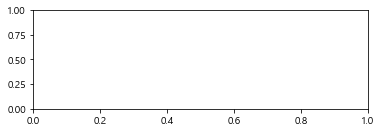

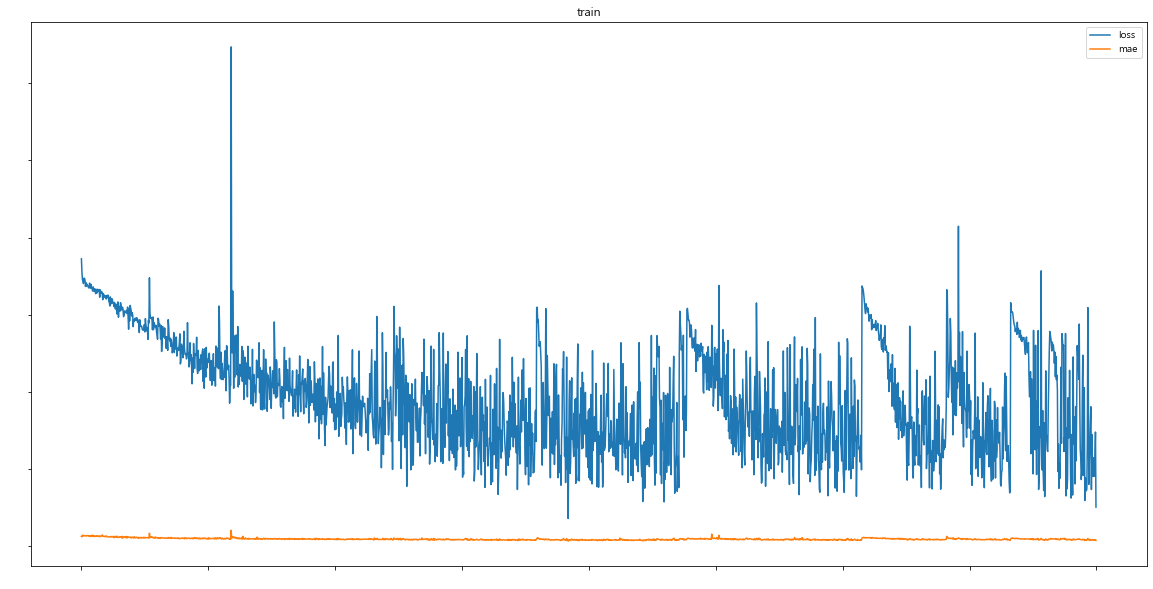

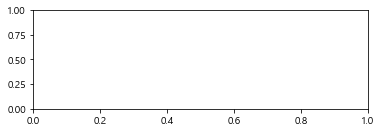

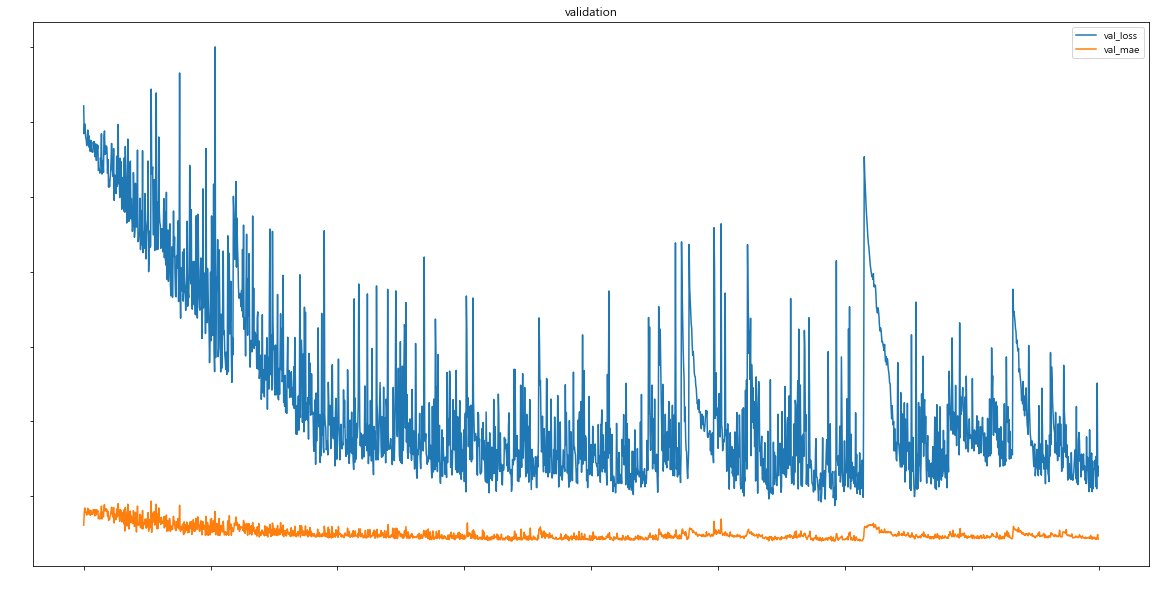

In [727]:
plt.subplot(2, 1, 1)
plt.figure(figsize=(20, 10))
plt.title("train")
plt.plot(history_mlp_여름.history['loss'], label='loss')
plt.plot(history_mlp_여름.history['mae'], label='mae')
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')
plt.legend()
plt.show()

plt.subplot(2, 1, 1)
plt.figure(figsize=(20, 10))
plt.title("validation")
plt.plot(history_mlp_여름.history['val_loss'], label='val_loss')
plt.plot(history_mlp_여름.history['val_mae'], label='val_mae')
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')
plt.legend()
plt.show()

# 가을

In [694]:
data_가을 = pd.read_excel("C:/Users/PC/Desktop/가을.xlsx")
data_가을

,id,관리기관,단지명,근로자수,근로손실일,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,재해율,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,17090775,한국산업단지공단 울산지역본부,울산미포국가산업단지,12992.0,373.0,True,5,5.456668e+09,157.4180,0.885160,...,0,0,0,0,0,0,0,0,0,0
1,12823536,한국산업단지공단 경남지역본부,창원국가산업단지,4771.0,201.5,True,4,4.101664e+09,172.7770,0.314399,...,0,0,0,0,2,0,0,0,0,0
2,3166196,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,379.0,56.5,True,1,4.426323e+08,149.3217,12.664908,...,0,0,0,0,0,0,0,0,0,0
3,16959388,한국산업단지공단 울산지역본부,울산미포국가산업단지,2940.0,387.0,True,1,2.780781e+09,52.9558,1.224490,...,0,0,0,0,0,0,0,0,0,0
4,13326267,한국산업단지공단 경남지역본부,창원국가산업단지,2039.0,353.5,True,4,8.497518e+09,223.4079,0.367827,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,3154772,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,13.0,56.0,False,9,3.742934e+06,404.1093,0.854701,...,0,0,0,0,0,0,0,0,0,0
1559,3154764,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,40.0,43.0,False,7,6.390193e+06,28.4231,0.357143,...,0,0,0,0,0,0,0,0,0,0
1560,11542822,한국산업단지공단 경북지역본부,구미국가산업단지,1.0,173.0,False,5,9.928310e+05,50.5371,20.000000,...,0,0,0,0,0,0,0,0,0,0
1561,11542790,한국산업단지공단 경북지역본부,구미국가산업단지,139.0,106.0,False,3,1.069881e+07,51.6222,0.239808,...,0,0,0,0,0,0,0,0,0,0


In [695]:
data_가을.중대재해유무 = data_가을.중대재해유무.astype("int")
data_가을.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 89 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1563 non-null   int64  
 1   관리기관                       1563 non-null   object 
 2   단지명                        1563 non-null   object 
 3   근로자수                       1563 non-null   float64
 4   근로손실일                      1563 non-null   float64
 5   중대재해유무                     1563 non-null   int32  
 6   그리드 내 총 기업 수               1563 non-null   int64  
 7   매출액                        1563 non-null   float64
 8   부채비율                       1563 non-null   float64
 9   재해율                        1556 non-null   float64
 10  중업종_기계기구·금속·비금속광물제품제조업     1563 non-null   int64  
 11  중업종_선박건조및수리업               1563 non-null   int64  
 12  중업종_화학및고무제품제조업             1563 non-null   int64  
 13  중업종_전기기계기구·정밀기구·전자제품제조업    1563 non-null   int64

In [696]:
data_가을.drop(columns = data_가을.iloc[:, 10:71], inplace = True)
data_가을.head()

,id,관리기관,단지명,근로자수,근로손실일,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,재해율,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,17090775,한국산업단지공단 울산지역본부,울산미포국가산업단지,12992.0,373.0,1,5,5.456668e+09,157.4180,0.885160,...,0,0,0,0,0,0,0,0,0,0
1,12823536,한국산업단지공단 경남지역본부,창원국가산업단지,4771.0,201.5,1,4,4.101664e+09,172.7770,0.314399,...,0,0,0,0,2,0,0,0,0,0
2,3166196,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,379.0,56.5,1,1,4.426323e+08,149.3217,12.664908,...,0,0,0,0,0,0,0,0,0,0
3,16959388,한국산업단지공단 울산지역본부,울산미포국가산업단지,2940.0,387.0,1,1,2.780781e+09,52.9558,1.224490,...,0,0,0,0,0,0,0,0,0,0
4,13326267,한국산업단지공단 경남지역본부,창원국가산업단지,2039.0,353.5,1,4,8.497518e+09,223.4079,0.367827,...,0,0,0,0,2,0,0,0,0,0


In [697]:
data_가을.dropna(inplace = True)

# 재해율

In [698]:
X_가을 = data_가을.drop(columns = ["id", "관리기관", "단지명", "근로손실일", "재해율"])
y_가을 = data_가을["재해율"]

In [699]:
scaler = MinMaxScaler()

X_가을 = pd.DataFrame(scaler.fit_transform(X_가을), columns = X_가을.columns)
X_가을.head()

,근로자수,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,중업종분류_기계기구 금속 비금속광물제품제조업,중업종분류_전기기계기구 정밀기구 전자제품제조업,중업종분류_전문 보건 교욱 여가관련서비스,중업종분류_출판 인쇄 제본또는인쇄물가공업,중업종분류_부동산업및임대업,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,1.000000,1.0,0.005222,0.181996,0.315350,0.006623,0.003704,0.017241,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
1,0.367202,1.0,0.003916,0.136802,0.316078,0.003311,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0
2,0.029134,1.0,0.000000,0.014760,0.314967,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
3,0.226263,1.0,0.000000,0.092746,0.310400,0.003311,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
4,0.156910,1.0,0.003916,0.283418,0.318477,0.003311,0.000000,0.008621,0.0,0.0,...,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0


In [700]:
X_train_가을, X_test_가을, y_train_가을, y_test_가을 = train_test_split(X_가을, y_가을, test_size = 0.25, random_state = 42)

# XGBoost

In [701]:
xgb_가을 = XGBRegressor(early_sropping_rounds = 50, random_state = 42)

param_xgb_가을 = {
    'max_leaves' : [50, 100, 200, 255],
    'n_estimators' : [100,200,300,400,500],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'max_depth' : [3,5,7,10,15],
    'gamma' : [0,1,2,3],
    'colsample_bytree' : [0.7,0.8,0.9]
}

xgb_grid_가을 = GridSearchCV(xgb_가을, param_grid = param_xgb_가을, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
xgb_grid_가을.fit(X_train_가을, y_train_가을)

print("best_score :", -xgb_grid_가을.best_score_)
print("best_params :", xgb_grid_가을.best_params_)

Fitting 5 folds for each of 4800 candidates, totalling 24000 fits
[14:10:13] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "early_sropping_rounds" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


best_score : 2.167097021779549
best_params : {'colsample_bytree': 0.9, 'gamma': 3, 'learning_rate': 0.1, 'max_depth': 3, 'max_leaves': 50, 'n_estimators': 200}


In [702]:
model_xgb_가을 = xgb_grid_가을.best_estimator_
model_xgb_pred_가을 = model_xgb_가을.predict(X_test_가을)

xgb_rmse_가을 = mean_squared_error(model_xgb_pred_가을, y_test_가을, squared = False)

print("rmse :", xgb_rmse_가을)
print("r2_score :", r2_score(y_test_가을, model_xgb_pred_가을))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_가을, model_xgb_pred_가을)) * (len(y_가을)-1)/(len(y_가을)-X_가을.shape[1]-1))

rmse : 1.6931729571526866
r2_score : 0.841041420482755
adjusted r2_score : 0.838654966612718


In [703]:
joblib.dump(model_xgb_가을, 'model_xgb_가을.pkl')
#model_xgb_가을 = joblib.load('model_xgb_가을.pkl')

['model_xgb_가을.pkl']

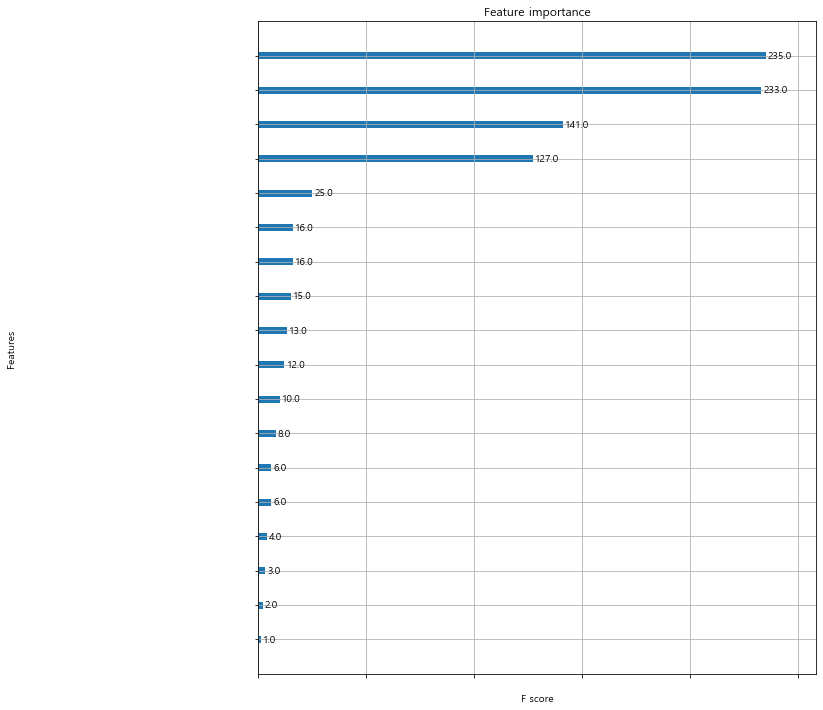

In [704]:
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(model_xgb_가을, ax=ax)
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

# GBM

In [763]:
gbm_가을 = GradientBoostingRegressor()

param_gbm_가을 = {
    'n_estimators' : [100,200,300,400],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'min_samples_leaf': [4, 8, 12, 18],
    'min_samples_split': [16, 20, 24],
    'max_depth' : [-1,3,7,10],
    'random_state' : [42]
}

gbm_grid_가을 = GridSearchCV(gbm_가을, param_grid = param_gbm_가을, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
gbm_grid_가을.fit(X_train_가을, y_train_가을)

print("best_score :", -gbm_grid_가을.best_score_)
print("best_params :", gbm_grid_가을.best_params_)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits



960 fits failed out of a total of 3840.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
960 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 596, in fit
    monitor,
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 672, in _fit_stages
    X_csr,
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 246, in _fit_stage
    tree.fit(X, residual, sample_weight=sample_weight, check_input=False)
  File "C:\Anaconda3\lib\site-packages\sklearn\tree\_classes.py"

best_score : 2.056158527021203
best_params : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 16, 'n_estimators': 200, 'random_state': 42}


In [766]:
model_gbm_가을 = gbm_grid_가을.best_estimator_
model_gbm_pred_가을 = model_gbm_가을.predict(X_test_가을)

gbm_rmse_가을 = mean_squared_error(model_gbm_pred_가을, y_test_가을, squared = False)

print("rmse :", gbm_rmse_가을)
print("r2_score :", r2_score(y_test_가을, model_gbm_pred_가을))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_가을, model_gbm_pred_가을)) * (len(y_가을)-1)/(len(y_가을)-X_가을.shape[1]-1))

rmse : 1.473315134689155
r2_score : 0.8796426473131198
adjusted r2_score : 0.8778357157780035


In [767]:
joblib.dump(model_gbm_가을, 'model_gbm_가을.pkl')
#model_gbm_가을 = joblib.load('model_gbm_가을.pkl')

['model_gbm_가을.pkl']

# LightGBM

In [705]:
lgb_가을 = LGBMRegressor(early_sropping_rounds = 50, random_state = 42)

param_lgb_가을 = {
    'num_leaves': [20, 40, 60, 80, 100],
    'n_estimators' : [50,100,200,300,400],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'max_depth' : [3,5,7,10,15],
    'gamma' : [0.1,0,1],
    'colsample_bytree' : [0.7,0.8,0.9]
}

lgb_grid_가을 = GridSearchCV(lgb_가을, param_grid = param_lgb_가을, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
lgb_grid_가을.fit(X_train_가을, y_train_가을)

print("best_score :", -lgb_grid_가을.best_score_)
print("best_params :", lgb_grid_가을.best_params_)

Fitting 5 folds for each of 4500 candidates, totalling 22500 fits
[LightGBM] [Warning] Unknown parameter: early_sropping_rounds
[LightGBM] [Warning] Unknown parameter: gamma
best_score : 3.2320661297522677
best_params : {'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.15, 'max_depth': 5, 'n_estimators': 400, 'num_leaves': 20}


In [706]:
model_lgb_가을 = lgb_grid_가을.best_estimator_
model_lgb_pred_가을 = model_lgb_가을.predict(X_test_가을)

lgb_rmse_가을 = mean_squared_error(model_lgb_pred_가을, y_test_가을, squared = False)

print("rmse :", lgb_rmse_가을)
print("r2_score :", r2_score(y_test_가을, model_lgb_pred_가을))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_가을, model_lgb_pred_가을)) * (len(y_가을)-1)/(len(y_가을)-X_가을.shape[1]-1))

rmse : 1.978153121421067
r2_score : 0.7830292762568486
adjusted r2_score : 0.7797718828847255


In [707]:
joblib.dump(model_lgb_가을, 'model_lgb_가을.pkl')
#model_lgb_가을 = joblib.load('model_lgb_가을.pkl')

['model_lgb_가을.pkl']

# RandomForest

In [708]:
rf_가을 = RandomForestRegressor(random_state = 42)

param_rf_가을 = {
    'max_samples' : [0.2, 0.4, 0.7, 0.8, 1.0],
    'max_features' : [0.2, 0.4, 0.7, 0.8, 1.0],
    'n_estimators' : [10,50,100,150,200],
    'max_depth' : [3,5,7,10,15]
}

rf_grid_가을 = GridSearchCV(rf_가을, param_grid = param_rf_가을, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
rf_grid_가을.fit(X_train_가을, y_train_가을)

print("best_score :", -rf_grid_가을.best_score_)
print("best_params :", rf_grid_가을.best_params_)

Fitting 5 folds for each of 625 candidates, totalling 3125 fits
best_score : 2.7642288109503426
best_params : {'max_depth': 7, 'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 200}


In [709]:
model_rf_가을 = rf_grid_가을.best_estimator_
model_rf_pred_가을 = model_rf_가을.predict(X_test_가을)

rf_rmse_가을 = mean_squared_error(model_rf_pred_가을, y_test_가을, squared = False)

print("rmse :", rf_rmse_가을)
print("r2_score :", r2_score(y_test_가을, model_rf_pred_가을))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_가을, model_rf_pred_가을)) * (len(y_가을)-1)/(len(y_가을)-X_가을.shape[1]-1))

rmse : 1.7721530798000324
r2_score : 0.8258659126989057
adjusted r2_score : 0.8232516280984324


In [710]:
joblib.dump(model_rf_가을, 'model_rf_가을.pkl')
#model_rf_가을 = joblib.load('model_rf_가을.pkl')

['model_rf_가을.pkl']

# MLP

In [729]:
epochs = 2000
batch_size = 32

model_mlp_가을 = Sequential()

model_mlp_가을.add(Dense(32, activation = "relu", input_dim = 23))
model_mlp_가을.add(Dropout(0.2))
model_mlp_가을.add(Dense(16, activation = "relu"))
model_mlp_가을.add(Dropout(0.2))
model_mlp_가을.add(Dense(1))

model_mlp_가을.summary()

Model: "sequential_16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_66 (Dense)             (None, 32)                768       
_________________________________________________________________
dropout_50 (Dropout)         (None, 32)                0         
_________________________________________________________________
dense_67 (Dense)             (None, 16)                528       
_________________________________________________________________
dropout_51 (Dropout)         (None, 16)                0         
_________________________________________________________________
dense_68 (Dense)             (None, 1)                 17        
Total params: 1,313
Trainable params: 1,313
Non-trainable params: 0
_________________________________________________________________


In [731]:
model_mlp_가을.compile(optimizer = "adam", loss = "mse", metrics = ["mae"])

#checkpoint_cb = ModelCheckPoint('filename.h5', save_best_only=True)
early_stopping = EarlyStopping(monitor = "val_mae", min_delta = 0.01, mode = "auto", patience = 3, restore_best_weights = True)

history_mlp_가을 = model_mlp_가을.fit(X_train_가을, y_train_가을, epochs = epochs, batch_size = batch_size, validation_split = 0.2, verbose = 1)

Train on 933 samples, validate on 234 samples
Epoch 1/2000
933/933 [==============================] - ETA: 9s - loss: 8.5551 - mae: 1.893 - 0s 502us/sample - loss: 72.4083 - mae: 2.7357 - val_loss: 66.7647 - val_mae: 2.3569
Epoch 2/2000
933/933 [==============================] - ETA: 0s - loss: 18.4713 - mae: 2.15 - 0s 50us/sample - loss: 70.8179 - mae: 2.5488 - val_loss: 65.2619 - val_mae: 2.2167
Epoch 3/2000
933/933 [==============================] - ETA: 0s - loss: 139.8089 - mae: 3.240 - 0s 44us/sample - loss: 69.0048 - mae: 2.4535 - val_loss: 63.7042 - val_mae: 2.1959
Epoch 4/2000
933/933 [==============================] - ETA: 0s - loss: 76.4416 - mae: 2.46 - 0s 42us/sample - loss: 67.1680 - mae: 2.5113 - val_loss: 62.3429 - val_mae: 2.3353
Epoch 5/2000
933/933 [==============================] - ETA: 0s - loss: 4.3697 - mae: 1.379 - 0s 53us/sample - loss: 66.1372 - mae: 2.6162 - val_loss: 61.6932 - val_mae: 2.4600
Epoch 6/2000
933/933 [==============================] - ETA: 0s - 

Epoch 47/2000
933/933 [==============================] - ETA: 0s - loss: 6.6221 - mae: 2.081 - 0s 43us/sample - loss: 60.6058 - mae: 2.7478 - val_loss: 58.8131 - val_mae: 2.5737
Epoch 48/2000
933/933 [==============================] - ETA: 0s - loss: 10.6508 - mae: 1.94 - 0s 46us/sample - loss: 61.6361 - mae: 2.7535 - val_loss: 58.7819 - val_mae: 2.5732
Epoch 49/2000
933/933 [==============================] - ETA: 0s - loss: 21.4379 - mae: 2.67 - 0s 39us/sample - loss: 61.4838 - mae: 2.7645 - val_loss: 58.7407 - val_mae: 2.5748
Epoch 50/2000
933/933 [==============================] - ETA: 0s - loss: 4.9644 - mae: 1.693 - 0s 41us/sample - loss: 61.1687 - mae: 2.6711 - val_loss: 58.7456 - val_mae: 2.6304
Epoch 51/2000
933/933 [==============================] - ETA: 0s - loss: 4.3457 - mae: 1.693 - 0s 39us/sample - loss: 59.9808 - mae: 2.7692 - val_loss: 58.7339 - val_mae: 2.6531
Epoch 52/2000
933/933 [==============================] - ETA: 0s - loss: 292.4570 - mae: 5.114 - 0s 42us/sampl

Epoch 93/2000
933/933 [==============================] - ETA: 0s - loss: 32.5903 - mae: 2.76 - 0s 38us/sample - loss: 58.1255 - mae: 2.6400 - val_loss: 57.6250 - val_mae: 2.5154
Epoch 94/2000
933/933 [==============================] - ETA: 0s - loss: 13.7278 - mae: 2.11 - 0s 41us/sample - loss: 58.4535 - mae: 2.5770 - val_loss: 57.6009 - val_mae: 2.4780
Epoch 95/2000
933/933 [==============================] - ETA: 0s - loss: 8.1952 - mae: 1.981 - 0s 39us/sample - loss: 57.4443 - mae: 2.6026 - val_loss: 57.5953 - val_mae: 2.5490
Epoch 96/2000
933/933 [==============================] - ETA: 0s - loss: 305.6908 - mae: 5.669 - 0s 38us/sample - loss: 58.8429 - mae: 2.7880 - val_loss: 57.5374 - val_mae: 2.3949
Epoch 97/2000
933/933 [==============================] - ETA: 0s - loss: 3.8729 - mae: 1.350 - 0s 39us/sample - loss: 57.9829 - mae: 2.4562 - val_loss: 57.5581 - val_mae: 2.3770
Epoch 98/2000
933/933 [==============================] - ETA: 0s - loss: 277.0247 - mae: 4.963 - 0s 41us/sam

Epoch 139/2000
933/933 [==============================] - ETA: 0s - loss: 7.9455 - mae: 1.844 - 0s 38us/sample - loss: 54.7071 - mae: 2.4736 - val_loss: 56.5219 - val_mae: 2.5172
Epoch 140/2000
933/933 [==============================] - ETA: 0s - loss: 351.5252 - mae: 6.094 - 0s 41us/sample - loss: 54.4642 - mae: 2.4810 - val_loss: 56.4566 - val_mae: 2.3849
Epoch 141/2000
933/933 [==============================] - ETA: 0s - loss: 65.3403 - mae: 2.72 - 0s 38us/sample - loss: 54.6833 - mae: 2.5029 - val_loss: 56.5213 - val_mae: 2.5647
Epoch 142/2000
933/933 [==============================] - ETA: 0s - loss: 6.8817 - mae: 1.820 - 0s 39us/sample - loss: 54.7983 - mae: 2.4947 - val_loss: 56.3685 - val_mae: 2.3998
Epoch 143/2000
933/933 [==============================] - ETA: 0s - loss: 17.3993 - mae: 2.43 - 0s 41us/sample - loss: 55.7919 - mae: 2.4508 - val_loss: 56.3743 - val_mae: 2.4184
Epoch 144/2000
933/933 [==============================] - ETA: 0s - loss: 5.2215 - mae: 1.387 - 0s 40us

Epoch 185/2000
933/933 [==============================] - ETA: 0s - loss: 8.1993 - mae: 2.144 - 0s 38us/sample - loss: 49.8933 - mae: 2.4831 - val_loss: 55.4850 - val_mae: 2.2926
Epoch 186/2000
933/933 [==============================] - ETA: 0s - loss: 29.0429 - mae: 2.76 - 0s 41us/sample - loss: 51.6749 - mae: 2.3693 - val_loss: 55.5505 - val_mae: 2.2617
Epoch 187/2000
933/933 [==============================] - ETA: 0s - loss: 10.6888 - mae: 1.90 - 0s 37us/sample - loss: 51.1253 - mae: 2.5420 - val_loss: 55.4846 - val_mae: 2.4028
Epoch 188/2000
933/933 [==============================] - ETA: 0s - loss: 14.1361 - mae: 2.15 - 0s 38us/sample - loss: 51.1484 - mae: 2.4259 - val_loss: 55.2209 - val_mae: 2.3710
Epoch 189/2000
933/933 [==============================] - ETA: 0s - loss: 22.8814 - mae: 2.43 - 0s 38us/sample - loss: 50.4552 - mae: 2.4513 - val_loss: 55.2603 - val_mae: 2.3992
Epoch 190/2000
933/933 [==============================] - ETA: 0s - loss: 17.8032 - mae: 2.37 - 0s 41us/s

Epoch 231/2000
933/933 [==============================] - ETA: 0s - loss: 2.7051 - mae: 1.130 - 0s 62us/sample - loss: 49.7749 - mae: 2.3555 - val_loss: 55.0536 - val_mae: 2.2591
Epoch 232/2000
933/933 [==============================] - ETA: 0s - loss: 6.0982 - mae: 1.821 - 0s 39us/sample - loss: 47.0431 - mae: 2.3863 - val_loss: 54.8296 - val_mae: 2.2550
Epoch 233/2000
933/933 [==============================] - ETA: 0s - loss: 272.3625 - mae: 5.375 - 0s 38us/sample - loss: 47.9903 - mae: 2.3978 - val_loss: 55.1183 - val_mae: 2.1964
Epoch 234/2000
933/933 [==============================] - ETA: 0s - loss: 17.8075 - mae: 1.86 - 0s 38us/sample - loss: 48.2389 - mae: 2.3044 - val_loss: 54.9900 - val_mae: 2.2817
Epoch 235/2000
933/933 [==============================] - ETA: 0s - loss: 225.4271 - mae: 4.266 - 0s 42us/sample - loss: 48.4646 - mae: 2.4286 - val_loss: 55.1958 - val_mae: 2.2006
Epoch 236/2000
933/933 [==============================] - ETA: 0s - loss: 11.5008 - mae: 2.14 - 0s 38

Epoch 277/2000
933/933 [==============================] - ETA: 0s - loss: 2.7589 - mae: 1.152 - 0s 40us/sample - loss: 45.0103 - mae: 2.2039 - val_loss: 53.6505 - val_mae: 2.1550
Epoch 278/2000
933/933 [==============================] - ETA: 0s - loss: 14.4438 - mae: 1.78 - 0s 41us/sample - loss: 44.3727 - mae: 2.3479 - val_loss: 53.5347 - val_mae: 2.1457
Epoch 279/2000
933/933 [==============================] - ETA: 0s - loss: 8.4897 - mae: 1.842 - 0s 39us/sample - loss: 45.1904 - mae: 2.1899 - val_loss: 53.9928 - val_mae: 2.0697
Epoch 280/2000
933/933 [==============================] - ETA: 0s - loss: 7.9091 - mae: 1.750 - 0s 41us/sample - loss: 45.5430 - mae: 2.3104 - val_loss: 53.6927 - val_mae: 2.1765
Epoch 281/2000
933/933 [==============================] - ETA: 0s - loss: 10.8756 - mae: 1.74 - 0s 39us/sample - loss: 46.8689 - mae: 2.2076 - val_loss: 54.1418 - val_mae: 2.1275
Epoch 282/2000
933/933 [==============================] - ETA: 0s - loss: 15.6118 - mae: 2.20 - 0s 37us/s

Epoch 323/2000
933/933 [==============================] - ETA: 0s - loss: 10.9445 - mae: 1.97 - 0s 41us/sample - loss: 41.1164 - mae: 2.2190 - val_loss: 53.3833 - val_mae: 2.1669
Epoch 324/2000
933/933 [==============================] - ETA: 0s - loss: 18.0835 - mae: 2.42 - 0s 40us/sample - loss: 40.4162 - mae: 2.2209 - val_loss: 53.4273 - val_mae: 2.1059
Epoch 325/2000
933/933 [==============================] - ETA: 0s - loss: 37.0453 - mae: 2.49 - 0s 41us/sample - loss: 43.6486 - mae: 2.1592 - val_loss: 53.1900 - val_mae: 2.2412
Epoch 326/2000
933/933 [==============================] - ETA: 0s - loss: 451.9045 - mae: 8.616 - 0s 39us/sample - loss: 46.3041 - mae: 2.7105 - val_loss: 54.5573 - val_mae: 2.0292
Epoch 327/2000
933/933 [==============================] - ETA: 0s - loss: 207.3555 - mae: 3.994 - 0s 40us/sample - loss: 44.4222 - mae: 2.1502 - val_loss: 54.1832 - val_mae: 2.0270
Epoch 328/2000
933/933 [==============================] - ETA: 0s - loss: 49.5144 - mae: 2.80 - 0s 43

Epoch 369/2000
933/933 [==============================] - ETA: 0s - loss: 6.3253 - mae: 1.470 - 0s 38us/sample - loss: 39.5829 - mae: 2.1143 - val_loss: 52.7784 - val_mae: 2.0538
Epoch 370/2000
933/933 [==============================] - ETA: 0s - loss: 25.3878 - mae: 2.68 - 0s 41us/sample - loss: 37.6994 - mae: 2.1330 - val_loss: 52.8238 - val_mae: 2.0638
Epoch 371/2000
933/933 [==============================] - ETA: 0s - loss: 12.5171 - mae: 1.87 - 0s 39us/sample - loss: 36.1975 - mae: 2.1753 - val_loss: 53.0942 - val_mae: 2.0434
Epoch 372/2000
933/933 [==============================] - ETA: 0s - loss: 150.0618 - mae: 4.345 - 0s 39us/sample - loss: 34.7990 - mae: 2.1275 - val_loss: 52.7561 - val_mae: 2.0369
Epoch 373/2000
933/933 [==============================] - ETA: 0s - loss: 32.3069 - mae: 3.31 - 0s 41us/sample - loss: 36.8090 - mae: 2.1216 - val_loss: 52.9245 - val_mae: 2.0901
Epoch 374/2000
933/933 [==============================] - ETA: 0s - loss: 181.0337 - mae: 3.914 - 0s 39

Epoch 415/2000
933/933 [==============================] - ETA: 0s - loss: 31.3254 - mae: 2.59 - 0s 41us/sample - loss: 38.5762 - mae: 2.1513 - val_loss: 52.2808 - val_mae: 1.9743
Epoch 416/2000
933/933 [==============================] - ETA: 0s - loss: 6.1573 - mae: 1.354 - 0s 40us/sample - loss: 32.5042 - mae: 2.0238 - val_loss: 52.5759 - val_mae: 2.0076
Epoch 417/2000
933/933 [==============================] - ETA: 0s - loss: 4.6093 - mae: 1.269 - 0s 42us/sample - loss: 36.4742 - mae: 2.0280 - val_loss: 52.2902 - val_mae: 2.0514
Epoch 418/2000
933/933 [==============================] - ETA: 0s - loss: 7.1112 - mae: 1.600 - 0s 39us/sample - loss: 38.2497 - mae: 2.1341 - val_loss: 51.9779 - val_mae: 2.1205
Epoch 419/2000
933/933 [==============================] - ETA: 0s - loss: 181.3413 - mae: 3.828 - 0s 39us/sample - loss: 38.7551 - mae: 2.1757 - val_loss: 52.7048 - val_mae: 1.9323
Epoch 420/2000
933/933 [==============================] - ETA: 0s - loss: 16.8270 - mae: 2.02 - 0s 44us

Epoch 461/2000
933/933 [==============================] - ETA: 0s - loss: 4.4093 - mae: 1.253 - 0s 38us/sample - loss: 31.1269 - mae: 2.0114 - val_loss: 52.5405 - val_mae: 2.0384
Epoch 462/2000
933/933 [==============================] - ETA: 0s - loss: 19.6276 - mae: 2.23 - 0s 40us/sample - loss: 33.2627 - mae: 2.0430 - val_loss: 52.5912 - val_mae: 2.1402
Epoch 463/2000
933/933 [==============================] - ETA: 0s - loss: 68.1928 - mae: 2.60 - 0s 41us/sample - loss: 32.9911 - mae: 2.1384 - val_loss: 52.8850 - val_mae: 1.9482
Epoch 464/2000
933/933 [==============================] - ETA: 0s - loss: 17.2650 - mae: 1.88 - 0s 37us/sample - loss: 29.7366 - mae: 1.9700 - val_loss: 52.6365 - val_mae: 1.9948
Epoch 465/2000
933/933 [==============================] - ETA: 0s - loss: 6.2269 - mae: 1.351 - 0s 40us/sample - loss: 31.3503 - mae: 1.9512 - val_loss: 52.5931 - val_mae: 2.0167
Epoch 466/2000
933/933 [==============================] - ETA: 0s - loss: 7.9724 - mae: 1.652 - 0s 41us/s

Epoch 507/2000
933/933 [==============================] - ETA: 0s - loss: 1.5795 - mae: 0.908 - 0s 41us/sample - loss: 31.8396 - mae: 1.7955 - val_loss: 53.0247 - val_mae: 2.0069
Epoch 508/2000
933/933 [==============================] - ETA: 0s - loss: 2.8140 - mae: 1.093 - 0s 39us/sample - loss: 30.9254 - mae: 2.0146 - val_loss: 52.8064 - val_mae: 1.9601
Epoch 509/2000
933/933 [==============================] - ETA: 0s - loss: 17.1834 - mae: 2.15 - 0s 38us/sample - loss: 32.7112 - mae: 2.0902 - val_loss: 54.1792 - val_mae: 1.8991
Epoch 510/2000
933/933 [==============================] - ETA: 0s - loss: 8.0743 - mae: 1.588 - 0s 41us/sample - loss: 29.4135 - mae: 1.9385 - val_loss: 52.5184 - val_mae: 2.0031
Epoch 511/2000
933/933 [==============================] - ETA: 0s - loss: 3.4247 - mae: 1.300 - 0s 38us/sample - loss: 31.8067 - mae: 1.8995 - val_loss: 53.2092 - val_mae: 1.9161
Epoch 512/2000
933/933 [==============================] - ETA: 0s - loss: 5.8331 - mae: 1.451 - 0s 38us/s

Epoch 553/2000
933/933 [==============================] - ETA: 0s - loss: 26.7515 - mae: 2.35 - 0s 39us/sample - loss: 26.0173 - mae: 1.8273 - val_loss: 53.3554 - val_mae: 1.9319
Epoch 554/2000
933/933 [==============================] - ETA: 0s - loss: 10.7747 - mae: 1.26 - 0s 38us/sample - loss: 26.9676 - mae: 1.8362 - val_loss: 53.7091 - val_mae: 1.9592
Epoch 555/2000
933/933 [==============================] - ETA: 0s - loss: 6.4855 - mae: 1.574 - 0s 41us/sample - loss: 33.4024 - mae: 2.2172 - val_loss: 55.2207 - val_mae: 1.9323
Epoch 556/2000
933/933 [==============================] - ETA: 0s - loss: 12.8005 - mae: 1.53 - 0s 38us/sample - loss: 30.0928 - mae: 1.8275 - val_loss: 54.7368 - val_mae: 2.0042
Epoch 557/2000
933/933 [==============================] - ETA: 0s - loss: 131.5365 - mae: 3.884 - 0s 39us/sample - loss: 27.1054 - mae: 1.8189 - val_loss: 55.0768 - val_mae: 1.9302
Epoch 558/2000
933/933 [==============================] - ETA: 0s - loss: 2.2007 - mae: 1.016 - 0s 41us

Epoch 599/2000
933/933 [==============================] - ETA: 0s - loss: 3.4173 - mae: 1.182 - 0s 41us/sample - loss: 29.6097 - mae: 1.8200 - val_loss: 54.4101 - val_mae: 1.9372
Epoch 600/2000
933/933 [==============================] - ETA: 0s - loss: 87.5789 - mae: 3.37 - 0s 40us/sample - loss: 24.8984 - mae: 1.8819 - val_loss: 54.6976 - val_mae: 1.9686
Epoch 601/2000
933/933 [==============================] - ETA: 0s - loss: 55.2666 - mae: 2.63 - 0s 39us/sample - loss: 26.9027 - mae: 1.8450 - val_loss: 53.7902 - val_mae: 1.9655
Epoch 602/2000
933/933 [==============================] - ETA: 0s - loss: 13.0201 - mae: 1.76 - 0s 40us/sample - loss: 24.1356 - mae: 1.8846 - val_loss: 55.0125 - val_mae: 1.9260
Epoch 603/2000
933/933 [==============================] - ETA: 0s - loss: 11.5670 - mae: 1.47 - 0s 39us/sample - loss: 27.5758 - mae: 1.9129 - val_loss: 54.5180 - val_mae: 1.9315
Epoch 604/2000
933/933 [==============================] - ETA: 0s - loss: 5.4658 - mae: 1.138 - 0s 38us/s

Epoch 645/2000
933/933 [==============================] - ETA: 0s - loss: 12.0319 - mae: 1.47 - 0s 41us/sample - loss: 25.7917 - mae: 1.8870 - val_loss: 55.5318 - val_mae: 1.9474
Epoch 646/2000
933/933 [==============================] - ETA: 0s - loss: 25.1324 - mae: 1.97 - 0s 38us/sample - loss: 21.5904 - mae: 1.7780 - val_loss: 55.5153 - val_mae: 1.9506
Epoch 647/2000
933/933 [==============================] - ETA: 0s - loss: 22.8364 - mae: 2.25 - 0s 39us/sample - loss: 23.7817 - mae: 1.7616 - val_loss: 54.8482 - val_mae: 1.9642
Epoch 648/2000
933/933 [==============================] - ETA: 0s - loss: 28.8667 - mae: 2.44 - 0s 40us/sample - loss: 25.7335 - mae: 1.8323 - val_loss: 55.3107 - val_mae: 1.9426
Epoch 649/2000
933/933 [==============================] - ETA: 0s - loss: 80.6571 - mae: 2.71 - 0s 39us/sample - loss: 22.9131 - mae: 1.7393 - val_loss: 55.3687 - val_mae: 1.9433
Epoch 650/2000
933/933 [==============================] - ETA: 0s - loss: 19.7688 - mae: 1.95 - 0s 39us/s

Epoch 691/2000
933/933 [==============================] - ETA: 0s - loss: 8.4351 - mae: 1.445 - 0s 38us/sample - loss: 22.1377 - mae: 1.8110 - val_loss: 55.3217 - val_mae: 2.0289
Epoch 692/2000
933/933 [==============================] - ETA: 0s - loss: 8.4593 - mae: 1.437 - 0s 41us/sample - loss: 20.7228 - mae: 1.6963 - val_loss: 55.3468 - val_mae: 2.0428
Epoch 693/2000
933/933 [==============================] - ETA: 0s - loss: 4.5657 - mae: 1.303 - 0s 37us/sample - loss: 26.0194 - mae: 1.8600 - val_loss: 55.6788 - val_mae: 1.9778
Epoch 694/2000
933/933 [==============================] - ETA: 0s - loss: 44.2888 - mae: 2.54 - 0s 39us/sample - loss: 25.9571 - mae: 1.7632 - val_loss: 55.6196 - val_mae: 1.9591
Epoch 695/2000
933/933 [==============================] - ETA: 0s - loss: 10.9214 - mae: 1.79 - 0s 37us/sample - loss: 18.7669 - mae: 1.7531 - val_loss: 54.6032 - val_mae: 2.0253
Epoch 696/2000
933/933 [==============================] - ETA: 0s - loss: 23.5987 - mae: 2.60 - 0s 41us/s

Epoch 737/2000
933/933 [==============================] - ETA: 0s - loss: 34.9521 - mae: 2.46 - 0s 42us/sample - loss: 24.7086 - mae: 1.7616 - val_loss: 53.7215 - val_mae: 2.0391
Epoch 738/2000
933/933 [==============================] - ETA: 0s - loss: 16.9142 - mae: 1.58 - 0s 42us/sample - loss: 17.3982 - mae: 1.7646 - val_loss: 54.9774 - val_mae: 1.9731
Epoch 739/2000
933/933 [==============================] - ETA: 0s - loss: 3.7513 - mae: 1.441 - 0s 40us/sample - loss: 17.7909 - mae: 1.7298 - val_loss: 54.5604 - val_mae: 1.9536
Epoch 740/2000
933/933 [==============================] - ETA: 0s - loss: 4.4358 - mae: 1.276 - 0s 42us/sample - loss: 18.8446 - mae: 1.6298 - val_loss: 53.6735 - val_mae: 1.9656
Epoch 741/2000
933/933 [==============================] - ETA: 0s - loss: 3.4530 - mae: 1.266 - 0s 39us/sample - loss: 25.0685 - mae: 1.7807 - val_loss: 54.5191 - val_mae: 1.9052
Epoch 742/2000
933/933 [==============================] - ETA: 0s - loss: 130.9850 - mae: 3.022 - 0s 39us

Epoch 783/2000
933/933 [==============================] - ETA: 0s - loss: 1.4764 - mae: 0.941 - 0s 40us/sample - loss: 26.3152 - mae: 1.7447 - val_loss: 51.8605 - val_mae: 2.0259
Epoch 784/2000
933/933 [==============================] - ETA: 0s - loss: 2.2533 - mae: 1.014 - 0s 40us/sample - loss: 23.3871 - mae: 1.8877 - val_loss: 54.5204 - val_mae: 1.9322
Epoch 785/2000
933/933 [==============================] - ETA: 0s - loss: 1.6771 - mae: 0.978 - 0s 43us/sample - loss: 17.7019 - mae: 1.6532 - val_loss: 54.1584 - val_mae: 1.9905
Epoch 786/2000
933/933 [==============================] - ETA: 0s - loss: 15.0407 - mae: 2.06 - 0s 38us/sample - loss: 16.7731 - mae: 1.6628 - val_loss: 53.7249 - val_mae: 1.9688
Epoch 787/2000
933/933 [==============================] - ETA: 0s - loss: 16.8083 - mae: 1.88 - 0s 39us/sample - loss: 20.1006 - mae: 1.7266 - val_loss: 54.3922 - val_mae: 1.9228
Epoch 788/2000
933/933 [==============================] - ETA: 0s - loss: 63.6102 - mae: 2.66 - 0s 40us/s

Epoch 829/2000
933/933 [==============================] - ETA: 0s - loss: 12.9233 - mae: 1.76 - 0s 44us/sample - loss: 18.9139 - mae: 1.6489 - val_loss: 49.1232 - val_mae: 1.9349
Epoch 830/2000
933/933 [==============================] - ETA: 0s - loss: 12.2127 - mae: 1.73 - 0s 42us/sample - loss: 18.3574 - mae: 1.6801 - val_loss: 49.6542 - val_mae: 1.8923
Epoch 831/2000
933/933 [==============================] - ETA: 0s - loss: 26.8915 - mae: 2.84 - 0s 45us/sample - loss: 17.3895 - mae: 1.6328 - val_loss: 50.2731 - val_mae: 1.9400
Epoch 832/2000
933/933 [==============================] - ETA: 0s - loss: 5.6093 - mae: 1.389 - 0s 42us/sample - loss: 14.5870 - mae: 1.6684 - val_loss: 51.3167 - val_mae: 1.8755
Epoch 833/2000
933/933 [==============================] - ETA: 0s - loss: 1.2837 - mae: 0.724 - 0s 43us/sample - loss: 20.0840 - mae: 1.6410 - val_loss: 51.0960 - val_mae: 1.9364
Epoch 834/2000
933/933 [==============================] - ETA: 0s - loss: 3.9698 - mae: 1.315 - 0s 42us/s

Epoch 875/2000
933/933 [==============================] - ETA: 0s - loss: 1.4278 - mae: 0.882 - 0s 41us/sample - loss: 15.9251 - mae: 1.6106 - val_loss: 46.3952 - val_mae: 1.9116
Epoch 876/2000
933/933 [==============================] - ETA: 0s - loss: 12.8062 - mae: 1.78 - 0s 39us/sample - loss: 18.7098 - mae: 1.6607 - val_loss: 48.2735 - val_mae: 1.8712
Epoch 877/2000
933/933 [==============================] - ETA: 0s - loss: 1.8751 - mae: 1.024 - 0s 41us/sample - loss: 14.2139 - mae: 1.5534 - val_loss: 46.2156 - val_mae: 1.8825
Epoch 878/2000
933/933 [==============================] - ETA: 0s - loss: 6.1275 - mae: 1.441 - 0s 44us/sample - loss: 11.4624 - mae: 1.5015 - val_loss: 46.5825 - val_mae: 1.8802
Epoch 879/2000
933/933 [==============================] - ETA: 0s - loss: 2.9332 - mae: 0.962 - 0s 41us/sample - loss: 23.8120 - mae: 1.7229 - val_loss: 46.6618 - val_mae: 1.9360
Epoch 880/2000
933/933 [==============================] - ETA: 0s - loss: 3.3266 - mae: 1.135 - 0s 42us/s

Epoch 921/2000
933/933 [==============================] - ETA: 0s - loss: 15.1462 - mae: 1.77 - 0s 40us/sample - loss: 13.8375 - mae: 1.5319 - val_loss: 42.2573 - val_mae: 1.8665
Epoch 922/2000
933/933 [==============================] - ETA: 0s - loss: 4.5063 - mae: 1.271 - 0s 42us/sample - loss: 16.9269 - mae: 1.5821 - val_loss: 41.9995 - val_mae: 1.8578
Epoch 923/2000
933/933 [==============================] - ETA: 0s - loss: 8.5507 - mae: 1.366 - 0s 39us/sample - loss: 12.4388 - mae: 1.5154 - val_loss: 41.4568 - val_mae: 1.8583
Epoch 924/2000
933/933 [==============================] - ETA: 0s - loss: 7.6514 - mae: 1.624 - 0s 39us/sample - loss: 13.8052 - mae: 1.5130 - val_loss: 41.7476 - val_mae: 1.8979
Epoch 925/2000
933/933 [==============================] - ETA: 0s - loss: 7.6087 - mae: 1.733 - 0s 42us/sample - loss: 16.2217 - mae: 1.6176 - val_loss: 42.8888 - val_mae: 1.8504
Epoch 926/2000
933/933 [==============================] - ETA: 0s - loss: 0.9056 - mae: 0.846 - 0s 40us/s

Epoch 967/2000
933/933 [==============================] - ETA: 0s - loss: 39.9056 - mae: 2.20 - 0s 63us/sample - loss: 18.5298 - mae: 1.5036 - val_loss: 37.6002 - val_mae: 1.8102
Epoch 968/2000
933/933 [==============================] - ETA: 0s - loss: 6.9879 - mae: 1.500 - 0s 40us/sample - loss: 13.6243 - mae: 1.5719 - val_loss: 37.1904 - val_mae: 1.8101
Epoch 969/2000
933/933 [==============================] - ETA: 0s - loss: 2.1161 - mae: 0.992 - 0s 40us/sample - loss: 14.9740 - mae: 1.6195 - val_loss: 39.2194 - val_mae: 1.7780
Epoch 970/2000
933/933 [==============================] - ETA: 0s - loss: 1.9336 - mae: 0.954 - 0s 42us/sample - loss: 15.0317 - mae: 1.5540 - val_loss: 37.4609 - val_mae: 1.8689
Epoch 971/2000
933/933 [==============================] - ETA: 0s - loss: 5.8257 - mae: 1.261 - 0s 40us/sample - loss: 16.6665 - mae: 1.5852 - val_loss: 36.7042 - val_mae: 1.7678
Epoch 972/2000
933/933 [==============================] - ETA: 0s - loss: 6.9069 - mae: 1.407 - 0s 39us/s

Epoch 1013/2000
933/933 [==============================] - ETA: 0s - loss: 2.1063 - mae: 1.030 - 0s 42us/sample - loss: 14.4741 - mae: 1.4995 - val_loss: 33.0388 - val_mae: 1.7862
Epoch 1014/2000
933/933 [==============================] - ETA: 0s - loss: 5.3955 - mae: 1.152 - 0s 39us/sample - loss: 12.1549 - mae: 1.4616 - val_loss: 32.1583 - val_mae: 1.7811
Epoch 1015/2000
933/933 [==============================] - ETA: 0s - loss: 17.7553 - mae: 2.01 - 0s 40us/sample - loss: 14.0494 - mae: 1.5400 - val_loss: 31.8917 - val_mae: 1.7860
Epoch 1016/2000
933/933 [==============================] - ETA: 0s - loss: 33.1194 - mae: 1.85 - 0s 43us/sample - loss: 12.1160 - mae: 1.4765 - val_loss: 32.8043 - val_mae: 1.8245
Epoch 1017/2000
933/933 [==============================] - ETA: 0s - loss: 62.1919 - mae: 2.89 - 0s 40us/sample - loss: 15.3085 - mae: 1.5546 - val_loss: 31.5326 - val_mae: 1.7852
Epoch 1018/2000
933/933 [==============================] - ETA: 0s - loss: 1.3329 - mae: 0.851 - 0s 

Epoch 1104/2000
933/933 [==============================] - ETA: 0s - loss: 15.4327 - mae: 1.65 - 0s 41us/sample - loss: 13.3775 - mae: 1.5241 - val_loss: 26.5301 - val_mae: 1.6467
Epoch 1105/2000
933/933 [==============================] - ETA: 0s - loss: 4.2606 - mae: 1.185 - 0s 38us/sample - loss: 10.9470 - mae: 1.4896 - val_loss: 27.5968 - val_mae: 1.7568
Epoch 1106/2000
933/933 [==============================] - ETA: 0s - loss: 11.2735 - mae: 1.67 - 0s 40us/sample - loss: 13.1976 - mae: 1.5482 - val_loss: 27.4603 - val_mae: 1.7089
Epoch 1107/2000
933/933 [==============================] - ETA: 0s - loss: 4.1249 - mae: 1.352 - 0s 46us/sample - loss: 11.6608 - mae: 1.4632 - val_loss: 28.3502 - val_mae: 1.7342
Epoch 1108/2000
933/933 [==============================] - ETA: 0s - loss: 3.7754 - mae: 1.261 - 0s 40us/sample - loss: 10.4312 - mae: 1.4084 - val_loss: 28.0670 - val_mae: 1.7010
Epoch 1109/2000
933/933 [==============================] - ETA: 0s - loss: 5.7334 - mae: 1.268 - 0s 

Epoch 1150/2000
933/933 [==============================] - ETA: 0s - loss: 7.5352 - mae: 1.313 - 0s 43us/sample - loss: 11.5534 - mae: 1.5055 - val_loss: 25.7118 - val_mae: 1.7060
Epoch 1151/2000
933/933 [==============================] - ETA: 0s - loss: 0.8280 - mae: 0.759 - 0s 39us/sample - loss: 13.7716 - mae: 1.4859 - val_loss: 26.8911 - val_mae: 1.6942
Epoch 1152/2000
933/933 [==============================] - ETA: 0s - loss: 1.4331 - mae: 0.857 - 0s 40us/sample - loss: 13.4980 - mae: 1.5555 - val_loss: 25.6884 - val_mae: 1.6610
Epoch 1153/2000
933/933 [==============================] - ETA: 0s - loss: 3.7784 - mae: 1.175 - 0s 41us/sample - loss: 11.2943 - mae: 1.4311 - val_loss: 24.8996 - val_mae: 1.5894
Epoch 1154/2000
933/933 [==============================] - ETA: 0s - loss: 25.4827 - mae: 2.19 - 0s 39us/sample - loss: 14.1649 - mae: 1.4999 - val_loss: 27.4292 - val_mae: 1.6872
Epoch 1155/2000
933/933 [==============================] - ETA: 0s - loss: 22.0548 - mae: 1.68 - 0s 

Epoch 1241/2000
933/933 [==============================] - ETA: 0s - loss: 5.5291 - mae: 1.501 - 0s 42us/sample - loss: 12.7670 - mae: 1.4634 - val_loss: 25.4454 - val_mae: 1.6148
Epoch 1242/2000
933/933 [==============================] - ETA: 0s - loss: 6.6464 - mae: 1.190 - 0s 39us/sample - loss: 7.7508 - mae: 1.3391 - val_loss: 28.1221 - val_mae: 1.7050
Epoch 1243/2000
933/933 [==============================] - ETA: 0s - loss: 4.4990 - mae: 1.311 - 0s 39us/sample - loss: 12.1265 - mae: 1.4955 - val_loss: 25.5902 - val_mae: 1.5855
Epoch 1244/2000
933/933 [==============================] - ETA: 0s - loss: 18.4860 - mae: 1.66 - 0s 40us/sample - loss: 11.7385 - mae: 1.4425 - val_loss: 26.9029 - val_mae: 1.6469
Epoch 1245/2000
933/933 [==============================] - ETA: 0s - loss: 7.9922 - mae: 1.463 - 0s 37us/sample - loss: 12.8764 - mae: 1.4788 - val_loss: 24.9037 - val_mae: 1.5832
Epoch 1246/2000
933/933 [==============================] - ETA: 0s - loss: 39.3922 - mae: 2.29 - 0s 3

Epoch 1287/2000
933/933 [==============================] - ETA: 0s - loss: 22.2551 - mae: 2.22 - 0s 41us/sample - loss: 16.1244 - mae: 1.5742 - val_loss: 23.7270 - val_mae: 1.5296
Epoch 1288/2000
933/933 [==============================] - ETA: 0s - loss: 67.9240 - mae: 2.59 - 0s 40us/sample - loss: 12.0426 - mae: 1.4245 - val_loss: 24.3639 - val_mae: 1.5853
Epoch 1289/2000
933/933 [==============================] - ETA: 0s - loss: 29.4616 - mae: 2.36 - 0s 40us/sample - loss: 12.7630 - mae: 1.4607 - val_loss: 23.8326 - val_mae: 1.5572
Epoch 1290/2000
933/933 [==============================] - ETA: 0s - loss: 1.0185 - mae: 0.759 - 0s 41us/sample - loss: 10.6632 - mae: 1.4233 - val_loss: 23.9731 - val_mae: 1.5632
Epoch 1291/2000
933/933 [==============================] - ETA: 0s - loss: 4.7388 - mae: 1.384 - 0s 38us/sample - loss: 12.7689 - mae: 1.4461 - val_loss: 25.3047 - val_mae: 1.6389
Epoch 1292/2000
933/933 [==============================] - ETA: 0s - loss: 39.1209 - mae: 2.64 - 0s 

Epoch 1333/2000
933/933 [==============================] - ETA: 0s - loss: 6.5052 - mae: 1.527 - 0s 42us/sample - loss: 12.4015 - mae: 1.4521 - val_loss: 25.0069 - val_mae: 1.5995
Epoch 1334/2000
933/933 [==============================] - ETA: 0s - loss: 8.4712 - mae: 1.944 - 0s 44us/sample - loss: 10.9258 - mae: 1.4234 - val_loss: 22.3634 - val_mae: 1.5458
Epoch 1335/2000
933/933 [==============================] - ETA: 0s - loss: 1.1326 - mae: 0.781 - 0s 42us/sample - loss: 10.3622 - mae: 1.4092 - val_loss: 24.6702 - val_mae: 1.5909
Epoch 1336/2000
933/933 [==============================] - ETA: 0s - loss: 8.1839 - mae: 1.465 - 0s 43us/sample - loss: 14.9569 - mae: 1.4312 - val_loss: 23.7241 - val_mae: 1.5413
Epoch 1337/2000
933/933 [==============================] - ETA: 0s - loss: 12.4801 - mae: 1.63 - 0s 41us/sample - loss: 13.5301 - mae: 1.4451 - val_loss: 24.3714 - val_mae: 1.5239
Epoch 1338/2000
933/933 [==============================] - ETA: 0s - loss: 12.0013 - mae: 1.80 - 0s 

Epoch 1379/2000
933/933 [==============================] - ETA: 0s - loss: 2.8965 - mae: 0.979 - 0s 41us/sample - loss: 15.9508 - mae: 1.5277 - val_loss: 22.8085 - val_mae: 1.5017
Epoch 1380/2000
933/933 [==============================] - ETA: 0s - loss: 46.9328 - mae: 1.87 - 0s 40us/sample - loss: 11.6642 - mae: 1.3872 - val_loss: 24.1279 - val_mae: 1.5634
Epoch 1381/2000
933/933 [==============================] - ETA: 0s - loss: 1.2543 - mae: 0.792 - 0s 40us/sample - loss: 11.3659 - mae: 1.5116 - val_loss: 23.9141 - val_mae: 1.6139
Epoch 1382/2000
933/933 [==============================] - ETA: 0s - loss: 9.2450 - mae: 1.556 - 0s 40us/sample - loss: 12.2000 - mae: 1.4577 - val_loss: 21.4095 - val_mae: 1.4127
Epoch 1383/2000
933/933 [==============================] - ETA: 0s - loss: 7.4126 - mae: 1.251 - 0s 39us/sample - loss: 13.8467 - mae: 1.4381 - val_loss: 24.3295 - val_mae: 1.5977
Epoch 1384/2000
933/933 [==============================] - ETA: 0s - loss: 3.4097 - mae: 1.068 - 0s 

Epoch 1425/2000
933/933 [==============================] - ETA: 0s - loss: 3.8929 - mae: 1.270 - 0s 40us/sample - loss: 18.1275 - mae: 1.5473 - val_loss: 25.2438 - val_mae: 1.6591
Epoch 1426/2000
933/933 [==============================] - ETA: 0s - loss: 4.3428 - mae: 1.221 - 0s 39us/sample - loss: 12.9449 - mae: 1.4581 - val_loss: 25.7141 - val_mae: 1.7139
Epoch 1427/2000
933/933 [==============================] - ETA: 0s - loss: 1.3204 - mae: 0.762 - 0s 44us/sample - loss: 11.5338 - mae: 1.4932 - val_loss: 24.5461 - val_mae: 1.6061
Epoch 1428/2000
933/933 [==============================] - ETA: 0s - loss: 3.8908 - mae: 1.358 - 0s 39us/sample - loss: 12.9256 - mae: 1.4540 - val_loss: 25.5500 - val_mae: 1.6703
Epoch 1429/2000
933/933 [==============================] - ETA: 0s - loss: 1.5950 - mae: 0.984 - 0s 41us/sample - loss: 9.0935 - mae: 1.3666 - val_loss: 24.4732 - val_mae: 1.5731
Epoch 1430/2000
933/933 [==============================] - ETA: 0s - loss: 2.3058 - mae: 0.836 - 0s 3

Epoch 1471/2000
933/933 [==============================] - ETA: 0s - loss: 1.0097 - mae: 0.754 - 0s 39us/sample - loss: 10.6958 - mae: 1.3785 - val_loss: 23.3795 - val_mae: 1.6176
Epoch 1472/2000
933/933 [==============================] - ETA: 0s - loss: 10.2527 - mae: 1.71 - 0s 40us/sample - loss: 11.3880 - mae: 1.3914 - val_loss: 23.3296 - val_mae: 1.5136
Epoch 1473/2000
933/933 [==============================] - ETA: 0s - loss: 1.5848 - mae: 0.932 - 0s 64us/sample - loss: 10.9763 - mae: 1.4066 - val_loss: 22.9325 - val_mae: 1.4892
Epoch 1474/2000
933/933 [==============================] - ETA: 0s - loss: 2.3115 - mae: 0.934 - 0s 40us/sample - loss: 9.0053 - mae: 1.3577 - val_loss: 26.0846 - val_mae: 1.6632
Epoch 1475/2000
933/933 [==============================] - ETA: 0s - loss: 3.2615 - mae: 1.139 - 0s 39us/sample - loss: 11.8785 - mae: 1.5054 - val_loss: 22.4210 - val_mae: 1.4577
Epoch 1476/2000
933/933 [==============================] - ETA: 0s - loss: 2.6024 - mae: 0.836 - 0s 3

Epoch 1517/2000
933/933 [==============================] - ETA: 0s - loss: 8.3926 - mae: 1.518 - 0s 41us/sample - loss: 11.5618 - mae: 1.3448 - val_loss: 24.7034 - val_mae: 1.5426
Epoch 1518/2000
933/933 [==============================] - ETA: 0s - loss: 9.0451 - mae: 1.489 - 0s 41us/sample - loss: 12.0771 - mae: 1.4460 - val_loss: 24.7006 - val_mae: 1.5280
Epoch 1519/2000
933/933 [==============================] - ETA: 0s - loss: 2.8164 - mae: 1.300 - 0s 41us/sample - loss: 10.9332 - mae: 1.3933 - val_loss: 25.3222 - val_mae: 1.5510
Epoch 1520/2000
933/933 [==============================] - ETA: 0s - loss: 2.7911 - mae: 1.004 - 0s 38us/sample - loss: 10.8769 - mae: 1.3470 - val_loss: 26.1020 - val_mae: 1.5863
Epoch 1521/2000
933/933 [==============================] - ETA: 0s - loss: 2.8415 - mae: 1.130 - 0s 42us/sample - loss: 13.2909 - mae: 1.4455 - val_loss: 24.7083 - val_mae: 1.6002
Epoch 1522/2000
933/933 [==============================] - ETA: 0s - loss: 1.2075 - mae: 0.834 - 0s 

Epoch 1563/2000
933/933 [==============================] - ETA: 0s - loss: 3.2646 - mae: 1.180 - 0s 40us/sample - loss: 13.1318 - mae: 1.4395 - val_loss: 23.7015 - val_mae: 1.4777
Epoch 1564/2000
933/933 [==============================] - ETA: 0s - loss: 3.0951 - mae: 0.973 - 0s 40us/sample - loss: 8.7916 - mae: 1.3533 - val_loss: 25.0342 - val_mae: 1.5629
Epoch 1565/2000
933/933 [==============================] - ETA: 0s - loss: 2.0364 - mae: 0.992 - 0s 38us/sample - loss: 13.0401 - mae: 1.4706 - val_loss: 23.5070 - val_mae: 1.4589
Epoch 1566/2000
933/933 [==============================] - ETA: 0s - loss: 4.5751 - mae: 1.232 - 0s 39us/sample - loss: 9.2595 - mae: 1.3532 - val_loss: 23.9143 - val_mae: 1.5583
Epoch 1567/2000
933/933 [==============================] - ETA: 0s - loss: 5.9571 - mae: 1.324 - 0s 41us/sample - loss: 14.8865 - mae: 1.4552 - val_loss: 22.5336 - val_mae: 1.4624
Epoch 1568/2000
933/933 [==============================] - ETA: 0s - loss: 0.3293 - mae: 0.484 - 0s 39

Epoch 1609/2000
933/933 [==============================] - ETA: 0s - loss: 4.7320 - mae: 1.245 - 0s 38us/sample - loss: 10.8030 - mae: 1.3641 - val_loss: 23.3941 - val_mae: 1.5472
Epoch 1610/2000
933/933 [==============================] - ETA: 0s - loss: 4.8650 - mae: 1.139 - 0s 38us/sample - loss: 9.9762 - mae: 1.4189 - val_loss: 22.8040 - val_mae: 1.5403
Epoch 1611/2000
933/933 [==============================] - ETA: 0s - loss: 27.4892 - mae: 1.97 - 0s 40us/sample - loss: 10.8123 - mae: 1.4239 - val_loss: 25.4823 - val_mae: 1.7463
Epoch 1612/2000
933/933 [==============================] - ETA: 0s - loss: 39.0865 - mae: 2.47 - 0s 38us/sample - loss: 10.2140 - mae: 1.3777 - val_loss: 23.2350 - val_mae: 1.4737
Epoch 1613/2000
933/933 [==============================] - ETA: 0s - loss: 3.0302 - mae: 1.258 - 0s 38us/sample - loss: 16.3905 - mae: 1.5266 - val_loss: 24.4810 - val_mae: 1.5506
Epoch 1614/2000
933/933 [==============================] - ETA: 0s - loss: 50.4548 - mae: 2.80 - 0s 4

Epoch 1655/2000
933/933 [==============================] - ETA: 0s - loss: 3.5069 - mae: 0.946 - 0s 40us/sample - loss: 14.7806 - mae: 1.3970 - val_loss: 23.8859 - val_mae: 1.5276
Epoch 1656/2000
933/933 [==============================] - ETA: 0s - loss: 6.5036 - mae: 1.625 - 0s 38us/sample - loss: 9.9044 - mae: 1.3955 - val_loss: 21.8252 - val_mae: 1.4874
Epoch 1657/2000
933/933 [==============================] - ETA: 0s - loss: 3.5120 - mae: 1.003 - 0s 40us/sample - loss: 12.5833 - mae: 1.4389 - val_loss: 22.1788 - val_mae: 1.4953
Epoch 1658/2000
933/933 [==============================] - ETA: 0s - loss: 5.6992 - mae: 1.344 - 0s 39us/sample - loss: 9.6513 - mae: 1.3880 - val_loss: 24.5910 - val_mae: 1.5575
Epoch 1659/2000
933/933 [==============================] - ETA: 0s - loss: 10.1646 - mae: 1.21 - 0s 39us/sample - loss: 11.6287 - mae: 1.4424 - val_loss: 23.4883 - val_mae: 1.5339
Epoch 1660/2000
933/933 [==============================] - ETA: 0s - loss: 2.8175 - mae: 1.069 - 0s 40

Epoch 1701/2000
933/933 [==============================] - ETA: 0s - loss: 4.6308 - mae: 1.248 - 0s 39us/sample - loss: 9.5540 - mae: 1.3710 - val_loss: 23.0049 - val_mae: 1.5551
Epoch 1702/2000
933/933 [==============================] - ETA: 0s - loss: 16.5357 - mae: 2.15 - 0s 38us/sample - loss: 12.1497 - mae: 1.3973 - val_loss: 23.1463 - val_mae: 1.4940
Epoch 1703/2000
933/933 [==============================] - ETA: 0s - loss: 5.3587 - mae: 1.115 - 0s 40us/sample - loss: 11.4876 - mae: 1.3612 - val_loss: 23.6685 - val_mae: 1.5411
Epoch 1704/2000
933/933 [==============================] - ETA: 0s - loss: 21.4300 - mae: 1.53 - 0s 40us/sample - loss: 12.6807 - mae: 1.4092 - val_loss: 23.9596 - val_mae: 1.5292
Epoch 1705/2000
933/933 [==============================] - ETA: 0s - loss: 1.8807 - mae: 0.956 - 0s 38us/sample - loss: 8.5921 - mae: 1.3327 - val_loss: 23.9260 - val_mae: 1.5087
Epoch 1706/2000
933/933 [==============================] - ETA: 0s - loss: 11.8732 - mae: 1.32 - 0s 41

Epoch 1747/2000
933/933 [==============================] - ETA: 0s - loss: 1.5655 - mae: 0.836 - 0s 41us/sample - loss: 9.2684 - mae: 1.3016 - val_loss: 22.9540 - val_mae: 1.5221
Epoch 1748/2000
933/933 [==============================] - ETA: 0s - loss: 19.2990 - mae: 2.18 - 0s 38us/sample - loss: 10.2336 - mae: 1.3790 - val_loss: 23.2724 - val_mae: 1.4949
Epoch 1749/2000
933/933 [==============================] - ETA: 0s - loss: 13.1512 - mae: 1.70 - 0s 38us/sample - loss: 8.4431 - mae: 1.3018 - val_loss: 24.3657 - val_mae: 1.5396
Epoch 1750/2000
933/933 [==============================] - ETA: 0s - loss: 2.0845 - mae: 1.037 - 0s 41us/sample - loss: 6.5459 - mae: 1.3075 - val_loss: 23.7096 - val_mae: 1.6833
Epoch 1751/2000
933/933 [==============================] - ETA: 0s - loss: 1.6684 - mae: 1.002 - 0s 38us/sample - loss: 11.5767 - mae: 1.3956 - val_loss: 21.7823 - val_mae: 1.4611
Epoch 1752/2000
933/933 [==============================] - ETA: 0s - loss: 25.8174 - mae: 1.84 - 0s 39u

Epoch 1793/2000
933/933 [==============================] - ETA: 0s - loss: 17.4321 - mae: 2.16 - 0s 39us/sample - loss: 10.9678 - mae: 1.4935 - val_loss: 23.4123 - val_mae: 1.4797
Epoch 1794/2000
933/933 [==============================] - ETA: 0s - loss: 7.3654 - mae: 1.594 - 0s 40us/sample - loss: 11.7958 - mae: 1.3802 - val_loss: 22.6509 - val_mae: 1.4683
Epoch 1795/2000
933/933 [==============================] - ETA: 0s - loss: 33.6859 - mae: 2.09 - 0s 38us/sample - loss: 9.5578 - mae: 1.3760 - val_loss: 23.4540 - val_mae: 1.6141
Epoch 1796/2000
933/933 [==============================] - ETA: 0s - loss: 2.2353 - mae: 1.030 - 0s 41us/sample - loss: 9.1338 - mae: 1.3590 - val_loss: 24.2391 - val_mae: 1.5057
Epoch 1797/2000
933/933 [==============================] - ETA: 0s - loss: 12.4256 - mae: 1.47 - 0s 40us/sample - loss: 8.5470 - mae: 1.3397 - val_loss: 23.5608 - val_mae: 1.4792
Epoch 1798/2000
933/933 [==============================] - ETA: 0s - loss: 1.8874 - mae: 1.008 - 0s 41u

Epoch 1839/2000
933/933 [==============================] - ETA: 0s - loss: 3.1701 - mae: 1.132 - 0s 41us/sample - loss: 9.1563 - mae: 1.3131 - val_loss: 22.5885 - val_mae: 1.4577
Epoch 1840/2000
933/933 [==============================] - ETA: 0s - loss: 4.9176 - mae: 0.987 - 0s 38us/sample - loss: 6.7887 - mae: 1.3016 - val_loss: 22.4202 - val_mae: 1.4901
Epoch 1841/2000
933/933 [==============================] - ETA: 0s - loss: 18.3860 - mae: 1.80 - 0s 40us/sample - loss: 10.7466 - mae: 1.3751 - val_loss: 22.8408 - val_mae: 1.4549
Epoch 1842/2000
933/933 [==============================] - ETA: 0s - loss: 7.0002 - mae: 1.496 - 0s 41us/sample - loss: 9.5774 - mae: 1.3590 - val_loss: 23.1984 - val_mae: 1.5228
Epoch 1843/2000
933/933 [==============================] - ETA: 0s - loss: 8.0216 - mae: 1.278 - 0s 39us/sample - loss: 10.5365 - mae: 1.4397 - val_loss: 23.9249 - val_mae: 1.5942
Epoch 1844/2000
933/933 [==============================] - ETA: 0s - loss: 7.0318 - mae: 1.580 - 0s 39u

Epoch 1885/2000
933/933 [==============================] - ETA: 0s - loss: 2.2281 - mae: 1.007 - 0s 41us/sample - loss: 7.8018 - mae: 1.2795 - val_loss: 24.0654 - val_mae: 1.4590
Epoch 1886/2000
933/933 [==============================] - ETA: 0s - loss: 18.9161 - mae: 1.66 - 0s 39us/sample - loss: 7.6993 - mae: 1.2885 - val_loss: 23.9153 - val_mae: 1.4933
Epoch 1887/2000
933/933 [==============================] - ETA: 0s - loss: 1.5950 - mae: 0.939 - 0s 44us/sample - loss: 9.1346 - mae: 1.3735 - val_loss: 25.6761 - val_mae: 1.5277
Epoch 1888/2000
933/933 [==============================] - ETA: 0s - loss: 1.3687 - mae: 0.910 - 0s 39us/sample - loss: 9.1283 - mae: 1.3522 - val_loss: 23.6997 - val_mae: 1.5352
Epoch 1889/2000
933/933 [==============================] - ETA: 0s - loss: 3.2298 - mae: 1.185 - 0s 39us/sample - loss: 10.5191 - mae: 1.3456 - val_loss: 23.6648 - val_mae: 1.4675
Epoch 1890/2000
933/933 [==============================] - ETA: 0s - loss: 7.4607 - mae: 1.342 - 0s 42us

Epoch 1976/2000
933/933 [==============================] - ETA: 0s - loss: 3.3258 - mae: 1.089 - 0s 40us/sample - loss: 5.8066 - mae: 1.2784 - val_loss: 24.6490 - val_mae: 1.4999
Epoch 1977/2000
933/933 [==============================] - ETA: 0s - loss: 6.6838 - mae: 1.530 - 0s 40us/sample - loss: 10.6523 - mae: 1.3442 - val_loss: 22.7523 - val_mae: 1.4449
Epoch 1978/2000
933/933 [==============================] - ETA: 0s - loss: 2.6756 - mae: 1.144 - 0s 39us/sample - loss: 10.4720 - mae: 1.4094 - val_loss: 24.2988 - val_mae: 1.5595
Epoch 1979/2000
933/933 [==============================] - ETA: 0s - loss: 2.5930 - mae: 1.180 - 0s 41us/sample - loss: 11.8475 - mae: 1.3358 - val_loss: 22.2642 - val_mae: 1.3751
Epoch 1980/2000
933/933 [==============================] - ETA: 0s - loss: 1.2097 - mae: 0.821 - 0s 39us/sample - loss: 20.9182 - mae: 1.7508 - val_loss: 25.4103 - val_mae: 1.4782
Epoch 1981/2000
933/933 [==============================] - ETA: 0s - loss: 2.0691 - mae: 0.904 - 0s 3

In [732]:
model_mlp_가을.evaluate(X_test_가을, y_test_가을)

389/389 [==============================] - ETA: 0s - loss: 1.4872 - mae: 0.898 - 0s 28us/sample - loss: 37.4203 - mae: 1.7207


[37.420259847126154, 1.7207065]

In [733]:
model_mlp_pred_가을 = model_mlp_가을.predict(X_test_가을)

mlp_rmse_가을 = mean_squared_error(model_mlp_pred_가을, y_test_가을, squared = False)

print("rmse :", mlp_rmse_가을)
print("r2_score :", r2_score(y_test_가을, model_mlp_pred_가을))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_가을, model_mlp_pred_가을)) * (len(y_가을)-1)/(len(y_가을)-X_가을.shape[1]-1))

rmse : 6.117210029735445
r2_score : -1.0748567125469162
adjusted r2_score : -1.1060066501373726


In [734]:
model_mlp_가을.save("model_mlp_가을.h5")

# 겨울

In [769]:
data_겨울 = pd.read_excel("C:/Users/PC/Desktop/겨울.xlsx")
data_겨울

,id,관리기관,단지명,근로자수,근로손실일,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,재해율,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,17090775,한국산업단지공단 울산지역본부,울산미포국가산업단지,14284.0,401.0,True,5,5.456668e+09,157.4180,0.828899,...,0,0,0,0,0,0,0,0,0,0
1,12823536,한국산업단지공단 경남지역본부,창원국가산업단지,4771.0,373.0,True,4,4.101664e+09,187.8264,0.440159,...,0,0,0,0,2,0,0,0,0,0
2,16959388,한국산업단지공단 울산지역본부,울산미포국가산업단지,2940.0,401.0,True,1,2.780781e+09,53.0124,2.687075,...,0,0,0,0,0,0,0,0,0,0
3,3166196,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,367.0,85.5,True,1,4.531108e+08,141.4237,14.713896,...,0,0,0,0,0,0,0,0,0,0
4,13326267,한국산업단지공단 경남지역본부,창원국가산업단지,2205.0,351.0,True,4,8.497518e+09,178.4200,0.510204,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1496,2937583,한국산업단지공단 인천지역본부,남동국가산업단지,44.0,77.0,False,101,8.582188e+07,288.8395,0.022502,...,4,0,3,1,0,0,0,0,0,0
1497,3120505,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,37.0,185.0,False,9,6.151679e+06,413.4459,0.300300,...,0,0,0,0,0,0,0,0,0,0
1498,3120511,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,45.0,21.0,False,5,8.477175e+06,211.2631,0.444444,...,3,0,0,0,0,0,0,0,0,0
1499,13160581,한국산업단지공단 경남지역본부,창원국가산업단지,56.0,101.0,False,4,2.236227e+07,113.6255,0.446429,...,0,0,0,0,0,0,0,0,0,0


In [770]:
data_겨울.중대재해유무 = data_겨울.중대재해유무.astype("int")
data_겨울.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501 entries, 0 to 1500
Data columns (total 89 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1501 non-null   int64  
 1   관리기관                       1501 non-null   object 
 2   단지명                        1501 non-null   object 
 3   근로자수                       1501 non-null   float64
 4   근로손실일                      1501 non-null   float64
 5   중대재해유무                     1501 non-null   int32  
 6   그리드 내 총 기업 수               1501 non-null   int64  
 7   매출액                        1501 non-null   float64
 8   부채비율                       1501 non-null   float64
 9   재해율                        1497 non-null   float64
 10  중업종_기계기구·금속·비금속광물제품제조업     1501 non-null   int64  
 11  중업종_선박건조및수리업               1501 non-null   int64  
 12  중업종_화학및고무제품제조업             1501 non-null   int64  
 13  중업종_전기기계기구·정밀기구·전자제품제조업    1501 non-null   int64

In [771]:
data_겨울.drop(columns = data_겨울.iloc[:, 10:71], inplace = True)
data_겨울.head()

,id,관리기관,단지명,근로자수,근로손실일,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,재해율,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,17090775,한국산업단지공단 울산지역본부,울산미포국가산업단지,14284.0,401.0,1,5,5.456668e+09,157.4180,0.828899,...,0,0,0,0,0,0,0,0,0,0
1,12823536,한국산업단지공단 경남지역본부,창원국가산업단지,4771.0,373.0,1,4,4.101664e+09,187.8264,0.440159,...,0,0,0,0,2,0,0,0,0,0
2,16959388,한국산업단지공단 울산지역본부,울산미포국가산업단지,2940.0,401.0,1,1,2.780781e+09,53.0124,2.687075,...,0,0,0,0,0,0,0,0,0,0
3,3166196,한국산업단지공단 경기지역본부 시화지사,시화국가산업단지,367.0,85.5,1,1,4.531108e+08,141.4237,14.713896,...,0,0,0,0,0,0,0,0,0,0
4,13326267,한국산업단지공단 경남지역본부,창원국가산업단지,2205.0,351.0,1,4,8.497518e+09,178.4200,0.510204,...,0,0,0,0,2,0,0,0,0,0


In [772]:
data_겨울.dropna(inplace = True)

# 재해율

In [773]:
X_겨울 = data_겨울.drop(columns = ["id", "관리기관", "단지명", "근로손실일", "재해율"])
y_겨울 = data_겨울["재해율"]

In [774]:
scaler = MinMaxScaler()

X_겨울 = pd.DataFrame(scaler.fit_transform(X_겨울), columns = X_겨울.columns)
X_겨울.head()

,근로자수,중대재해유무,그리드 내 총 기업 수,매출액,부채비율,중업종분류_기계기구 금속 비금속광물제품제조업,중업종분류_전기기계기구 정밀기구 전자제품제조업,중업종분류_전문 보건 교욱 여가관련서비스,중업종분류_출판 인쇄 제본또는인쇄물가공업,중업종분류_부동산업및임대업,...,중업종분류_목재및종이제품제조업,중업종분류_수제품및기타제품제조업,중업종분류_식료품제조업,중업종분류_시설관리및사업지원서비스업,중업종분류_전기 가스 증기및수도사업,중업종분류_의약품 화장품 연탄 석유제품제조업,중업종분류_도소매 음식 숙박업,중업종분류_육상및수상운수업,중업종분류_통신업,중업종분류_기타의각종사업
0,1.000000,1.0,0.005222,0.169178,0.003284,0.006623,0.003704,0.017241,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
1,0.333963,1.0,0.003916,0.127168,0.003289,0.003311,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0
2,0.205769,1.0,0.000000,0.086215,0.003266,0.003311,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
3,0.025625,1.0,0.000000,0.014048,0.003281,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
4,0.154309,1.0,0.003916,0.263457,0.003288,0.003311,0.000000,0.008621,0.0,0.0,...,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0


In [775]:
X_train_겨울, X_test_겨울, y_train_겨울, y_test_겨울 = train_test_split(X_겨울, y_겨울, test_size = 0.25, random_state = 42)

# XGBoost

In [776]:
xgb_겨울 = XGBRegressor(early_sropping_rounds = 50, random_state = 42)

param_xgb_겨울 = {
    'max_leaves' : [50, 100, 200, 255],
    'n_estimators' : [100,200,300,400,500],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'max_depth' : [3,5,7,10,15],
    'gamma' : [0,1,2,3],
    'colsample_bytree' : [0.7,0.8,0.9]
}

xgb_grid_겨울 = GridSearchCV(xgb_겨울, param_grid = param_xgb_겨울, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
xgb_grid_겨울.fit(X_train_겨울, y_train_겨울)

print("best_score :", -xgb_grid_겨울.best_score_)
print("best_params :", xgb_grid_겨울.best_params_)

Fitting 5 folds for each of 4800 candidates, totalling 24000 fits
[17:55:00] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "early_sropping_rounds" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


best_score : 2.73911419717024
best_params : {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'max_leaves': 50, 'n_estimators': 100}


In [777]:
model_xgb_겨울 = xgb_grid_겨울.best_estimator_
model_xgb_pred_겨울 = model_xgb_겨울.predict(X_test_겨울)

xgb_rmse_겨울 = mean_squared_error(model_xgb_pred_겨울, y_test_겨울, squared = False)

print("rmse :", xgb_rmse_겨울)
print("r2_score :", r2_score(y_test_겨울, model_xgb_pred_겨울))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_겨울, model_xgb_pred_겨울)) * (len(y_겨울)-1)/(len(y_겨울)-X_겨울.shape[1]-1))

rmse : 1.7150971043949774
r2_score : 0.7925619634322213
adjusted r2_score : 0.7893229445312987


In [778]:
joblib.dump(model_xgb_겨울, 'model_xgb_겨울.pkl')
#model_xgb_겨울 = joblib.load('model_xgb_겨울.pkl')

['model_xgb_겨울.pkl']

# GBM

In [779]:
gbm_겨울 = GradientBoostingRegressor()

param_gbm_겨울 = {
    'n_estimators' : [100,200,300,400],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'min_samples_leaf': [4, 8, 12, 18],
    'min_samples_split': [16, 20, 24],
    'max_depth' : [-1,3,7,10],
    'random_state' : [42]
}

gbm_grid_겨울 = GridSearchCV(gbm_겨울, param_grid = param_gbm_겨울, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
gbm_grid_겨울.fit(X_train_겨울, y_train_겨울)

print("best_score :", -gbm_grid_겨울.best_score_)
print("best_params :", gbm_grid_겨울.best_params_)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits



960 fits failed out of a total of 3840.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
960 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 596, in fit
    monitor,
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 672, in _fit_stages
    X_csr,
  File "C:\Anaconda3\lib\site-packages\sklearn\ensemble\_gb.py", line 246, in _fit_stage
    tree.fit(X, residual, sample_weight=sample_weight, check_input=False)
  File "C:\Anaconda3\lib\site-packages\sklearn\tree\_classes.py"

best_score : 2.595639912852506
best_params : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 16, 'n_estimators': 100, 'random_state': 42}


In [780]:
model_gbm_겨울 = gbm_grid_겨울.best_estimator_
model_gbm_pred_겨울 = model_gbm_겨울.predict(X_test_겨울)

gbm_rmse_겨울 = mean_squared_error(model_gbm_pred_겨울, y_test_겨울, squared = False)

print("rmse :", gbm_rmse_겨울)
print("r2_score :", r2_score(y_test_겨울, model_gbm_pred_겨울))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_겨울, model_gbm_pred_겨울)) * (len(y_겨울)-1)/(len(y_겨울)-X_겨울.shape[1]-1))

rmse : 1.561432969961892
r2_score : 0.8280676273788004
adjusted r2_score : 0.8253830078470369


In [781]:
joblib.dump(model_gbm_겨울, 'model_gbm_겨울.pkl')
#model_gbm_겨울 = joblib.load('model_gbm_겨울.pkl')

['model_gbm_겨울.pkl']

# LightGBM

In [876]:
lgb_겨울 = LGBMRegressor(early_sropping_rounds = 50, random_state = 42)

param_lgb_겨울 = {
    'num_leaves': [20, 40, 60, 80, 100],
    'n_estimators' : [50,100,200,300,400],
    'learning_rate' : [0.01,0.05,0.1,0.15],
    'max_depth' : [3,5,7,10,15],
    'gamma' : [0.1,0,1],
    'colsample_bytree' : [0.7,0.8,0.9]
}

lgb_grid_겨울 = GridSearchCV(lgb_겨울, param_grid = param_lgb_겨울, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
lgb_grid_겨울.fit(X_train_겨울, y_train_겨울)

print("best_score :", -lgb_grid_겨울.best_score_)
print("best_params :", lgb_grid_겨울.best_params_)

Fitting 5 folds for each of 4500 candidates, totalling 22500 fits
[LightGBM] [Warning] Unknown parameter: early_sropping_rounds
[LightGBM] [Warning] Unknown parameter: gamma
best_score : 2.620789091264056
best_params : {'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'num_leaves': 20}


In [877]:
model_lgb_겨울 = lgb_grid_겨울.best_estimator_
model_lgb_pred_겨울 = model_lgb_겨울.predict(X_test_겨울)

lgb_rmse_겨울 = mean_squared_error(model_lgb_pred_겨울, y_test_겨울, squared = False)

print("rmse :", lgb_rmse_겨울)
print("r2_score :", r2_score(y_test_겨울, model_lgb_pred_겨울))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_겨울, model_lgb_pred_겨울)) * (len(y_겨울)-1)/(len(y_겨울)-X_겨울.shape[1]-1))

rmse : 1.539968244928082
r2_score : 0.832762180393647
adjusted r2_score : 0.8301508634547834


In [878]:
joblib.dump(model_lgb_겨울, 'model_lgb_겨울.pkl')
#model_lgb_겨울 = joblib.load('model_lgb_겨울.pkl')

['model_lgb_겨울.pkl']

# RandomForest

In [785]:
rf_겨울 = RandomForestRegressor(random_state = 42)

param_rf_겨울 = {
    'max_samples' : [0.2, 0.4, 0.7, 0.8, 1.0],
    'max_features' : [0.2, 0.4, 0.7, 0.8, 1.0],
    'n_estimators' : [10,50,100,150,200],
    'max_depth' : [3,5,7,10,15]
}

rf_grid_겨울 = GridSearchCV(rf_겨울, param_grid = param_rf_겨울, scoring = "neg_root_mean_squared_error", n_jobs=-1, verbose = 2, cv = 5)
rf_grid_겨울.fit(X_train_겨울, y_train_겨울)

print("best_score :", -rf_grid_겨울.best_score_)
print("best_params :", rf_grid_겨울.best_params_)

Fitting 5 folds for each of 625 candidates, totalling 3125 fits
best_score : 2.5619571297773884
best_params : {'max_depth': 10, 'max_features': 0.7, 'max_samples': 0.7, 'n_estimators': 100}


In [786]:
model_rf_겨울 = rf_grid_겨울.best_estimator_
model_rf_pred_겨울 = model_rf_겨울.predict(X_test_겨울)

rf_rmse_겨울 = mean_squared_error(model_rf_pred_겨울, y_test_겨울, squared = False)

print("rmse :", rf_rmse_겨울)
print("r2_score :", r2_score(y_test_겨울, model_rf_pred_겨울))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_겨울, model_rf_pred_겨울)) * (len(y_겨울)-1)/(len(y_겨울)-X_겨울.shape[1]-1))

rmse : 1.594837921458935
r2_score : 0.8206323687224238
adjusted r2_score : 0.8178316521444304


In [787]:
joblib.dump(model_rf_겨울, 'model_rf_겨울.pkl')
#model_rf_겨울 = joblib.load('model_rf_겨울.pkl')

['model_rf_겨울.pkl']

# MLP

In [788]:
epochs = 2000
batch_size = 32

model_mlp_겨울 = Sequential()

model_mlp_겨울.add(Dense(32, activation = "relu", input_dim = 23))
model_mlp_겨울.add(Dropout(0.2))
model_mlp_겨울.add(Dense(16, activation = "relu"))
model_mlp_겨울.add(Dropout(0.2))
model_mlp_겨울.add(Dense(1))

model_mlp_겨울.summary()

Model: "sequential_17"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_69 (Dense)             (None, 32)                768       
_________________________________________________________________
dropout_52 (Dropout)         (None, 32)                0         
_________________________________________________________________
dense_70 (Dense)             (None, 16)                528       
_________________________________________________________________
dropout_53 (Dropout)         (None, 16)                0         
_________________________________________________________________
dense_71 (Dense)             (None, 1)                 17        
Total params: 1,313
Trainable params: 1,313
Non-trainable params: 0
_________________________________________________________________


In [789]:
model_mlp_겨울.compile(optimizer = "adam", loss = "mse", metrics = ["mae"])

#checkpoint_cb = ModelCheckPoint('filename.h5', save_best_only=True)
early_stopping = EarlyStopping(monitor = "val_mae", min_delta = 0.01, mode = "auto", patience = 3, restore_best_weights = True)

history_mlp_겨울 = model_mlp_겨울.fit(X_train_겨울, y_train_겨울, epochs = epochs, batch_size = batch_size, validation_split = 0.2, verbose = 1)

Train on 897 samples, validate on 225 samples
Epoch 1/2000
897/897 [==============================] - ETA: 19s - loss: 3.7253 - mae: 1.51 - ETA: 0s - loss: 27.3642 - mae: 2.08 - 1s 1ms/sample - loss: 26.4985 - mae: 2.0860 - val_loss: 16.5381 - val_mae: 2.1070
Epoch 2/2000
897/897 [==============================] - ETA: 0s - loss: 11.4394 - mae: 1.73 - 0s 74us/sample - loss: 25.4602 - mae: 1.9129 - val_loss: 15.2309 - val_mae: 1.9713
Epoch 3/2000
897/897 [==============================] - ETA: 0s - loss: 7.5177 - mae: 1.561 - 0s 54us/sample - loss: 24.4198 - mae: 1.8397 - val_loss: 14.0078 - val_mae: 1.9527
Epoch 4/2000
897/897 [==============================] - ETA: 0s - loss: 12.4586 - mae: 1.85 - 0s 65us/sample - loss: 23.4148 - mae: 1.8572 - val_loss: 13.2450 - val_mae: 1.9839
Epoch 5/2000
897/897 [==============================] - ETA: 0s - loss: 13.0208 - mae: 2.17 - 0s 67us/sample - loss: 23.1233 - mae: 1.9378 - val_loss: 12.7788 - val_mae: 2.0102
Epoch 6/2000
897/897 [==========

Epoch 47/2000
897/897 [==============================] - ETA: 0s - loss: 26.1527 - mae: 2.14 - 0s 45us/sample - loss: 20.1386 - mae: 1.7927 - val_loss: 11.0516 - val_mae: 1.9658
Epoch 48/2000
897/897 [==============================] - ETA: 0s - loss: 8.2296 - mae: 1.540 - 0s 42us/sample - loss: 20.3196 - mae: 1.8913 - val_loss: 11.0480 - val_mae: 1.9625
Epoch 49/2000
897/897 [==============================] - ETA: 0s - loss: 5.7479 - mae: 1.577 - 0s 43us/sample - loss: 20.1798 - mae: 1.9361 - val_loss: 11.0110 - val_mae: 1.9868
Epoch 50/2000
897/897 [==============================] - ETA: 0s - loss: 2.6109 - mae: 1.330 - 0s 42us/sample - loss: 20.1919 - mae: 1.8489 - val_loss: 11.0333 - val_mae: 1.9317
Epoch 51/2000
897/897 [==============================] - ETA: 0s - loss: 5.5203 - mae: 1.598 - 0s 41us/sample - loss: 20.3541 - mae: 1.8539 - val_loss: 10.9885 - val_mae: 1.9634
Epoch 52/2000
897/897 [==============================] - ETA: 0s - loss: 5.1179 - mae: 1.732 - 0s 45us/sample 

Epoch 139/2000
897/897 [==============================] - ETA: 0s - loss: 4.1661 - mae: 1.392 - 0s 55us/sample - loss: 18.4199 - mae: 1.6274 - val_loss: 9.6599 - val_mae: 1.7975
Epoch 140/2000
897/897 [==============================] - ETA: 0s - loss: 9.6341 - mae: 1.705 - 0s 41us/sample - loss: 18.3929 - mae: 1.6699 - val_loss: 9.6805 - val_mae: 1.7752
Epoch 141/2000
897/897 [==============================] - ETA: 0s - loss: 2.0913 - mae: 0.957 - 0s 41us/sample - loss: 18.2299 - mae: 1.5912 - val_loss: 9.5865 - val_mae: 1.7347
Epoch 142/2000
897/897 [==============================] - ETA: 0s - loss: 3.1723 - mae: 1.283 - 0s 49us/sample - loss: 18.5832 - mae: 1.5757 - val_loss: 9.6026 - val_mae: 1.8118
Epoch 143/2000
897/897 [==============================] - ETA: 0s - loss: 16.3147 - mae: 2.20 - 0s 42us/sample - loss: 18.4677 - mae: 1.6752 - val_loss: 9.6440 - val_mae: 1.7759
Epoch 144/2000
897/897 [==============================] - ETA: 0s - loss: 12.6938 - mae: 1.94 - ETA: 0s - loss

Epoch 185/2000
897/897 [==============================] - ETA: 0s - loss: 15.8480 - mae: 2.07 - 0s 51us/sample - loss: 16.7480 - mae: 1.5101 - val_loss: 9.1598 - val_mae: 1.7167
Epoch 186/2000
897/897 [==============================] - ETA: 0s - loss: 4.3222 - mae: 1.243 - 0s 47us/sample - loss: 17.4101 - mae: 1.5938 - val_loss: 9.1106 - val_mae: 1.7029
Epoch 187/2000
897/897 [==============================] - ETA: 0s - loss: 1.2682 - mae: 0.744 - 0s 54us/sample - loss: 17.4776 - mae: 1.4521 - val_loss: 9.0296 - val_mae: 1.6760
Epoch 188/2000
897/897 [==============================] - ETA: 0s - loss: 2.1560 - mae: 0.988 - 0s 48us/sample - loss: 16.8005 - mae: 1.5444 - val_loss: 9.0635 - val_mae: 1.7134
Epoch 189/2000
897/897 [==============================] - ETA: 0s - loss: 5.3121 - mae: 1.436 - 0s 49us/sample - loss: 17.4566 - mae: 1.5282 - val_loss: 9.0686 - val_mae: 1.7153
Epoch 190/2000
897/897 [==============================] - ETA: 0s - loss: 15.6717 - mae: 2.16 - 0s 54us/sample

Epoch 277/2000
897/897 [==============================] - ETA: 0s - loss: 275.8031 - mae: 4.034 - 0s 77us/sample - loss: 16.4304 - mae: 1.4986 - val_loss: 8.5205 - val_mae: 1.7104
Epoch 278/2000
897/897 [==============================] - ETA: 0s - loss: 2.2877 - mae: 1.070 - ETA: 0s - loss: 17.5871 - mae: 1.45 - 0s 92us/sample - loss: 16.6067 - mae: 1.4302 - val_loss: 8.4257 - val_mae: 1.6700
Epoch 279/2000
897/897 [==============================] - ETA: 0s - loss: 1.6239 - mae: 0.857 - ETA: 0s - loss: 16.2415 - mae: 1.50 - 0s 80us/sample - loss: 16.2234 - mae: 1.5021 - val_loss: 8.5600 - val_mae: 1.6910
Epoch 280/2000
897/897 [==============================] - ETA: 0s - loss: 3.5256 - mae: 1.285 - ETA: 0s - loss: 15.8992 - mae: 1.44 - 0s 80us/sample - loss: 15.8825 - mae: 1.4425 - val_loss: 8.5305 - val_mae: 1.6865
Epoch 281/2000
897/897 [==============================] - ETA: 0s - loss: 1.8868 - mae: 0.794 - 0s 68us/sample - loss: 16.5582 - mae: 1.4641 - val_loss: 8.6122 - val_mae: 1

897/897 [==============================] - ETA: 0s - loss: 6.5662 - mae: 1.178 - 0s 45us/sample - loss: 14.5362 - mae: 1.3067 - val_loss: 8.4035 - val_mae: 1.5799
Epoch 369/2000
897/897 [==============================] - ETA: 0s - loss: 10.9777 - mae: 1.62 - 0s 41us/sample - loss: 14.6817 - mae: 1.3376 - val_loss: 8.5639 - val_mae: 1.6833
Epoch 370/2000
897/897 [==============================] - ETA: 0s - loss: 6.9494 - mae: 1.511 - 0s 41us/sample - loss: 14.8356 - mae: 1.3637 - val_loss: 8.1879 - val_mae: 1.5360
Epoch 371/2000
897/897 [==============================] - ETA: 0s - loss: 266.4368 - mae: 3.737 - 0s 45us/sample - loss: 15.0734 - mae: 1.3535 - val_loss: 8.3482 - val_mae: 1.4588
Epoch 372/2000
897/897 [==============================] - ETA: 0s - loss: 4.6029 - mae: 1.361 - 0s 43us/sample - loss: 15.1053 - mae: 1.2759 - val_loss: 8.3511 - val_mae: 1.5864
Epoch 373/2000
897/897 [==============================] - ETA: 0s - loss: 2.2233 - mae: 0.891 - 0s 46us/sample - loss: 14.9

Epoch 414/2000
897/897 [==============================] - ETA: 0s - loss: 4.7354 - mae: 0.882 - 0s 48us/sample - loss: 14.2308 - mae: 1.4052 - val_loss: 8.7406 - val_mae: 1.5020
Epoch 415/2000
897/897 [==============================] - ETA: 0s - loss: 1.9577 - mae: 0.916 - 0s 46us/sample - loss: 14.9274 - mae: 1.3023 - val_loss: 8.5804 - val_mae: 1.5443
Epoch 416/2000
897/897 [==============================] - ETA: 0s - loss: 11.8612 - mae: 1.92 - 0s 44us/sample - loss: 14.3163 - mae: 1.2842 - val_loss: 8.6414 - val_mae: 1.5336
Epoch 417/2000
897/897 [==============================] - ETA: 0s - loss: 2.8732 - mae: 0.994 - 0s 40us/sample - loss: 14.5982 - mae: 1.3089 - val_loss: 8.6531 - val_mae: 1.4904
Epoch 418/2000
897/897 [==============================] - ETA: 0s - loss: 3.8103 - mae: 1.158 - 0s 41us/sample - loss: 14.1834 - mae: 1.3100 - val_loss: 8.9107 - val_mae: 1.5858
Epoch 419/2000
897/897 [==============================] - ETA: 0s - loss: 4.1855 - mae: 1.187 - 0s 44us/sample

Epoch 506/2000
897/897 [==============================] - ETA: 0s - loss: 3.1522 - mae: 1.070 - 0s 41us/sample - loss: 15.4912 - mae: 1.4699 - val_loss: 8.8420 - val_mae: 1.4810
Epoch 507/2000
897/897 [==============================] - ETA: 0s - loss: 1.8526 - mae: 0.824 - 0s 42us/sample - loss: 14.3076 - mae: 1.2993 - val_loss: 8.5688 - val_mae: 1.4828
Epoch 508/2000
897/897 [==============================] - ETA: 0s - loss: 1.5734 - mae: 0.813 - 0s 44us/sample - loss: 13.3735 - mae: 1.2365 - val_loss: 8.8688 - val_mae: 1.5586
Epoch 509/2000
897/897 [==============================] - ETA: 0s - loss: 9.3834 - mae: 1.475 - 0s 39us/sample - loss: 13.9192 - mae: 1.3312 - val_loss: 8.4135 - val_mae: 1.4064
Epoch 510/2000
897/897 [==============================] - ETA: 0s - loss: 17.6120 - mae: 2.17 - 0s 44us/sample - loss: 13.6736 - mae: 1.2108 - val_loss: 8.9910 - val_mae: 1.5067
Epoch 511/2000
897/897 [==============================] - ETA: 0s - loss: 3.7145 - mae: 1.144 - 0s 40us/sample

Epoch 598/2000
897/897 [==============================] - ETA: 0s - loss: 2.9908 - mae: 1.075 - 0s 43us/sample - loss: 12.5982 - mae: 1.1845 - val_loss: 9.7142 - val_mae: 1.3616
Epoch 599/2000
897/897 [==============================] - ETA: 0s - loss: 7.0121 - mae: 1.168 - 0s 51us/sample - loss: 13.6655 - mae: 1.1849 - val_loss: 9.7859 - val_mae: 1.3549
Epoch 600/2000
897/897 [==============================] - ETA: 0s - loss: 0.9226 - mae: 0.732 - 0s 51us/sample - loss: 13.2474 - mae: 1.1923 - val_loss: 10.2985 - val_mae: 1.4945
Epoch 601/2000
897/897 [==============================] - ETA: 0s - loss: 2.0229 - mae: 0.865 - 0s 48us/sample - loss: 12.6085 - mae: 1.1651 - val_loss: 10.1153 - val_mae: 1.5095
Epoch 602/2000
897/897 [==============================] - ETA: 0s - loss: 2.3548 - mae: 1.048 - 0s 43us/sample - loss: 14.3348 - mae: 1.4890 - val_loss: 9.7750 - val_mae: 1.3979
Epoch 603/2000
897/897 [==============================] - ETA: 0s - loss: 1.3643 - mae: 0.740 - 0s 44us/samp

Epoch 644/2000
897/897 [==============================] - ETA: 0s - loss: 2.4114 - mae: 1.018 - 0s 57us/sample - loss: 12.9497 - mae: 1.2137 - val_loss: 8.8870 - val_mae: 1.5373
Epoch 645/2000
897/897 [==============================] - ETA: 0s - loss: 4.7848 - mae: 1.472 - 0s 65us/sample - loss: 12.9723 - mae: 1.2452 - val_loss: 7.4406 - val_mae: 1.3404
Epoch 646/2000
897/897 [==============================] - ETA: 0s - loss: 3.3444 - mae: 1.277 - 0s 53us/sample - loss: 12.5826 - mae: 1.2073 - val_loss: 7.4138 - val_mae: 1.3730
Epoch 647/2000
897/897 [==============================] - ETA: 0s - loss: 1.8875 - mae: 0.933 - 0s 47us/sample - loss: 13.1589 - mae: 1.1810 - val_loss: 7.3229 - val_mae: 1.2888
Epoch 648/2000
897/897 [==============================] - ETA: 0s - loss: 1.9570 - mae: 0.913 - 0s 48us/sample - loss: 12.4910 - mae: 1.2188 - val_loss: 8.3361 - val_mae: 1.3732
Epoch 649/2000
897/897 [==============================] - ETA: 0s - loss: 4.0351 - mae: 1.235 - 0s 49us/sample

Epoch 736/2000
897/897 [==============================] - ETA: 0s - loss: 2.5555 - mae: 0.994 - 0s 41us/sample - loss: 11.4517 - mae: 1.1073 - val_loss: 5.1675 - val_mae: 1.1588
Epoch 737/2000
897/897 [==============================] - ETA: 0s - loss: 6.7570 - mae: 1.420 - 0s 47us/sample - loss: 12.1623 - mae: 1.1644 - val_loss: 5.1356 - val_mae: 1.1596
Epoch 738/2000
897/897 [==============================] - ETA: 0s - loss: 6.0568 - mae: 1.398 - 0s 41us/sample - loss: 12.7740 - mae: 1.1189 - val_loss: 5.1429 - val_mae: 1.1674
Epoch 739/2000
897/897 [==============================] - ETA: 0s - loss: 2.7922 - mae: 1.053 - 0s 46us/sample - loss: 11.9075 - mae: 1.1825 - val_loss: 5.4161 - val_mae: 1.2749
Epoch 740/2000
897/897 [==============================] - ETA: 0s - loss: 8.0086 - mae: 1.213 - 0s 42us/sample - loss: 11.6821 - mae: 1.1094 - val_loss: 5.2158 - val_mae: 1.2034
Epoch 741/2000
897/897 [==============================] - ETA: 0s - loss: 3.0059 - mae: 1.083 - 0s 40us/sample

Epoch 782/2000
897/897 [==============================] - ETA: 0s - loss: 10.3374 - mae: 1.31 - 0s 48us/sample - loss: 11.4596 - mae: 1.0765 - val_loss: 4.9888 - val_mae: 1.1958
Epoch 783/2000
897/897 [==============================] - ETA: 0s - loss: 2.5108 - mae: 1.092 - 0s 41us/sample - loss: 12.5630 - mae: 1.1195 - val_loss: 4.8005 - val_mae: 1.1396
Epoch 784/2000
897/897 [==============================] - ETA: 0s - loss: 11.0103 - mae: 1.62 - 0s 44us/sample - loss: 12.1242 - mae: 1.0871 - val_loss: 4.7578 - val_mae: 1.2300
Epoch 785/2000
897/897 [==============================] - ETA: 0s - loss: 2.4241 - mae: 0.870 - 0s 41us/sample - loss: 12.5962 - mae: 1.1504 - val_loss: 4.8201 - val_mae: 1.2155
Epoch 786/2000
897/897 [==============================] - ETA: 0s - loss: 4.3330 - mae: 1.185 - 0s 40us/sample - loss: 11.0582 - mae: 1.1598 - val_loss: 4.7991 - val_mae: 1.1575
Epoch 787/2000
897/897 [==============================] - ETA: 0s - loss: 2.5997 - mae: 0.992 - 0s 45us/sample

Epoch 828/2000
897/897 [==============================] - ETA: 0s - loss: 1.2887 - mae: 0.763 - 0s 46us/sample - loss: 12.4644 - mae: 1.1792 - val_loss: 5.2473 - val_mae: 1.2084
Epoch 829/2000
897/897 [==============================] - ETA: 0s - loss: 2.0627 - mae: 1.026 - 0s 42us/sample - loss: 13.6656 - mae: 1.1906 - val_loss: 5.0934 - val_mae: 1.1862
Epoch 830/2000
897/897 [==============================] - ETA: 0s - loss: 1.7646 - mae: 0.826 - 0s 45us/sample - loss: 13.2955 - mae: 1.2021 - val_loss: 5.1395 - val_mae: 1.2411
Epoch 831/2000
897/897 [==============================] - ETA: 0s - loss: 3.2849 - mae: 1.149 - 0s 41us/sample - loss: 12.6388 - mae: 1.1929 - val_loss: 5.0445 - val_mae: 1.2053
Epoch 832/2000
897/897 [==============================] - ETA: 0s - loss: 4.6152 - mae: 1.329 - 0s 43us/sample - loss: 13.3330 - mae: 1.1878 - val_loss: 4.9788 - val_mae: 1.2117
Epoch 833/2000
897/897 [==============================] - ETA: 0s - loss: 1.7010 - mae: 0.792 - 0s 42us/sample

Epoch 920/2000
897/897 [==============================] - ETA: 0s - loss: 1.5664 - mae: 0.884 - 0s 63us/sample - loss: 10.6718 - mae: 1.0959 - val_loss: 4.3397 - val_mae: 1.1978
Epoch 921/2000
897/897 [==============================] - ETA: 0s - loss: 3.6989 - mae: 1.101 - 0s 68us/sample - loss: 10.9272 - mae: 1.0533 - val_loss: 4.4115 - val_mae: 1.2005
Epoch 922/2000
897/897 [==============================] - ETA: 0s - loss: 3.4106 - mae: 1.094 - 0s 45us/sample - loss: 11.5767 - mae: 1.1218 - val_loss: 4.5405 - val_mae: 1.1797
Epoch 923/2000
897/897 [==============================] - ETA: 0s - loss: 2.6089 - mae: 1.086 - 0s 39us/sample - loss: 10.7938 - mae: 1.1019 - val_loss: 4.7470 - val_mae: 1.2404
Epoch 924/2000
897/897 [==============================] - ETA: 0s - loss: 1.4796 - mae: 0.815 - 0s 43us/sample - loss: 11.0965 - mae: 1.2127 - val_loss: 4.3381 - val_mae: 1.1809
Epoch 925/2000
897/897 [==============================] - ETA: 0s - loss: 3.4813 - mae: 1.258 - 0s 49us/sample

Epoch 1012/2000
897/897 [==============================] - ETA: 0s - loss: 7.1386 - mae: 1.163 - 0s 45us/sample - loss: 11.0062 - mae: 1.0990 - val_loss: 3.8781 - val_mae: 1.0767
Epoch 1013/2000
897/897 [==============================] - ETA: 0s - loss: 0.9111 - mae: 0.661 - 0s 41us/sample - loss: 12.2758 - mae: 1.0864 - val_loss: 3.9061 - val_mae: 1.1772
Epoch 1014/2000
897/897 [==============================] - ETA: 0s - loss: 1.5775 - mae: 0.865 - 0s 43us/sample - loss: 10.8686 - mae: 1.1000 - val_loss: 4.1188 - val_mae: 1.1946
Epoch 1015/2000
897/897 [==============================] - ETA: 0s - loss: 205.7470 - mae: 3.566 - 0s 41us/sample - loss: 10.7617 - mae: 1.1207 - val_loss: 3.8865 - val_mae: 1.1274
Epoch 1016/2000
897/897 [==============================] - ETA: 0s - loss: 2.4476 - mae: 0.898 - 0s 40us/sample - loss: 11.6601 - mae: 1.0605 - val_loss: 4.0059 - val_mae: 1.1922
Epoch 1017/2000
897/897 [==============================] - ETA: 0s - loss: 1.0294 - mae: 0.756 - 0s 42u

Epoch 1058/2000
897/897 [==============================] - ETA: 0s - loss: 4.3067 - mae: 1.002 - 0s 45us/sample - loss: 10.8642 - mae: 1.0611 - val_loss: 3.7957 - val_mae: 1.1511
Epoch 1059/2000
897/897 [==============================] - ETA: 0s - loss: 4.1953 - mae: 1.294 - 0s 41us/sample - loss: 11.6340 - mae: 1.0569 - val_loss: 3.5798 - val_mae: 1.0651
Epoch 1060/2000
897/897 [==============================] - ETA: 0s - loss: 5.4690 - mae: 1.439 - 0s 43us/sample - loss: 10.2354 - mae: 1.0166 - val_loss: 3.9921 - val_mae: 1.2254
Epoch 1061/2000
897/897 [==============================] - ETA: 0s - loss: 1.6270 - mae: 0.834 - 0s 44us/sample - loss: 11.4623 - mae: 1.1486 - val_loss: 3.6238 - val_mae: 1.0989
Epoch 1062/2000
897/897 [==============================] - ETA: 0s - loss: 2.9839 - mae: 0.889 - 0s 44us/sample - loss: 11.6518 - mae: 1.0743 - val_loss: 3.4841 - val_mae: 1.0686
Epoch 1063/2000
897/897 [==============================] - ETA: 0s - loss: 6.9141 - mae: 1.132 - 0s 45us/

Epoch 1104/2000
897/897 [==============================] - ETA: 0s - loss: 1.7806 - mae: 0.876 - 0s 41us/sample - loss: 9.7134 - mae: 1.0228 - val_loss: 3.5208 - val_mae: 1.1149
Epoch 1105/2000
897/897 [==============================] - ETA: 0s - loss: 1.2516 - mae: 0.725 - 0s 41us/sample - loss: 10.6465 - mae: 1.0829 - val_loss: 3.8048 - val_mae: 1.0761
Epoch 1106/2000
897/897 [==============================] - ETA: 0s - loss: 3.3295 - mae: 1.085 - 0s 44us/sample - loss: 10.6536 - mae: 1.0742 - val_loss: 3.6062 - val_mae: 1.1022
Epoch 1107/2000
897/897 [==============================] - ETA: 0s - loss: 1.2818 - mae: 0.748 - 0s 43us/sample - loss: 12.5770 - mae: 1.0796 - val_loss: 3.8616 - val_mae: 1.1002
Epoch 1108/2000
897/897 [==============================] - ETA: 0s - loss: 3.9336 - mae: 1.244 - 0s 43us/sample - loss: 11.0977 - mae: 1.0963 - val_loss: 3.7698 - val_mae: 1.1383
Epoch 1109/2000
897/897 [==============================] - ETA: 0s - loss: 3.1346 - mae: 1.040 - 0s 40us/s

Epoch 1150/2000
897/897 [==============================] - ETA: 0s - loss: 1.8533 - mae: 0.826 - 0s 50us/sample - loss: 10.6968 - mae: 1.0331 - val_loss: 3.3252 - val_mae: 1.0869
Epoch 1151/2000
897/897 [==============================] - ETA: 0s - loss: 4.6085 - mae: 1.185 - 0s 60us/sample - loss: 9.8659 - mae: 1.1000 - val_loss: 3.3835 - val_mae: 1.0606
Epoch 1152/2000
897/897 [==============================] - ETA: 0s - loss: 1.4086 - mae: 0.661 - 0s 54us/sample - loss: 10.9114 - mae: 1.0179 - val_loss: 3.4165 - val_mae: 1.0868
Epoch 1153/2000
897/897 [==============================] - ETA: 0s - loss: 229.2810 - mae: 3.901 - 0s 52us/sample - loss: 10.9417 - mae: 1.0292 - val_loss: 3.4989 - val_mae: 1.0314
Epoch 1154/2000
897/897 [==============================] - ETA: 0s - loss: 0.5905 - mae: 0.584 - 0s 52us/sample - loss: 10.7286 - mae: 1.0225 - val_loss: 3.4084 - val_mae: 1.0737
Epoch 1155/2000
897/897 [==============================] - ETA: 0s - loss: 1.2489 - mae: 0.773 - ETA: 0s

Epoch 1241/2000
897/897 [==============================] - ETA: 0s - loss: 1.7671 - mae: 0.855 - 0s 42us/sample - loss: 8.7202 - mae: 0.9983 - val_loss: 3.2512 - val_mae: 0.9941
Epoch 1242/2000
897/897 [==============================] - ETA: 0s - loss: 1.6845 - mae: 0.815 - 0s 41us/sample - loss: 9.4677 - mae: 1.0532 - val_loss: 3.3137 - val_mae: 1.0551
Epoch 1243/2000
897/897 [==============================] - ETA: 0s - loss: 2.6088 - mae: 1.037 - 0s 42us/sample - loss: 9.8855 - mae: 0.9697 - val_loss: 3.2483 - val_mae: 1.0501
Epoch 1244/2000
897/897 [==============================] - ETA: 0s - loss: 2.6226 - mae: 0.971 - 0s 41us/sample - loss: 9.9073 - mae: 1.0013 - val_loss: 3.1345 - val_mae: 1.0315
Epoch 1245/2000
897/897 [==============================] - ETA: 0s - loss: 3.4426 - mae: 0.857 - 0s 42us/sample - loss: 11.6611 - mae: 1.0597 - val_loss: 3.2403 - val_mae: 1.0487
Epoch 1246/2000
897/897 [==============================] - ETA: 0s - loss: 0.7051 - mae: 0.667 - 0s 48us/samp

Epoch 1287/2000
897/897 [==============================] - ETA: 0s - loss: 2.4873 - mae: 0.827 - 0s 40us/sample - loss: 14.0534 - mae: 1.2382 - val_loss: 4.0514 - val_mae: 1.2745
Epoch 1288/2000
897/897 [==============================] - ETA: 0s - loss: 2.1763 - mae: 0.965 - 0s 44us/sample - loss: 10.8289 - mae: 1.1991 - val_loss: 3.8724 - val_mae: 1.1157
Epoch 1289/2000
897/897 [==============================] - ETA: 0s - loss: 1.3507 - mae: 0.801 - 0s 41us/sample - loss: 9.9063 - mae: 1.1033 - val_loss: 4.3532 - val_mae: 1.1769
Epoch 1290/2000
897/897 [==============================] - ETA: 0s - loss: 6.2090 - mae: 1.172 - 0s 47us/sample - loss: 10.7195 - mae: 1.1414 - val_loss: 3.4686 - val_mae: 1.1348
Epoch 1291/2000
897/897 [==============================] - ETA: 0s - loss: 220.3677 - mae: 3.629 - 0s 40us/sample - loss: 11.2170 - mae: 1.1277 - val_loss: 3.5066 - val_mae: 1.0262
Epoch 1292/2000
897/897 [==============================] - ETA: 0s - loss: 2.0915 - mae: 0.822 - 0s 46us

Epoch 1333/2000
897/897 [==============================] - ETA: 0s - loss: 0.8580 - mae: 0.759 - 0s 46us/sample - loss: 10.9162 - mae: 1.0441 - val_loss: 3.2484 - val_mae: 1.0322
Epoch 1334/2000
897/897 [==============================] - ETA: 0s - loss: 0.9650 - mae: 0.659 - 0s 40us/sample - loss: 10.3423 - mae: 1.0866 - val_loss: 3.6263 - val_mae: 1.2085
Epoch 1335/2000
897/897 [==============================] - ETA: 0s - loss: 6.6825 - mae: 1.466 - 0s 41us/sample - loss: 9.6887 - mae: 1.1158 - val_loss: 3.3815 - val_mae: 1.0960
Epoch 1336/2000
897/897 [==============================] - ETA: 0s - loss: 4.1933 - mae: 1.187 - 0s 45us/sample - loss: 10.9858 - mae: 1.0690 - val_loss: 3.2617 - val_mae: 1.0572
Epoch 1337/2000
897/897 [==============================] - ETA: 0s - loss: 1.4281 - mae: 0.784 - 0s 41us/sample - loss: 9.6713 - mae: 1.0283 - val_loss: 3.5287 - val_mae: 1.0968
Epoch 1338/2000
897/897 [==============================] - ETA: 0s - loss: 0.6589 - mae: 0.565 - 0s 49us/sa

Epoch 1379/2000
897/897 [==============================] - ETA: 0s - loss: 0.9608 - mae: 0.668 - 0s 41us/sample - loss: 12.3576 - mae: 1.1538 - val_loss: 3.4877 - val_mae: 1.0938
Epoch 1380/2000
897/897 [==============================] - ETA: 0s - loss: 2.1430 - mae: 0.907 - 0s 47us/sample - loss: 11.1097 - mae: 1.1513 - val_loss: 3.4680 - val_mae: 1.0049
Epoch 1381/2000
897/897 [==============================] - ETA: 0s - loss: 2.7206 - mae: 0.898 - 0s 42us/sample - loss: 10.3798 - mae: 1.0416 - val_loss: 3.5003 - val_mae: 1.0994
Epoch 1382/2000
897/897 [==============================] - ETA: 0s - loss: 1.7874 - mae: 0.903 - 0s 40us/sample - loss: 10.8468 - mae: 1.0951 - val_loss: 3.5625 - val_mae: 1.1258
Epoch 1383/2000
897/897 [==============================] - ETA: 0s - loss: 1.9340 - mae: 0.716 - 0s 42us/sample - loss: 9.3391 - mae: 1.0739 - val_loss: 3.4762 - val_mae: 1.0932
Epoch 1384/2000
897/897 [==============================] - ETA: 0s - loss: 2.6909 - mae: 1.011 - 0s 41us/s

Epoch 1425/2000
897/897 [==============================] - ETA: 0s - loss: 2.4578 - mae: 0.800 - 0s 40us/sample - loss: 10.4682 - mae: 1.0623 - val_loss: 3.5798 - val_mae: 1.1570
Epoch 1426/2000
897/897 [==============================] - ETA: 0s - loss: 2.0057 - mae: 1.092 - 0s 45us/sample - loss: 9.4482 - mae: 1.0880 - val_loss: 3.2836 - val_mae: 1.0587
Epoch 1427/2000
897/897 [==============================] - ETA: 0s - loss: 2.0970 - mae: 0.920 - 0s 40us/sample - loss: 9.8868 - mae: 1.0530 - val_loss: 3.3228 - val_mae: 1.0217
Epoch 1428/2000
897/897 [==============================] - ETA: 0s - loss: 11.1976 - mae: 1.29 - 0s 43us/sample - loss: 9.0266 - mae: 0.9849 - val_loss: 3.8820 - val_mae: 1.1268
Epoch 1429/2000
897/897 [==============================] - ETA: 0s - loss: 4.0887 - mae: 1.067 - 0s 40us/sample - loss: 10.5429 - mae: 1.1044 - val_loss: 3.2934 - val_mae: 1.0168
Epoch 1430/2000
897/897 [==============================] - ETA: 0s - loss: 1.0267 - mae: 0.607 - 0s 49us/sam

Epoch 1471/2000
897/897 [==============================] - ETA: 0s - loss: 0.9084 - mae: 0.673 - 0s 41us/sample - loss: 9.0495 - mae: 1.0769 - val_loss: 3.3177 - val_mae: 1.0104
Epoch 1472/2000
897/897 [==============================] - ETA: 0s - loss: 3.8868 - mae: 1.001 - 0s 40us/sample - loss: 10.4182 - mae: 1.1011 - val_loss: 3.3611 - val_mae: 1.0848
Epoch 1473/2000
897/897 [==============================] - ETA: 0s - loss: 2.1474 - mae: 1.121 - 0s 44us/sample - loss: 9.5707 - mae: 1.0485 - val_loss: 3.0536 - val_mae: 1.0035
Epoch 1474/2000
897/897 [==============================] - ETA: 0s - loss: 1.5623 - mae: 0.851 - 0s 42us/sample - loss: 10.0089 - mae: 1.0699 - val_loss: 3.3873 - val_mae: 1.0105
Epoch 1475/2000
897/897 [==============================] - ETA: 0s - loss: 3.0311 - mae: 0.990 - 0s 46us/sample - loss: 10.4355 - mae: 1.0384 - val_loss: 3.2390 - val_mae: 1.1019
Epoch 1476/2000
897/897 [==============================] - ETA: 0s - loss: 2.0189 - mae: 0.849 - 0s 40us/sa

Epoch 1517/2000
897/897 [==============================] - ETA: 0s - loss: 3.4587 - mae: 1.255 - 0s 45us/sample - loss: 10.4136 - mae: 1.0843 - val_loss: 3.2089 - val_mae: 1.0911
Epoch 1518/2000
897/897 [==============================] - ETA: 0s - loss: 1.7570 - mae: 0.965 - 0s 40us/sample - loss: 10.0939 - mae: 1.1074 - val_loss: 3.4507 - val_mae: 1.0609
Epoch 1519/2000
897/897 [==============================] - ETA: 0s - loss: 2.3449 - mae: 1.049 - 0s 41us/sample - loss: 9.8668 - mae: 1.0289 - val_loss: 3.2422 - val_mae: 1.0151
Epoch 1520/2000
897/897 [==============================] - ETA: 0s - loss: 2.9542 - mae: 0.870 - 0s 43us/sample - loss: 9.2966 - mae: 1.0259 - val_loss: 3.2266 - val_mae: 1.0425
Epoch 1521/2000
897/897 [==============================] - ETA: 0s - loss: 1.9470 - mae: 0.968 - 0s 40us/sample - loss: 9.9702 - mae: 1.0350 - val_loss: 3.1436 - val_mae: 1.0246
Epoch 1522/2000
897/897 [==============================] - ETA: 0s - loss: 0.7676 - mae: 0.664 - 0s 40us/sam

Epoch 1563/2000
897/897 [==============================] - ETA: 0s - loss: 2.5417 - mae: 0.871 - 0s 40us/sample - loss: 10.2265 - mae: 1.0564 - val_loss: 3.1074 - val_mae: 1.0294
Epoch 1564/2000
897/897 [==============================] - ETA: 0s - loss: 2.7535 - mae: 0.934 - 0s 40us/sample - loss: 9.2280 - mae: 1.0430 - val_loss: 3.8916 - val_mae: 1.1757
Epoch 1565/2000
897/897 [==============================] - ETA: 0s - loss: 2.9454 - mae: 1.119 - 0s 43us/sample - loss: 8.7404 - mae: 1.0275 - val_loss: 3.0128 - val_mae: 0.9586
Epoch 1566/2000
897/897 [==============================] - ETA: 0s - loss: 189.6296 - mae: 3.637 - 0s 42us/sample - loss: 10.3582 - mae: 1.0842 - val_loss: 3.4103 - val_mae: 0.9767
Epoch 1567/2000
897/897 [==============================] - ETA: 0s - loss: 7.9003 - mae: 1.289 - 0s 43us/sample - loss: 10.1146 - mae: 1.0048 - val_loss: 3.5763 - val_mae: 1.1533
Epoch 1568/2000
897/897 [==============================] - ETA: 0s - loss: 7.5652 - mae: 1.303 - 0s 40us/

Epoch 1609/2000
897/897 [==============================] - ETA: 0s - loss: 4.1993 - mae: 1.215 - 0s 41us/sample - loss: 9.0813 - mae: 1.0463 - val_loss: 3.5509 - val_mae: 1.0876
Epoch 1610/2000
897/897 [==============================] - ETA: 0s - loss: 4.6988 - mae: 1.044 - 0s 63us/sample - loss: 9.2578 - mae: 1.0522 - val_loss: 3.4667 - val_mae: 1.0913
Epoch 1611/2000
897/897 [==============================] - ETA: 0s - loss: 2.3227 - mae: 0.849 - 0s 45us/sample - loss: 10.0387 - mae: 1.0335 - val_loss: 3.5400 - val_mae: 1.1076
Epoch 1612/2000
897/897 [==============================] - ETA: 0s - loss: 3.4563 - mae: 1.158 - 0s 41us/sample - loss: 9.6855 - mae: 1.0578 - val_loss: 3.6932 - val_mae: 1.0988
Epoch 1613/2000
897/897 [==============================] - ETA: 0s - loss: 1.4604 - mae: 0.779 - 0s 44us/sample - loss: 9.1813 - mae: 1.0410 - val_loss: 3.4805 - val_mae: 1.0746
Epoch 1614/2000
897/897 [==============================] - ETA: 0s - loss: 1.9979 - mae: 0.855 - 0s 38us/samp

Epoch 1655/2000
897/897 [==============================] - ETA: 0s - loss: 1.5196 - mae: 0.897 - 0s 42us/sample - loss: 10.4086 - mae: 1.0684 - val_loss: 3.1968 - val_mae: 1.0046
Epoch 1656/2000
897/897 [==============================] - ETA: 0s - loss: 5.8352 - mae: 1.547 - 0s 41us/sample - loss: 11.0612 - mae: 1.0413 - val_loss: 3.3156 - val_mae: 1.0780
Epoch 1657/2000
897/897 [==============================] - ETA: 0s - loss: 1.4275 - mae: 0.910 - 0s 42us/sample - loss: 10.4914 - mae: 1.0129 - val_loss: 3.5821 - val_mae: 1.0695
Epoch 1658/2000
897/897 [==============================] - ETA: 0s - loss: 2.0407 - mae: 1.008 - 0s 41us/sample - loss: 8.7748 - mae: 1.0313 - val_loss: 3.2262 - val_mae: 1.0812
Epoch 1659/2000
897/897 [==============================] - ETA: 0s - loss: 3.4730 - mae: 1.200 - 0s 41us/sample - loss: 9.8131 - mae: 1.0709 - val_loss: 3.3156 - val_mae: 1.0760
Epoch 1660/2000
897/897 [==============================] - ETA: 0s - loss: 6.3022 - mae: 1.234 - 0s 43us/sa

Epoch 1701/2000
897/897 [==============================] - ETA: 0s - loss: 1.2151 - mae: 0.799 - 0s 40us/sample - loss: 8.4139 - mae: 1.0529 - val_loss: 3.2031 - val_mae: 1.0368
Epoch 1702/2000
897/897 [==============================] - ETA: 0s - loss: 2.5947 - mae: 1.033 - 0s 41us/sample - loss: 8.9230 - mae: 1.0609 - val_loss: 3.1379 - val_mae: 1.0050
Epoch 1703/2000
897/897 [==============================] - ETA: 0s - loss: 4.2673 - mae: 1.225 - 0s 47us/sample - loss: 9.1798 - mae: 1.0970 - val_loss: 3.2637 - val_mae: 1.0477
Epoch 1704/2000
897/897 [==============================] - ETA: 0s - loss: 11.5672 - mae: 1.29 - 0s 41us/sample - loss: 9.3230 - mae: 1.0692 - val_loss: 3.1760 - val_mae: 1.0019
Epoch 1705/2000
897/897 [==============================] - ETA: 0s - loss: 1.1198 - mae: 0.757 - 0s 45us/sample - loss: 10.2236 - mae: 1.0662 - val_loss: 3.2206 - val_mae: 1.0402
Epoch 1706/2000
897/897 [==============================] - ETA: 0s - loss: 0.7209 - mae: 0.623 - 0s 41us/samp

Epoch 1747/2000
897/897 [==============================] - ETA: 0s - loss: 1.0699 - mae: 0.706 - 0s 47us/sample - loss: 9.7989 - mae: 1.0296 - val_loss: 3.5429 - val_mae: 1.1148
Epoch 1748/2000
897/897 [==============================] - ETA: 0s - loss: 5.3434 - mae: 1.182 - 0s 41us/sample - loss: 10.1548 - mae: 1.0417 - val_loss: 3.1375 - val_mae: 1.0735
Epoch 1749/2000
897/897 [==============================] - ETA: 0s - loss: 0.6804 - mae: 0.605 - 0s 43us/sample - loss: 8.0939 - mae: 1.0746 - val_loss: 3.1932 - val_mae: 1.0999
Epoch 1750/2000
897/897 [==============================] - ETA: 0s - loss: 0.8775 - mae: 0.693 - 0s 42us/sample - loss: 9.4853 - mae: 1.0216 - val_loss: 3.1993 - val_mae: 1.0693
Epoch 1751/2000
897/897 [==============================] - ETA: 0s - loss: 4.5752 - mae: 1.312 - 0s 42us/sample - loss: 9.9028 - mae: 1.0328 - val_loss: 3.0820 - val_mae: 0.9966
Epoch 1752/2000
897/897 [==============================] - ETA: 0s - loss: 0.6958 - mae: 0.660 - 0s 40us/samp

Epoch 1793/2000
897/897 [==============================] - ETA: 0s - loss: 0.9454 - mae: 0.705 - 0s 45us/sample - loss: 10.2755 - mae: 1.0747 - val_loss: 3.1633 - val_mae: 0.9907
Epoch 1794/2000
897/897 [==============================] - ETA: 0s - loss: 5.6481 - mae: 1.118 - 0s 41us/sample - loss: 8.6280 - mae: 1.0742 - val_loss: 3.2290 - val_mae: 1.0321
Epoch 1795/2000
897/897 [==============================] - ETA: 0s - loss: 1.3344 - mae: 0.929 - 0s 44us/sample - loss: 9.2598 - mae: 1.0683 - val_loss: 3.5839 - val_mae: 1.0167
Epoch 1796/2000
897/897 [==============================] - ETA: 0s - loss: 2.3538 - mae: 0.768 - 0s 41us/sample - loss: 10.1266 - mae: 1.0872 - val_loss: 3.6907 - val_mae: 1.1664
Epoch 1797/2000
897/897 [==============================] - ETA: 0s - loss: 6.4394 - mae: 1.111 - 0s 41us/sample - loss: 9.9459 - mae: 1.1834 - val_loss: 4.0139 - val_mae: 1.0579
Epoch 1798/2000
897/897 [==============================] - ETA: 0s - loss: 2.3180 - mae: 0.862 - 0s 43us/sam

Epoch 1839/2000
897/897 [==============================] - ETA: 0s - loss: 181.1435 - mae: 3.079 - 0s 58us/sample - loss: 10.1942 - mae: 1.1043 - val_loss: 3.0859 - val_mae: 0.9294
Epoch 1840/2000
897/897 [==============================] - ETA: 0s - loss: 2.2808 - mae: 1.073 - 0s 59us/sample - loss: 9.2830 - mae: 1.0107 - val_loss: 2.9641 - val_mae: 1.0045
Epoch 1841/2000
897/897 [==============================] - ETA: 0s - loss: 1.8275 - mae: 1.005 - 0s 55us/sample - loss: 10.8038 - mae: 1.0299 - val_loss: 3.4498 - val_mae: 1.0915
Epoch 1842/2000
897/897 [==============================] - ETA: 0s - loss: 4.1067 - mae: 1.070 - 0s 39us/sample - loss: 9.1261 - mae: 1.0394 - val_loss: 3.4406 - val_mae: 1.0747
Epoch 1843/2000
897/897 [==============================] - ETA: 0s - loss: 2.0924 - mae: 0.905 - 0s 40us/sample - loss: 9.0899 - mae: 1.1337 - val_loss: 2.8963 - val_mae: 0.9829
Epoch 1844/2000
897/897 [==============================] - ETA: 0s - loss: 1.5681 - mae: 0.901 - 0s 45us/s

Epoch 1885/2000
897/897 [==============================] - ETA: 0s - loss: 0.9726 - mae: 0.695 - 0s 44us/sample - loss: 10.0791 - mae: 1.0646 - val_loss: 3.2857 - val_mae: 0.9903
Epoch 1886/2000
897/897 [==============================] - ETA: 0s - loss: 1.7839 - mae: 0.856 - 0s 41us/sample - loss: 8.8279 - mae: 1.0434 - val_loss: 3.0087 - val_mae: 0.9557
Epoch 1887/2000
897/897 [==============================] - ETA: 0s - loss: 2.0129 - mae: 1.044 - 0s 43us/sample - loss: 7.9098 - mae: 0.9690 - val_loss: 3.2525 - val_mae: 1.0544
Epoch 1888/2000
897/897 [==============================] - ETA: 0s - loss: 1.7972 - mae: 0.920 - 0s 43us/sample - loss: 8.0929 - mae: 1.0804 - val_loss: 3.1541 - val_mae: 0.9374
Epoch 1889/2000
897/897 [==============================] - ETA: 0s - loss: 8.9550 - mae: 1.480 - 0s 42us/sample - loss: 9.0057 - mae: 1.0598 - val_loss: 3.3504 - val_mae: 1.1002
Epoch 1890/2000
897/897 [==============================] - ETA: 0s - loss: 1.3827 - mae: 0.850 - 0s 47us/samp

Epoch 1931/2000
897/897 [==============================] - ETA: 0s - loss: 1.0248 - mae: 0.663 - 0s 41us/sample - loss: 13.1376 - mae: 1.4361 - val_loss: 3.4946 - val_mae: 0.9702
Epoch 1932/2000
897/897 [==============================] - ETA: 0s - loss: 5.4787 - mae: 1.351 - 0s 41us/sample - loss: 8.9725 - mae: 1.1405 - val_loss: 3.3945 - val_mae: 1.0691
Epoch 1933/2000
897/897 [==============================] - ETA: 0s - loss: 6.6194 - mae: 1.648 - 0s 43us/sample - loss: 9.1361 - mae: 1.1223 - val_loss: 3.1023 - val_mae: 0.9630
Epoch 1934/2000
897/897 [==============================] - ETA: 0s - loss: 6.4417 - mae: 1.143 - 0s 41us/sample - loss: 9.3867 - mae: 1.0883 - val_loss: 3.0196 - val_mae: 1.0461
Epoch 1935/2000
897/897 [==============================] - ETA: 0s - loss: 1.8870 - mae: 0.863 - 0s 42us/sample - loss: 10.5574 - mae: 1.1317 - val_loss: 2.9247 - val_mae: 0.9353
Epoch 1936/2000
897/897 [==============================] - ETA: 0s - loss: 7.1929 - mae: 1.217 - 0s 45us/sam

Epoch 1977/2000
897/897 [==============================] - ETA: 0s - loss: 224.7922 - mae: 3.934 - 0s 40us/sample - loss: 10.2360 - mae: 1.0044 - val_loss: 3.0502 - val_mae: 1.0078
Epoch 1978/2000
897/897 [==============================] - ETA: 0s - loss: 6.8518 - mae: 1.179 - 0s 45us/sample - loss: 9.6828 - mae: 1.0192 - val_loss: 3.5063 - val_mae: 1.0950
Epoch 1979/2000
897/897 [==============================] - ETA: 0s - loss: 7.2231 - mae: 1.306 - 0s 40us/sample - loss: 9.3441 - mae: 1.0197 - val_loss: 2.9837 - val_mae: 0.9490
Epoch 1980/2000
897/897 [==============================] - ETA: 0s - loss: 1.4028 - mae: 0.771 - 0s 41us/sample - loss: 9.7621 - mae: 1.0430 - val_loss: 2.9413 - val_mae: 0.9480
Epoch 1981/2000
897/897 [==============================] - ETA: 0s - loss: 2.1902 - mae: 0.883 - 0s 44us/sample - loss: 7.3302 - mae: 0.9954 - val_loss: 3.2767 - val_mae: 1.0500
Epoch 1982/2000
897/897 [==============================] - ETA: 0s - loss: 1.1017 - mae: 0.776 - 0s 41us/sa

In [790]:
model_mlp_겨울.evaluate(X_test_겨울, y_test_겨울)

375/375 [==============================] - ETA: 0s - loss: 13.0660 - mae: 1.48 - 0s 37us/sample - loss: 5.3666 - mae: 0.9369


[5.366637208938599, 0.9369139]

In [791]:
model_mlp_pred_겨울 = model_mlp_겨울.predict(X_test_겨울)

mlp_rmse_겨울 = mean_squared_error(model_mlp_pred_겨울, y_test_겨울, squared = False)

print("rmse :", mlp_rmse_겨울)
print("r2_score :", r2_score(y_test_겨울, model_mlp_pred_겨울))
print("adjusted r2_score :", 1 - (1-r2_score(y_test_겨울, model_mlp_pred_겨울)) * (len(y_겨울)-1)/(len(y_겨울)-X_겨울.shape[1]-1))

rmse : 2.316600433079322
r2_score : 0.6215458847172475
adjusted r2_score : 0.6156365536571637


In [792]:
model_mlp_겨울.save("model_mlp_겨울.h5")

In [871]:
season = ["봄", "여름", "가을", "겨울"]
Y1_rmse = {"XGBoost" : [xgb_rmse_봄, xgb_rmse_여름, xgb_rmse_가을, xgb_rmse_겨울], 
           "GradientBoosting" : [gbm_rmse_봄, gbm_rmse_여름, gbm_rmse_가을, gbm_rmse_겨울], 
           "LightGBM" : [lgb_rmse_봄, lgb_rmse_여름, lgb_rmse_가을, lgb_rmse_겨울], 
           "RandomForest" : [rf_rmse_봄, rf_rmse_여름, rf_rmse_가을, rf_rmse_겨울], 
           "MLP" : [mlp_rmse_봄, mlp_rmse_여름, mlp_rmse_가을, mlp_rmse_겨울]}
best_model = pd.DataFrame([["GradientBoosting"], ["RandomForest"], ["GradientBoosting"], ["LightGBM"]], columns = ["Best Model"], index = season, dtype = object)

Y1_model_rmse = pd.DataFrame(Y1_rmse, columns = ["XGBoost", "GradientBoosting", "LightGBM", "RandomForest", "MLP"], index = season)
Y1_model_rmse["min_rmse"] = Y1_model_rmse.min(axis = 1)
Y1_model_rmse = pd.concat([Y1_model_rmse, best_model], axis = 1)

Y1_model_rmse

,XGBoost,GradientBoosting,LightGBM,RandomForest,MLP,min_rmse,Best Model
봄,1.916450,1.747913,2.019066,1.829543,3.661463,1.747913,GradientBoosting
여름,2.418568,2.603183,2.468408,2.142013,3.995136,2.142013,RandomForest
가을,1.693173,1.473315,1.978153,1.772153,6.117210,1.473315,GradientBoosting
겨울,1.715097,1.561433,1.539968,1.594838,2.316600,1.539968,LightGBM
